<div style="background:linear-gradient(135deg,#ffffff,#fffdfd);color:#5c1d0c;padding:28px;border-left:8px solid #E24307;border-radius:14px;font-family:'Segoe UI',sans-serif;box-shadow:0px 4px 16px rgba(0,0,0,0.12);">
  <div style="display:flex;align-items:center;gap:16px;margin-bottom:16px;">
    <img src="data/logo-swift.png" alt="Logo Swift" style="height:52px;">
    <h1 style="color:#E24307;margin:0;font-size:28px;letter-spacing:1px;">PROJETO NPS SWIFT — ENTREGA FINAL</h1>
  </div>
  <hr style="border:0;border-top:2px solid #f0d0c8;margin:12px 0;">
  <p style="margin:6px 0;font-size:14px;"><b>Membros:</b> Bruna Carvalho Cardoso | Giovanne Antony Bahia Torquato | Kaique Moreira Arantes De Souza | Leticia Nascimento da Silva | Sofia Bonini Pinto</p>
  <p style="margin:6px 0;font-size:14px;"><b>Instituição:</b> Germinare</p>
  <p style="margin:6px 0;font-size:14px;"><b>Data Entrega:</b> 09/06/2026</p>
  <p style="margin:12px 0 0 0;font-size:13px;color:#7e2200;">
    <b>Objetivo:</b> Construir modelos de NLP para análise automática de comentários de NPS da Swift,
    identificando sentimento e categoria. Este notebook cobre toda a pipeline:
    pré-processamento, EDA, clusterização de categorias, análise de sentimento e NPS ajustado.
  </p>
</div>

---
### Índice Geral
1. **Pré-Processamento** — limpeza, normalização, feature engineering
2. **EDA** — análise exploratória (seções 1.1 a 1.7)
3. **Clusterização** — definição de categorias via LDA + modelo de classificação
4. **Análise de Sentimento** — modelo TF-IDF + LR, métricas, análise de erros
5. **NPS Ajustado** — novo cálculo incorporando texto, análise de impacto por loja
---

<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 1 — PRÉ-PROCESSAMENTO</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 1. Imports & Configurações</div>

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import pandas as pd
import numpy as np
import re
import warnings
import unicodedata
from pathlib import Path
try:
    import emoji
except ImportError:
    class _EmojiFallback:
        @staticmethod
        def replace_emoji(text, replace=''):
            return str(text)

        @staticmethod
        def emoji_count(text):
            return 0

    emoji = _EmojiFallback()
    print('[AVISO] Pacote emoji não encontrado; seguindo sem tratamento específico de emojis.')

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Estatísticas
from scipy import stats

# NLP
import nltk
from nltk.corpus import stopwords

FALLBACK_STOPWORDS_PT = {
    'a', 'à', 'ao', 'aos', 'as', 'às', 'o', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'da', 'das', 'do', 'dos', 'em', 'na', 'nas', 'no', 'nos', 'por',
    'para', 'com', 'sem', 'sobre', 'entre', 'até', 'após', 'antes', 'desde',
    'e', 'ou', 'mas', 'porém', 'porque', 'que', 'se', 'como', 'quando',
    'onde', 'qual', 'quais', 'quem', 'quanto', 'quantos', 'muito', 'muita',
    'muitos', 'muitas', 'pouco', 'pouca', 'poucos', 'poucas', 'mais', 'menos',
    'já', 'também', 'só', 'não', 'sim', 'foi', 'ser', 'ter', 'tem', 'têm',
    'era', 'são', 'está', 'estão', 'estava', 'estavam', 'me', 'te', 'se',
    'lhe', 'nos', 'vos', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'você', 'vocês',
    'eu', 'tu', 'ele', 'ela', 'eles', 'elas', 'nós', 'isso', 'isto', 'aquilo',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela'
}


def get_stopwords_pt():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        try:
            nltk.download('stopwords', quiet=True)
        except Exception:
            pass

    try:
        return set(stopwords.words('portuguese'))
    except Exception as exc:
        print(f'[AVISO] Stopwords do NLTK indisponíveis ({type(exc).__name__}). Usando lista local reduzida.')
        return FALLBACK_STOPWORDS_PT

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')

CORES       = {'promotor': '#2ecc71', 'neutro': '#f39c12', 'detrator': '#e74c3c'}
CORES_FLAG  = {'REGULAR': '#3498db', 'TOCADORA': '#9b59b6'}
STOPWORDS_PT = get_stopwords_pt()

# Mapeamento de dias da semana (evita dependência de locale do SO)
DIAS_PT = {0:'Segunda',1:'Terça',2:'Quarta',3:'Quinta',4:'Sexta',5:'Sábado',6:'Domingo'}

# Seed global para reprodutibilidade
import random
random.seed(42)
np.random.seed(42)

# Registro de versões
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'sklearn : ', end='')
import sklearn; print(sklearn.__version__)

pandas  : 3.0.3
numpy   : 2.4.6
sklearn : 1.6.1


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 2. Carregamento dos Dados</div>

In [2]:
PATH_AVALIACOES = 'data/dados_nps_swift.xlsx'
PATH_TRANSACOES = 'data/dados_transacoes_lojas.xlsx'

# ── Registro de versão dos dados de entrada (reprodutibilidade) ────────────────
import hashlib
def file_md5(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

print(f'MD5 avaliações : {file_md5(PATH_AVALIACOES)}')
print(f'MD5 transações : {file_md5(PATH_TRANSACOES)}')

df_aval  = pd.read_excel(PATH_AVALIACOES)
df_trans = pd.read_excel(PATH_TRANSACOES)

print(f'Avaliações : {df_aval.shape[0]:,} linhas | {df_aval.shape[1]} colunas')
print(f'Transações : {df_trans.shape[0]:,} linhas | {df_trans.shape[1]} colunas')

MD5 avaliações : 9b0b0f2728797131ad0bc30cddfc7621
MD5 transações : 56c2de3cb249692022f186f253a19fef
Avaliações : 240,352 linhas | 7 colunas
Transações : 3,645 linhas | 6 colunas


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 3. Inspeção Inicial</div>

In [3]:
print('=== AVALIAÇÕES — Primeiras linhas ===')
display(df_aval.head(5))

print('\n=== AVALIAÇÕES — Info ===')
df_aval.info()

df_aval["Mes Ano"] = df_aval["Mes Ano"].replace("-", np.nan) 
df_aval["classificacao"] = df_aval["classificacao"].replace("-", np.nan) 
df_aval["Data Avaliação"] = df_aval["Data Avaliação"].replace("-", np.nan) 
df_aval["CentroNv2"] = df_aval["CentroNv2"].replace("-", np.nan) 
df_aval["qtd_clientes"] = df_aval["qtd_clientes"].replace("0", np.nan) 
df_aval["Comentario"] = df_aval["Comentario"].replace("-", np.nan)  
df_aval["Flag"] = df_aval["Flag"].replace("-", np.nan) 



print('\n=== AVALIAÇÕES — Nulos e % ===')
nulos = pd.DataFrame({
    'Nulos': df_aval.isnull().sum(),
    '%': (df_aval.isnull().mean() * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])

print('\n=== AVALIAÇÕES — Estatísticas descritivas ===')
display(df_aval.describe(include='all'))

print('\n=== TRANSAÇÕES — Primeiras linhas ===')
display(df_trans.head(3))
df_trans.info()

=== AVALIAÇÕES — Primeiras linhas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
0,2025-01-01,promotor,2025-01-01 00:00:00,L5001-RIBEIRAO PRETO (0217),6,-,REGULAR
1,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,REGULAR
2,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",REGULAR
3,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Melhorar o preço!,REGULAR
4,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,-,REGULAR



=== AVALIAÇÕES — Info ===
<class 'pandas.DataFrame'>
RangeIndex: 240352 entries, 0 to 240351
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Mes Ano         240352 non-null  datetime64[us]
 1   classificacao   240352 non-null  str           
 2   Data Avaliação  240352 non-null  object        
 3   CentroNv2       240352 non-null  str           
 4   qtd_clientes    240352 non-null  int64         
 5   Comentario      240352 non-null  str           
 6   Flag            239595 non-null  str           
dtypes: datetime64[us](1), int64(1), object(1), str(4)
memory usage: 33.0+ MB

=== AVALIAÇÕES — Nulos e % ===


,Nulos,%
classificacao,454,0.19
Data Avaliação,454,0.19
Comentario,112010,46.60
Flag,757,0.31



=== AVALIAÇÕES — Estatísticas descritivas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
count,240352,239898,239898,240352,240352.00,128342,239595
unique,NaN,3,503,228,NaN,114608,2
top,NaN,promotor,2025-06-03 00:00:00,L5230-LARGO DO MACHADO,NaN,Mais promoções,REGULAR
freq,NaN,196526,1114,2544,NaN,531,183135
mean,2025-08-28 21:40:41.179603,NaN,NaN,NaN,2.01,NaN,NaN
min,2025-01-01 00:00:00,NaN,NaN,NaN,0.00,NaN,NaN
25%,2025-05-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
50%,2025-09-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
75%,2026-01-01 00:00:00,NaN,NaN,NaN,2.00,NaN,NaN
max,2026-05-01 00:00:00,NaN,NaN,NaN,52.00,NaN,NaN



=== TRANSAÇÕES — Primeiras linhas ===


,CentroNv2,Mes Ano,Regiao_IM,Municipio,UF,Transações
0,L5001-RIBEIRAO PRETO (0217),2025-01-01,Interior,RIBEIRÃO PRETO,SP,9738
1,L5002-ALPHAVILLE (0290),2025-01-01,RMSP,BARUERI,SP,7890
2,L5003-LINS (0340),2025-01-01,Interior,LINS,SP,7111


<class 'pandas.DataFrame'>
RangeIndex: 3645 entries, 0 to 3644
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CentroNv2   3645 non-null   str           
 1   Mes Ano     3645 non-null   datetime64[us]
 2   Regiao_IM   3645 non-null   str           
 3   Municipio   3645 non-null   str           
 4   UF          3645 non-null   str           
 5   Transações  3645 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 309.7 KB


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 4. Limpeza e Padronização</div>

In [4]:
# ── 4.1 Cópias de trabalho ──────────────────────────────────────────────────
df   = df_aval.copy()
df_t = df_trans.copy()

# ── 4.2 Renomear colunas (snake_case) ────────────────────────────────────────
rename_aval = {
    'Mes Ano'        : 'mes_ano',
    'classificacao'  : 'classificacao',
    'Data Avaliacao' : 'data_avaliacao',
    'Data Avaliação' : 'data_avaliacao',
    'CentroNv2'      : 'centro_nv2',
    'qtd_clientes'   : 'qtd_clientes',
    'Comentario'     : 'comentario',
    'Comentário'     : 'comentario',
    'Flag'           : 'flag',
}
rename_trans = {
    'CentroNv2' : 'centro_nv2',
    'Mes Ano'   : 'mes_ano',
    'Regiao_IM' : 'regiao',
    'Municipio' : 'municipio',
    'UF'        : 'uf',
    'Transacoes': 'transacoes',
    'Transações': 'transacoes',
}

df   = df.rename(columns=rename_aval)
df_t = df_t.rename(columns=rename_trans)

print('Colunas avaliações:', list(df.columns))
print('Colunas transações:', list(df_t.columns))

# ── 4.2b Criar loja_id (código normalizado para joins robustos) ───────────────
# Extrai o padrão L5XXX do centro_nv2 para evitar problemas de encoding (RIBEIRÃO vs RIBEIRAO)
df['loja_id']   = df['centro_nv2'].str.extract(r'(L\d+)', expand=False)
df_t['loja_id'] = df_t['centro_nv2'].str.extract(r'(L\d+)', expand=False)
print(f'loja_id criado — ex: {df["loja_id"].iloc[0]}')

# ── 4.2c Criar avaliacao_id (ID único por registro para rastreabilidade) ─────
df['avaliacao_id'] = range(1, len(df) + 1)
print(f'avaliacao_id criado — range 1..{len(df)}')

Colunas avaliações: ['mes_ano', 'classificacao', 'data_avaliacao', 'centro_nv2', 'qtd_clientes', 'comentario', 'flag']
Colunas transações: ['centro_nv2', 'mes_ano', 'regiao', 'municipio', 'uf', 'transacoes']
loja_id criado — ex: L5001
avaliacao_id criado — range 1..240352


In [5]:
# ── 4.3 Padronizar strings ──────────────────────────────────────────────────

for col in ['classificacao']:
    if col in df.columns:
        df[col] = df[col].str.strip().str.lower()

# Flag padronizada em UPPER (contrato AGENTS.md: REGULAR / TOCADORA)
if 'flag' in df.columns:
    df['flag'] = df['flag'].str.strip().str.upper()

if 'centro_nv2' in df.columns:
    df['centro_nv2'] = df['centro_nv2'].str.strip().str.upper()

df_t['centro_nv2'] = df_t['centro_nv2'].str.strip().str.upper()

df['flag'] = df['flag'].replace('NAN', np.nan)
df['classificacao'] = df['classificacao'].replace('nan', np.nan)

In [6]:
# ── 4.4 Tratar flag inválida (nan) ──────────────────────────────────────────
# 757 registros com flag=nan identificados. Estratégia: remover pois não é
# possível atribuir ao grupo REGULAR ou TOCADORA sem informação.
before = len(df)
flags_validas = {'REGULAR', 'TOCADORA'}
df = df[df['flag'].isin(flags_validas)].copy()
print(f'Removidos por flag inválida: {before - len(df)} registros')
print(f'Shape após filtro de flag  : {df.shape}')

Removidos por flag inválida: 757 registros
Shape após filtro de flag  : (239595, 9)


In [7]:
# ── 4.5 Remover classificação inválida ('-') e qtd_clientes <= 0 ────────────
# Registros com classificação '-' têm qtd_clientes=0: redundante, mas filtramos
# por qtd_clientes para capturar ambos os casos.
before = len(df)
df['qtd_clientes'] = pd.to_numeric(df['qtd_clientes'], errors='coerce')
df = df[df['qtd_clientes'] > 0].dropna(subset=['qtd_clientes']).copy()
print(f'Removidos por qtd_clientes <= 0: {before - len(df)} registros')
print(f'Classificações restantes: {sorted(df["classificacao"].unique())}')

Removidos por qtd_clientes <= 0: 452 registros
Classificações restantes: ['detrator', 'neutro', 'promotor']


In [8]:
# ── 4.6 Tratar transações ────────────────────────────────────────────────────
if df_t['transacoes'].dtype == object:
    df_t['transacoes'] = (
        df_t['transacoes'].astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
df_t['transacoes'] = pd.to_numeric(df_t['transacoes'], errors='coerce')

# ── 4.7 Duplicatas ───────────────────────────────────────────────────────────
# Removemos ANTES de qualquer outra operação para garantir contagens corretas
dup_aval  = df.duplicated().sum()
dup_trans = df_t.duplicated().sum()
print(f'Duplicatas exatas em avaliações : {dup_aval}')
print(f'Duplicatas exatas em transações : {dup_trans}')
df   = df.drop_duplicates().copy()
df_t = df_t.drop_duplicates().copy()

print(f'\nShape avaliações após limpeza: {df.shape}')
print(f'Shape transações após limpeza : {df_t.shape}')
print('[OK] Limpeza concluída')

Duplicatas exatas em avaliações : 0
Duplicatas exatas em transações : 0

Shape avaliações após limpeza: (239143, 9)
Shape transações após limpeza : (3645, 7)
[OK] Limpeza concluída


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 5. Tratamento de Datas</div>

In [9]:
# ── 5.1 data_avaliacao → datetime ────────────────────────────────────────────
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], dayfirst=True, errors='coerce')
print(f'Datas inválidas (NaT): {df["data_avaliacao"].isnull().sum()}')

# ── 5.2 Componentes temporais ─────────────────────────────────────────────────
df['ano']       = df['data_avaliacao'].dt.year
df['mes']       = df['data_avaliacao'].dt.month
df['trimestre'] = df['data_avaliacao'].dt.quarter
df['semana_ano']= df['data_avaliacao'].dt.isocalendar().week.astype('Int64')
df['dia_semana']= df['data_avaliacao'].dt.dayofweek

df['dia_semana_nome'] = df['data_avaliacao'].dt.dayofweek.map(DIAS_PT)

# Period para ordenação correta em gráficos
df['mes_ano_dt'] = df['data_avaliacao'].dt.to_period('M')

# Transações: mes_ano → Period
df_t['mes_ano_dt'] = pd.to_datetime(df_t['mes_ano'], errors='coerce').dt.to_period('M')

# ── 5.3 Sanity check ─────────────────────────────────────────────────────────
df['_check'] = pd.to_datetime(df['mes_ano'], errors='coerce').dt.to_period('M')
inconsistentes = df[df['mes_ano_dt'].notna() & df['_check'].notna() & (df['mes_ano_dt'] != df['_check'])]
print(f'Registros com data fora do mes_ano: {len(inconsistentes)}')
df = df.drop(columns=['_check'])

print('[OK] Datas processadas')
display(df[['data_avaliacao','ano','mes','dia_semana_nome','trimestre','mes_ano_dt']].head(3))

Datas inválidas (NaT): 0
Registros com data fora do mes_ano: 0
[OK] Datas processadas


,data_avaliacao,ano,mes,dia_semana_nome,trimestre,mes_ano_dt
0,2025-01-01,2025,1,Quarta,1,2025-01
1,2025-01-02,2025,1,Quinta,1,2025-01
2,2025-01-02,2025,1,Quinta,1,2025-01


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 6. Tratamento de Texto (Comentários)</div>

In [10]:
# ── 6.1 Identificar comentários ausentes / placeholder ───────────────────────
PLACEHOLDERS = {'-', 'nan', 'none', '', 'n/a', 'nenhum', 'sem comentario',
                'sem comentário', 'nada', 'ok'}

# Guardar texto EXATAMENTE como veio da base (sem nenhum tratamento) para auditoria
df['comentario_original'] = df['comentario']

# FIX pandas 3.0: NA vira '<NA>' com astype(str), não 'nan'
# Solução: tratar nulos explicitamente antes de comparar com PLACEHOLDERS
df['comentario_raw'] = df['comentario'].where(pd.notna(df['comentario']), other='').astype(str).str.strip()
df['tem_comentario'] = (
    ~df['comentario_raw'].str.lower().isin(PLACEHOLDERS)
    & pd.notna(df['comentario'])
    & (df['comentario_raw'].str.len() > 0)
)

print(f'COM comentário real : {df["tem_comentario"].sum():,}')
print(f'SEM comentário real : {(~df["tem_comentario"]).sum():,}')
print(f'Taxa de comentários : {df["tem_comentario"].mean()*100:.1f}%')


COM comentário real : 127,933
SEM comentário real : 111,210
Taxa de comentários : 53.5%


In [11]:
# ── 6.2 Função de limpeza — PRESERVA ACENTOS ───────────────
# Acentos removidos corrompem embeddings BERT/BERTimbau. A limpeza básica
# apenas normaliza espaços, pontuação e números, mantendo texto legível.
def limpar_texto(texto: str) -> str:
    """Limpeza básica para NLP — preserva acentos para compatibilidade com modelos BERT."""
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)   # Remove pontuação, preserva letras acentuadas
    texto = texto.replace('_', ' ')             # \w captura underscore — remover separadamente
    texto = re.sub(r'\b\d+\b', '', texto)     # Remove números isolados
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Versão sem acento — usada APENAS no CountVectorizer do LDA (não para BERT)
def limpar_texto_sem_acento(texto: str) -> str:
    """Versão sem acentos — usar SOMENTE para LDA/TF-IDF, nunca para transformers."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return limpar_texto(texto)

df['comentario_limpo'] = df.apply(
    lambda r: limpar_texto(r['comentario_raw']) if r['tem_comentario'] else '',
    axis=1
)

print('[OK] Texto limpo (acentos preservados)')
display(df[df['tem_comentario']][['comentario_raw','comentario_limpo']].head(5))

[OK] Texto limpo (acentos preservados)


,comentario_raw,comentario_limpo
1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,bastante falta de produto talvez pela data mas não tinha muita coisa principalmente bovino
2,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos mercados de carnes
3,Melhorar o preço!,melhorar o preço
6,Alguns produtos com porções menores.,alguns produtos com porções menores
7,Estão de parabéns,estão de parabéns


In [12]:
# ── 6.3 Detecção de spam e comentários inválidos ────────────
# Aplicado sobre comentario_limpo (já processado), não sobre raw
# Lógica de emojis: usa lib `emoji` para remoção e detecção

def is_spam(text: str) -> bool:
    text = str(text).strip()
    if len(text) == 0:
        return True
    text_sem_emoji = emoji.replace_emoji(text, replace='').strip()
    if len(text_sem_emoji) == 0:
        return True   # Só emojis = sem informação textual
    alpha = sum(c.isalpha() for c in text_sem_emoji)
    return (
        alpha / len(text_sem_emoji) < 0.40
        or bool(re.match(r'\A(.)\1{4,}\Z', text_sem_emoji))
    )

# Aplicar sobre comentario_limpo (texto já processado)
mask_spam = df['comentario_limpo'].apply(is_spam)
df.loc[mask_spam & df['tem_comentario'], 'tem_comentario'] = False

print(f'Comentários marcados como spam/inválidos: {mask_spam.sum():,}')
print(f'Comentários válidos após filtro          : {df["tem_comentario"].sum():,}')

Comentários marcados como spam/inválidos: 111,234
Comentários válidos após filtro          : 127,909


Média de palavras (com sw)    : 15.9
Média de palavras (sem sw)    : 9.3
Mediana (com sw)              : 9


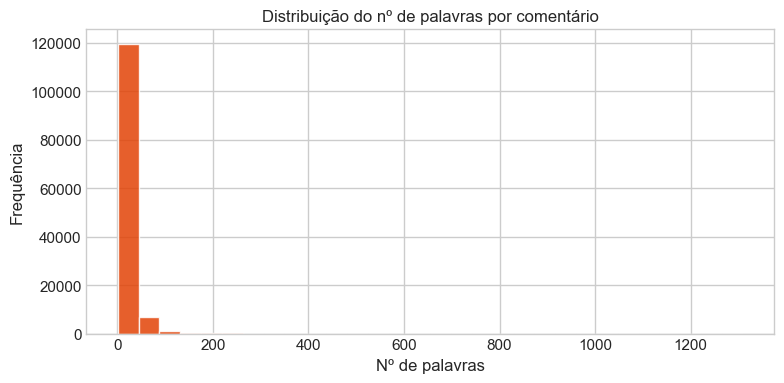

In [13]:
# ── 6.4 Métricas de texto ────────────────────────────────────────────────────
df['qtd_chars']    = df['comentario_limpo'].str.len()
df['qtd_palavras'] = df['comentario_limpo'].str.split().str.len().fillna(0).astype(int)

# ── 6.5 Remover stopwords — coluna separada ───────────────────────────────────
# IMPORTANTE: Modelos transformer (BERTimbau, etc.) devem consumir `comentario_limpo`
# (COM stopwords). A coluna `comentario_sem_sw` é destinada APENAS a abordagens
# bag-of-words (TF-IDF, LDA, CountVectorizer). Transformers dependem do contexto
# gramatical completo para gerar embeddings de qualidade.
def remover_stopwords(texto: str) -> str:
    if not texto:
        return ''
    return ' '.join(w for w in texto.split() if w not in STOPWORDS_PT)

df['comentario_sem_sw'] = df['comentario_limpo'].apply(remover_stopwords)

# Contagem de palavras APÓS remover stopwords — usada no filtro de tópicos
# filtro usa texto pós-stopwords, que reflete o que será entregue ao modelo
df['qtd_palavras_sem_sw'] = df['comentario_sem_sw'].str.split().str.len().fillna(0).astype(int)

comentarios_validos = df[df['tem_comentario']]
print(f'Média de palavras (com sw)    : {comentarios_validos["qtd_palavras"].mean():.1f}')
print(f'Média de palavras (sem sw)    : {comentarios_validos["qtd_palavras_sem_sw"].mean():.1f}')
print(f'Mediana (com sw)              : {comentarios_validos["qtd_palavras"].median():.0f}')

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(comentarios_validos['qtd_palavras'], bins=30, color='#E24307', edgecolor='white', alpha=0.85)
ax.set_title('Distribuição do nº de palavras por comentário')
ax.set_xlabel('Nº de palavras')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

In [14]:
# ── 6.6 Criar tipo_cliente (schema CLAUDE.md) ────────────────────────────────
TIPO_MAP = {'promotor': 'Promotor', 'neutro': 'Neutro', 'detrator': 'Detrator'}
df['tipo_cliente'] = df['classificacao'].map(TIPO_MAP)

print('tipo_cliente criado:', df['tipo_cliente'].value_counts().to_dict())

tipo_cliente criado: {'Promotor': 195872, 'Neutro': 27963, 'Detrator': 15308}


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Limitação conhecida — Coluna `classificacao`:</b><br>
A base de entrada fornece apenas a <b>categoria</b> (promotor / neutro / detrator), não a nota numérica original (1–10).<br>
O sistema upstream já aplica a classificação NPS:<br>
• <b>Promotor:</b> notas 9–10<br>
• <b>Neutro:</b> notas 7–8<br>
• <b>Detrator:</b> notas 1–6<br><br>
<b>Impacto:</b> Não é possível realizar análises granulares dentro de cada faixa (ex: separar nota 9 de 10, ou nota 1 de 6). Para o cálculo de NPS e para o pipeline NLP isso não gera nenhuma limitação funcional.
</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 7. Merge das Bases</div>

In [15]:
lojas_aval  = set(df['centro_nv2'].unique())
lojas_trans = set(df_t['centro_nv2'].unique())
print(f'Lojas em avaliações : {len(lojas_aval)}')
print(f'Lojas em transações : {len(lojas_trans)}')
print(f'Lojas em comum      : {len(lojas_aval & lojas_trans)}')
print(f'Só em transações    : {lojas_trans - lojas_aval}')
lojas_sem_transacao = lojas_aval - lojas_trans
print(f'Só em avaliações (sem dados de transação em NENHUM mês): {lojas_sem_transacao if lojas_sem_transacao else "Nenhuma — OK"}')

periodos_aval  = set(df['mes_ano_dt'].dropna().unique())
periodos_trans = set(df_t['mes_ano_dt'].dropna().unique())
sem_cobertura  = periodos_aval - periodos_trans
print(f'\nPeríodos em avaliações : {len(periodos_aval)}')
print(f'Períodos sem transação  : {sem_cobertura}  ← registros terão transacoes=NaN')

df_merge = df.merge(
    df_t[['centro_nv2','mes_ano_dt','transacoes','regiao','municipio','uf']],
    on=['centro_nv2','mes_ano_dt'],
    how='left'
)
cobertura = df_merge['transacoes'].notna().mean() * 100
print(f'\nMerge concluído: {df_merge.shape}')
print(f'Cobertura de transações: {cobertura:.1f}%')

Lojas em avaliações : 227
Lojas em transações : 229
Lojas em comum      : 227
Só em transações    : {'L5060-RIVIERA (1300)', 'L5293-DIADEMA'}
Só em avaliações (sem dados de transação em NENHUM mês): Nenhuma — OK

Períodos em avaliações : 17
Períodos sem transação  : {Period('2026-05', 'M')}  ← registros terão transacoes=NaN

Merge concluído: (239143, 29)
Cobertura de transações: 96.3%


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Decisão aplicada — Cobertura de transações:</b><br>
O período <code>2026-05</code> (último mês da base) não possui dados de transações na planilha de transações. Todos os registros desse período terão <code>transacoes = NaN</code> após o merge.<br><br>
<b>Estratégia:</b> os registros <b>não são removidos</b> — o NPS é válido independentemente do volume de transações. A coluna <code>transacoes</code> será usada apenas como informação complementar no dashboard. Análises que dependam de <code>transacoes</code> (ex: taxa de resposta) excluirão automaticamente os registros com NaN via <code>dropna()</code> ou <code>notna()</code>.
</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 8. Feature Engineering</div>

In [16]:
# ── 8.1 Score NPS por linha ──────────────────────────────────────────────────
NPS_SCORE_MAP = {'promotor': 100, 'neutro': 0, 'detrator': -100}
df_merge['nps_score']    = df_merge['classificacao'].map(NPS_SCORE_MAP)
df_merge['n_promotores'] = np.where(df_merge['classificacao']=='promotor', df_merge['qtd_clientes'], 0)
df_merge['n_neutros']    = np.where(df_merge['classificacao']=='neutro',   df_merge['qtd_clientes'], 0)
df_merge['n_detratores'] = np.where(df_merge['classificacao']=='detrator', df_merge['qtd_clientes'], 0)
print('[OK] Features NPS criadas')

[OK] Features NPS criadas


In [17]:
# ── 8.2 NPS consolidado por loja × mês ───────────────────────────────────────
nps_loja_mes = (
    df_merge
    .groupby(['centro_nv2','mes_ano_dt','flag','regiao','municipio','uf'])
    .agg(
        total_respostas = ('qtd_clientes',   'sum'),
        n_promotores    = ('n_promotores',   'sum'),
        n_neutros       = ('n_neutros',      'sum'),
        n_detratores    = ('n_detratores',   'sum'),
        transacoes      = ('transacoes',     'first'),
    )
    .reset_index()
)
nps_loja_mes['pct_promotores'] = nps_loja_mes['n_promotores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['pct_detratores'] = nps_loja_mes['n_detratores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['nps']            = nps_loja_mes['pct_promotores'] - nps_loja_mes['pct_detratores']
nps_loja_mes['taxa_resposta_pct'] = (nps_loja_mes['total_respostas'] / nps_loja_mes['transacoes'] * 100).round(2)

print(f'Tabela NPS por loja×mês: {nps_loja_mes.shape}')
display(nps_loja_mes.head(3))

Tabela NPS por loja×mês: (3621, 15)


,centro_nv2,mes_ano_dt,flag,regiao,municipio,uf,total_respostas,n_promotores,n_neutros,n_detratores,transacoes,pct_promotores,pct_detratores,nps,taxa_resposta_pct
0,L5001-RIBEIRAO PRETO (0217),2025-01,REGULAR,Interior,RIBEIRÃO PRETO,SP,243,212,22,9,9738.00,87.24,3.70,83.54,2.50
1,L5001-RIBEIRAO PRETO (0217),2025-02,REGULAR,Interior,RIBEIRÃO PRETO,SP,126,109,11,6,9074.00,86.51,4.76,81.75,1.39
2,L5001-RIBEIRAO PRETO (0217),2025-03,REGULAR,Interior,RIBEIRÃO PRETO,SP,148,135,9,4,9801.00,91.22,2.70,88.51,1.51


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 9. Detecção de Outliers</div>

Outliers IQR    : 37,032 (15.5%)
Outliers Z-Score: 5,180 (2.2%)


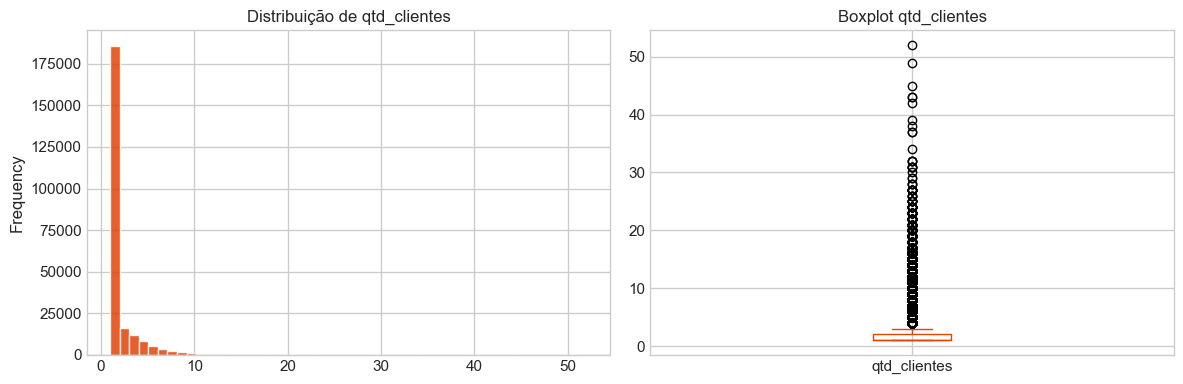

count   239143.00
mean         2.02
std          2.13
min          1.00
25%          1.00
50%          1.00
75%          2.00
95%          6.00
99%         11.00
max         52.00
Name: qtd_clientes, dtype: float64


In [18]:
# ── 9.1 IQR ──────────────────────────────────────────────────────────────────
Q1 = df_merge['qtd_clientes'].quantile(0.25)
Q3 = df_merge['qtd_clientes'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = max(0, Q1 - 1.5 * IQR)

df_merge['outlier_iqr'] = (
    (df_merge['qtd_clientes'] < lim_inf) |
    (df_merge['qtd_clientes'] > lim_sup)
)

# ── 9.2 Z-Score ───────────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df_merge['qtd_clientes'].fillna(0)))
df_merge['outlier_zscore'] = z_scores > 3

# Colunas de outliers
print(f'Outliers IQR    : {df_merge["outlier_iqr"].sum():,} ({df_merge["outlier_iqr"].mean()*100:.1f}%)')
print(f'Outliers Z-Score: {df_merge["outlier_zscore"].sum():,} ({df_merge["outlier_zscore"].mean()*100:.1f}%)')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df_merge['qtd_clientes'].plot.hist(bins=50, ax=axes[0], color='#E24307', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de qtd_clientes')
df_merge['qtd_clientes'].plot.box(ax=axes[1], color='#E24307')
axes[1].set_title('Boxplot qtd_clientes')
plt.tight_layout(); plt.show()
print(df_merge['qtd_clientes'].describe(percentiles=[.25,.5,.75,.95,.99]))

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 10. Exportação das Bases Tratadas</div>

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Arquivos gerados (contratos do CLAUDE.md):</b><br>
• <code>df_avaliacoes_tratado.parquet</code> — base principal limpa (schema completo)<br>
• <code>df_nps_loja_mes.parquet</code> — NPS agregado por loja × mês<br>
• <code>df_comentarios_nlp.parquet</code> — entrada para todos os módulos NLP<br>
• <code>base_final.csv</code> — backup completo em CSV
</div>

In [19]:
# ── 10.1 df_avaliacoes_tratado — schema completo conforme CLAUDE.md ──────────
colunas_avaliacao = [
    'avaliacao_id', 'mes_ano_dt', 'classificacao', 'tipo_cliente', 'data_avaliacao',
    'centro_nv2', 'loja_id', 'qtd_clientes', 'comentario', 'comentario_original', 'flag',
    'ano', 'mes', 'trimestre', 'semana_ano', 'dia_semana', 'dia_semana_nome',
    'comentario_raw', 'tem_comentario', 'comentario_limpo',
    'comentario_sem_sw', 'qtd_chars', 'qtd_palavras', 'qtd_palavras_sem_sw',
    'nps_score', 'n_promotores', 'n_neutros', 'n_detratores',
    'outlier_iqr', 'outlier_zscore',
    'transacoes', 'regiao', 'municipio', 'uf',
]
# Apenas colunas que existem
colunas_avaliacao = [c for c in colunas_avaliacao if c in df_merge.columns]
df_avaliacoes_tratado = df_merge[colunas_avaliacao].copy()

# Converter Period para string antes de exportar parquet
df_export = df_avaliacoes_tratado.copy()
df_export['mes_ano_dt'] = df_export['mes_ano_dt'].astype(str)

df_export.to_parquet('data/df_avaliacoes_tratado.parquet', index=False)
print(f'[OK] df_avaliacoes_tratado.parquet : {df_export.shape}')

# ── 10.2 df_nps_loja_mes ─────────────────────────────────────────────────────
nps_export = nps_loja_mes.copy()
nps_export['mes_ano_dt'] = nps_export['mes_ano_dt'].astype(str)
nps_export.to_parquet('data/df_nps_loja_mes.parquet', index=False)
print(f'[OK] df_nps_loja_mes.parquet       : {nps_export.shape}')

# ── 10.3 df_comentarios_nlp — entrada para todos os módulos NLP ──────────────
# Schema: centro_nv2, data_avaliacao, flag, tipo_cliente,
#         comentario, comentario_limpo, n_palavras, n_chars
df_comentarios_nlp = df_merge[df_merge['tem_comentario']].copy()
df_comentarios_nlp = df_comentarios_nlp[[
    'centro_nv2', 'data_avaliacao', 'flag', 'tipo_cliente',
    'comentario', 'comentario_limpo', 'qtd_palavras', 'qtd_chars'
]].rename(columns={'qtd_palavras': 'n_palavras', 'qtd_chars': 'n_chars'})

# ── 10.3a Remover duplicatas verdadeiras (texto+loja+dia) ─────────────────────
# São registros que representam o mesmo evento de coleta (ex: qtd_clientes agrupado
# que gerou uma linha duplicada). Manter apenas o primeiro registro.
antes_dup = len(df_comentarios_nlp)
df_comentarios_nlp = df_comentarios_nlp.drop_duplicates(
    subset=['comentario_limpo', 'centro_nv2', 'data_avaliacao'], keep='first'
).copy()
print(f'Duplicatas verdadeiras removidas: {antes_dup - len(df_comentarios_nlp):,}')

# ── 10.3b Filtro mínimo de qualidade textual (n_chars >= 10 E n_palavras >= 2) ─
# Comentários com <= 9 chars (ex: 'ok', 'nota', 'tudo') não carregam informação
# semântica útil para nenhuma tarefa NLP — nem sentimento, nem clusterização.
# Palavras isoladas (ex: 'excelente', 'atendimento') também não têm contexto
# suficiente para embedding ou classificação.
antes_curtos = len(df_comentarios_nlp)
df_comentarios_nlp = df_comentarios_nlp[
    (df_comentarios_nlp['n_chars'] >= 10) &
    (df_comentarios_nlp['n_palavras'] >= 2)
].copy()
print(f'Comentários curtos/1 palavra removidos: {antes_curtos - len(df_comentarios_nlp):,}')

# Remover textos com palavras coladas/lixo de encoding (tokens > 40 chars)
# Ex: 'fazeroprogramadepontosomesinteiroenaosode1a10domes', strings base64
def max_token_len(text):
    words = str(text).split()
    return max((len(w) for w in words), default=0)

mask_lixo = df_comentarios_nlp['comentario_limpo'].apply(max_token_len) > 40
print(f'Comentários com tokens lixo (>40 chars) removidos: {mask_lixo.sum():,}')
df_comentarios_nlp = df_comentarios_nlp[~mask_lixo].copy()

# ── 10.3c Flag comentario_longo (> 350 palavras) ─────────────────────────────
# Modelos transformer têm limite de ~512 tokens (~350 palavras em PT-BR).
# Textos acima disso precisarão de truncagem ou chunking antes de entrar no modelo.
df_comentarios_nlp['comentario_longo'] = df_comentarios_nlp['n_palavras'] > 350
print(f'Comentários longos (>350 palavras): {df_comentarios_nlp["comentario_longo"].sum():,}')

# ── 10.3d Frequência do texto e flag de texto genérico ───────────────────────
# Textos muito repetidos (frases genéricas como 'mais promoções', 'tudo ótimo')
# aparecem em centenas de lojas distintas — são padrões comportamentais reais,
# NÃO devem ser removidos. Mas alimentar 788 cópias idênticas ao modelo distorce
# os clusters. A solução correta é registrar a frequência e deixar a decisão de
# ponderação para a etapa de modelagem.
#
# Uso recomendado na modelagem:
#   - Deduplica pelo texto antes de embeddar
#   - Usa freq_texto como peso no k-means/HDBSCAN
#   - Analisa df_genericos separadamente para insights de frequência
freq_map = df_comentarios_nlp['comentario_limpo'].value_counts()
df_comentarios_nlp['freq_texto'] = df_comentarios_nlp['comentario_limpo'].map(freq_map)
# Threshold: texto que aparece em >= 50 ocorrências é considerado genérico
df_comentarios_nlp['texto_generico'] = df_comentarios_nlp['freq_texto'] >= 50
n_genericos  = df_comentarios_nlp['texto_generico'].sum()
n_uniq_gener = df_comentarios_nlp[df_comentarios_nlp['texto_generico']]['comentario_limpo'].nunique()
print(f'Textos genéricos (freq >= 50): {n_genericos:,} registros | {n_uniq_gener} textos únicos')

# ── 10.3e Documentar viés nos labels de sentimento ───────────────────────────
# ~5% dos Promotores contêm palavras de tom negativo no texto.
# Isso ocorre porque o cliente avalia a experiência geral com nota alta (9-10)
# mas comenta um problema pontual. Se tipo_cliente for usado como ground truth
# para treinar um modelo de sentimento supervisionado, a taxa de ruído nos labels
# é ~5% — aceitável, mas deve ser considerada na avaliação de métricas do modelo.
negativos_pattern = r'ruim|péssimo|pessimo|horrível|horroroso|caro demais|sujo|problema|falta'
promo = df_comentarios_nlp[df_comentarios_nlp['tipo_cliente'] == 'Promotor']
vies = promo['comentario_limpo'].str.contains(negativos_pattern, case=False, na=False).mean()
print(f'Viés de label (Promotores com texto negativo): {vies*100:.1f}%')

nlp_export = df_comentarios_nlp.copy()
nlp_export.to_parquet('data/df_comentarios_nlp.parquet', index=True)
print(f'[OK] df_comentarios_nlp.parquet    : {nlp_export.shape}')

# ── 10.4 base_final.csv — backup completo ────────────────────────────────────
df_merge_backup = df_merge.copy()
df_merge_backup['mes_ano_dt'] = df_merge_backup['mes_ano_dt'].astype(str)
df_merge_backup.to_csv('data/base_final.csv', index=False, sep=';', encoding='utf-8-sig')
print(f'[OK] base_final.csv               : {df_merge_backup.shape}')

[OK] df_avaliacoes_tratado.parquet : (239143, 34)
[OK] df_nps_loja_mes.parquet       : (3621, 15)
Duplicatas verdadeiras removidas: 37
Comentários curtos/1 palavra removidos: 3,167
Comentários com tokens lixo (>40 chars) removidos: 4
Comentários longos (>350 palavras): 16
Textos genéricos (freq >= 50): 6,984 registros | 50 textos únicos
Viés de label (Promotores com texto negativo): 5.1%
[OK] df_comentarios_nlp.parquet    : (124701, 11)
[OK] base_final.csv               : (239143, 35)


In [20]:
# ── 10.5 Divisão NLP: sentimento vs. categorização ───────────────────────────
# Sentimento: usa TODOS os comentários válidos (curtos tb têm valência)
# Categorização (LDA/TF-IDF): exige ≥5 palavras sem stopwords
# Clusterização (embeddings/transformers): exige ≥3 palavras COM stopwords
#   → frases curtas como 'preço alto' ainda carregam informação semântica
# o texto real entregue ao modelo de categorização.
df_nlp      = df_merge[df_merge['tem_comentario']].copy()
df_topicos  = df_nlp[df_nlp['qtd_palavras_sem_sw'] >= 5].reset_index(drop=True)
df_cluster  = df_nlp[df_nlp['qtd_palavras'] >= 3].reset_index(drop=True)

print(f'df_sentimento (todos comentários válidos)       : {len(df_nlp):,}')
print(f'df_topicos    (≥5 palavras sem stopwords, LDA) : {len(df_topicos):,}')
print(f'df_cluster    (≥3 palavras com sw, embeddings) : {len(df_cluster):,}')
print(f'Excluídos da categorização LDA                 : {len(df_nlp)-len(df_topicos):,} comentários curtos')
print(f'Excluídos da clusterização                     : {len(df_nlp)-len(df_cluster):,} comentários curtos')

df_sentimento (todos comentários válidos)       : 127,909
df_topicos    (≥5 palavras sem stopwords, LDA) : 76,360
df_cluster    (≥3 palavras com sw, embeddings) : 116,605
Excluídos da categorização LDA                 : 51,549 comentários curtos
Excluídos da clusterização                     : 11,304 comentários curtos


In [21]:
# ── Relatório final ───────────────────────────────────────────────────────────
print('=' * 60)
print('         RELATÓRIO DE PRÉ-PROCESSAMENTO')
print('=' * 60)
print(f'Registros originais            : {len(df_aval):>10,}')
print(f'Após limpeza (flag + qtd)      : {len(df_merge):>10,}')
print(f'Lojas únicas                   : {df_merge["centro_nv2"].nunique():>10,}')
print(f'Períodos cobertos              : {df_merge["mes_ano_dt"].nunique():>10,}')
print(f'Com comentário real            : {df_merge["tem_comentario"].sum():>10,}')
print(f'NLP — após dedup + filtro chars : {len(nlp_export):>10,}')
print(f'NLP — textos genéricos (freq≥50): {nlp_export["texto_generico"].sum():>10,}')
print(f'NLP — comentários longos (>350w): {nlp_export["comentario_longo"].sum():>10,}')
print(f'Outliers IQR (qtd_clientes)   : {df_merge["outlier_iqr"].sum():>10,}')
print(f'Outliers Z-Score              : {df_merge["outlier_zscore"].sum():>10,}')
print(f'Cobertura de transações        : {df_merge["transacoes"].notna().mean()*100:>9.1f}%')
print()
print('Arquivos exportados:')
print('  data/df_avaliacoes_tratado.parquet')
print('  data/df_nps_loja_mes.parquet')
print('  data/df_comentarios_nlp.parquet')
print('  data/base_final.csv')
print('=' * 60)

         RELATÓRIO DE PRÉ-PROCESSAMENTO
Registros originais            :    240,352
Após limpeza (flag + qtd)      :    239,143
Lojas únicas                   :        227
Períodos cobertos              :         17
Com comentário real            :    127,909
NLP — após dedup + filtro chars :    124,701
NLP — textos genéricos (freq≥50):      6,984
NLP — comentários longos (>350w):         16
Outliers IQR (qtd_clientes)   :     37,032
Outliers Z-Score              :      5,180
Cobertura de transações        :      96.3%

Arquivos exportados:
  data/df_avaliacoes_tratado.parquet
  data/df_nps_loja_mes.parquet
  data/df_comentarios_nlp.parquet
  data/base_final.csv


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 2 — EDA: ANÁLISE EXPLORATÓRIA DE DADOS</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2></div>

In [22]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import warnings
warnings.filterwarnings('ignore')

import os, re, unicodedata
try:
    import emoji
except ImportError:
    class _EmojiFallback:
        @staticmethod
        def replace_emoji(text, replace=''):
            return str(text)

        @staticmethod
        def emoji_count(text):
            return 0

    emoji = _EmojiFallback()
    print('[AVISO] Pacote emoji não encontrado; seguindo sem tratamento específico de emojis.')
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

FALLBACK_STOPWORDS_PT = {
    'a', 'à', 'ao', 'aos', 'as', 'às', 'o', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'da', 'das', 'do', 'dos', 'em', 'na', 'nas', 'no', 'nos', 'por',
    'para', 'com', 'sem', 'sobre', 'entre', 'até', 'após', 'antes', 'desde',
    'e', 'ou', 'mas', 'porém', 'porque', 'que', 'se', 'como', 'quando',
    'onde', 'qual', 'quais', 'quem', 'quanto', 'quantos', 'muito', 'muita',
    'muitos', 'muitas', 'pouco', 'pouca', 'poucos', 'poucas', 'mais', 'menos',
    'já', 'também', 'só', 'não', 'sim', 'foi', 'ser', 'ter', 'tem', 'têm',
    'era', 'são', 'está', 'estão', 'estava', 'estavam', 'me', 'te', 'se',
    'lhe', 'nos', 'vos', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'você', 'vocês',
    'eu', 'tu', 'ele', 'ela', 'eles', 'elas', 'nós', 'isso', 'isto', 'aquilo',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela'
}


def get_stopwords_pt():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        try:
            nltk.download('stopwords', quiet=True)
        except Exception:
            pass

    try:
        return set(stopwords.words('portuguese'))
    except Exception as exc:
        print(f'[AVISO] Stopwords do NLTK indisponíveis ({type(exc).__name__}). Usando lista local reduzida.')
        return FALLBACK_STOPWORDS_PT
from nltk.util import ngrams

# TF-IDF para quasi-duplicatas
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Seed global
import random
random.seed(42)
np.random.seed(42)

# Paleta Swift
PALETTE = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
ORDER   = ['promotor', 'neutro', 'detrator']
CORES   = [PALETTE[c] for c in ORDER]
STOP_PT = get_stopwords_pt()

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

# Versões
import sklearn
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | sklearn: {sklearn.__version__}')
print('[OK] Ambiente configurado')

pandas: 3.0.3 | numpy: 2.4.6 | sklearn: 1.6.1
[OK] Ambiente configurado


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento dos Dados</h2></div>

In [23]:
if not os.path.exists('data/df_avaliacoes_tratado.parquet'):
    raise FileNotFoundError(
        "df_avaliacoes_tratado.parquet não encontrada.\n"
        "Execute primeiro: pre_processamento_swift.ipynb"
    )

df = pd.read_parquet('data/df_avaliacoes_tratado.parquet')

# Restaurar Period após leitura de parquet
df['mes_ano_dt'] = pd.to_datetime(df['mes_ano_dt'], errors='coerce').dt.to_period('M')
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')
df['ano_mes'] = df['mes_ano_dt']

# Subset com comentário válido
df_com = df[df['tem_comentario'] == True].copy()

print(f'Total de registros  : {len(df):,}')
print(f'Com comentário real : {len(df_com):,}  ({100*len(df_com)/len(df):.1f}%)')
print(f'Sem comentário      : {(~df["tem_comentario"]).sum():,}')
print(f'Lojas únicas        : {df["centro_nv2"].nunique()}')
print(f'Colunas disponíveis : {list(df.columns)}')

Total de registros  : 239,143
Com comentário real : 127,909  (53.5%)
Sem comentário      : 111,234
Lojas únicas        : 227
Colunas disponíveis : ['avaliacao_id', 'mes_ano_dt', 'classificacao', 'tipo_cliente', 'data_avaliacao', 'centro_nv2', 'loja_id', 'qtd_clientes', 'comentario', 'comentario_original', 'flag', 'ano', 'mes', 'trimestre', 'semana_ano', 'dia_semana', 'dia_semana_nome', 'comentario_raw', 'tem_comentario', 'comentario_limpo', 'comentario_sem_sw', 'qtd_chars', 'qtd_palavras', 'qtd_palavras_sem_sw', 'nps_score', 'n_promotores', 'n_neutros', 'n_detratores', 'outlier_iqr', 'outlier_zscore', 'transacoes', 'regiao', 'municipio', 'uf', 'ano_mes']


In [24]:
# ── KPIs principais — visão rápida para o cliente ─────────────────────────
from IPython.display import display, HTML

n_lojas     = df['centro_nv2'].nunique()
n_meses     = df['mes_ano_dt'].nunique()
n_aval      = df['qtd_clientes'].sum()
n_coment    = df['tem_comentario'].sum()
pct_coment  = n_coment / len(df) * 100
n_flags     = df['flag'].nunique()

cards_html = f"""
<div style="display:flex;gap:16px;flex-wrap:wrap;margin:16px 0;font-family:'Segoe UI',Arial,sans-serif;">
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Lojas analisadas</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_lojas}</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Período coberto</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_meses} meses</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Total de avaliações</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_aval:,.0f}</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Com comentário</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_coment:,}</div>
    <div style="font-size:12px;color:#5c1d0c;">{pct_coment:.1f}% do total</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Perfis de gestão</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_flags}</div>
    <div style="font-size:12px;color:#5c1d0c;">REGULAR · TOCADORA</div>
  </div>
</div>
"""
display(HTML(cards_html))

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.1 — Distribuição do NPS e dos Comentários</h2></div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base completa?
- Essa proporção se mantém estável entre lojas ou existe grande variação?
- Das avaliações com comentário, como se distribuem por faixa de nota?

> **Nota sobre faixa de nota:** O dataset da Swift não armazena a nota numérica individual (1–10) por avaliação — armazena diretamente a classificação NPS (\ / \ / \). Por definição NPS: promotores = notas 9–10, neutros = notas 7–8, detratores = notas 1–6. Portanto, a distribuição por faixa de nota é respondida pela proporção entre essas três classes, que é exatamente o que a análise abaixo apresenta.

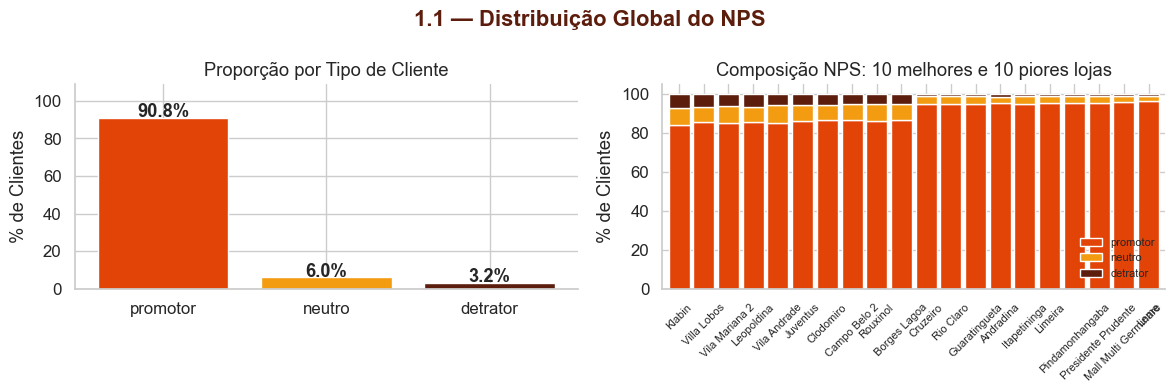

NPS Geral: 87.6

Dado que 90.8% são promotores, 6.0% neutros e 3.2% detratores,
o dataset está desbalanceado.
Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.


In [25]:
# Distribuição global ponderada por qtd_clientes
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum().reindex(ORDER).fillna(0)
)
pct = contagem / contagem.sum() * 100
nps_geral = pct['promotor'] - pct['detrator']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.1 — Distribuição Global do NPS', fontweight='bold', color='#5c1d0c')

# Barras por tipo
bars = axes[0].bar(ORDER, pct, color=CORES, edgecolor='white')
for bar, v in zip(bars, pct):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Proporção por Tipo de Cliente')
axes[0].set_ylabel('% de Clientes')
axes[0].set_ylim(0, pct.max()*1.2)
axes[0].axhline(0, color='#5c1d0c', lw=0.5)

# Composição por loja (stacked)
nps_loja = df.groupby(['centro_nv2','classificacao'])['qtd_clientes'].sum().unstack(fill_value=0)
nps_loja = nps_loja.div(nps_loja.sum(axis=1), axis=0) * 100
nps_loja['nps'] = nps_loja.get('promotor',0) - nps_loja.get('detrator',0)
nps_loja_sorted = nps_loja.sort_values('nps')

# Plot 10 melhores e 10 piores — labels abreviados para legibilidade
sample_lojas = pd.concat([nps_loja_sorted.head(10), nps_loja_sorted.tail(10)])
# Extrair apenas o nome da loja (sem código L5XXX e sem número entre parênteses)
import re as _re
def abreviar_loja(nome):
    nome = _re.sub(r'^L\d+-', '', str(nome))   # remove prefixo L5001-
    nome = _re.sub(r'\s*\(\d+\)', '', nome)    # remove sufixo (0217)
    return nome.title()[:22]                    # capitaliza e limita a 22 chars
labels_abrev = [abreviar_loja(l) for l in sample_lojas.index]
sample_lojas_plot = sample_lojas[ORDER].copy()
sample_lojas_plot.index = labels_abrev
sample_lojas_plot.plot(kind='bar', stacked=True, ax=axes[1],
    color=CORES, edgecolor='white', width=0.85)
axes[1].set_title('Composição NPS: 10 melhores e 10 piores lojas')
axes[1].set_xlabel('')
axes[1].set_ylabel('% de Clientes')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'NPS Geral: {nps_geral:.1f}')
print(f"\nDado que {pct['promotor']:.1f}% são promotores, {pct['neutro']:.1f}% neutros e {pct['detrator']:.1f}% detratores,")
print("o dataset está desbalanceado.")
print("Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.")

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Promotores dominam a base (~90%). Dataset altamente desbalanceado.<br>
<b>Decisão técnica:</b> Aplicar <code>class_weight='balanced'</code> no treino; monitorar F1-Macro, não acurácia global.<br>
<b>Para o negócio:</b> Um NPS de 87.6 é acima da média do varejo brasileiro (tipicamente 60–75). Isso significa que a Swift tem uma base de clientes altamente fiel — o foco deve ser entender o que faz as lojas piores <b>não</b> converterem essa fidelidade, não apenas celebrar a média alta.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.2 — Cobertura de Comentários por Loja</h2></div>

**Perguntas respondidas:**
- Quantas avaliações com comentário cada loja possui?
- Quantas lojas têm menos de 50 comentários? E menos de 30?
- Qual é a loja com mais e com menos comentários?

Total de lojas               : 227
Lojas com < 30 comentários   : 0
Lojas com < 50 comentários   : 0
Loja com MAIS comentários    : L5230-LARGO DO MACHADO (1,885)
Loja com MENOS comentários   : L5262-URBANOVA (155)
Cobertura média              : 51.8%


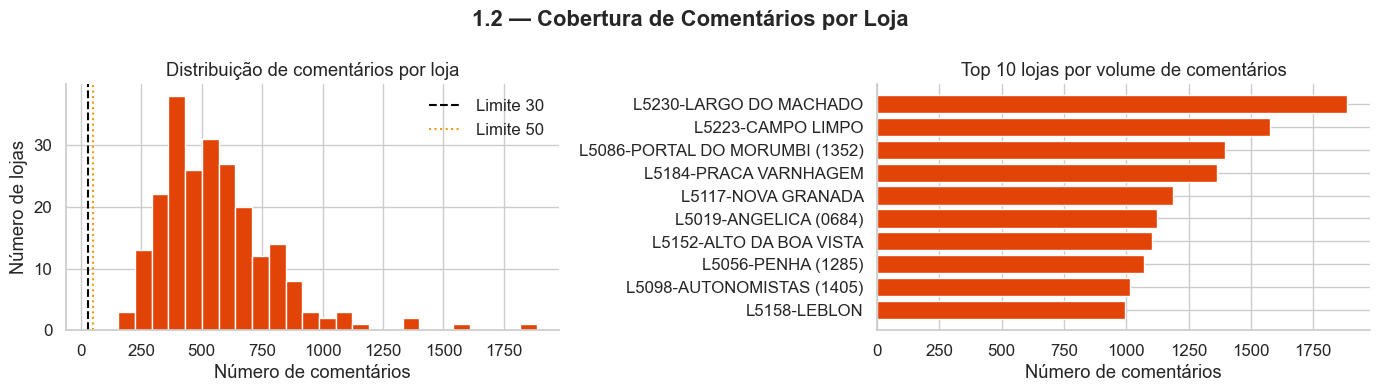

In [26]:
cobertura = (
    df.groupby('centro_nv2')
    .agg(
        total_avaliacoes = ('tem_comentario', 'size'),
        n_comentarios    = ('tem_comentario', 'sum')
    )
    .sort_values('n_comentarios', ascending=False)
    .reset_index()
)
cobertura['pct'] = cobertura['n_comentarios'] / cobertura['total_avaliacoes'] * 100

n_menos_30 = (cobertura['n_comentarios'] < 30).sum()
n_menos_50 = (cobertura['n_comentarios'] < 50).sum()
loja_max   = cobertura.iloc[0]
loja_min   = cobertura[cobertura['n_comentarios'] > 0].sort_values('n_comentarios').iloc[0]

print(f'Total de lojas               : {len(cobertura)}')
print(f'Lojas com < 30 comentários   : {n_menos_30}')
print(f'Lojas com < 50 comentários   : {n_menos_50}')
print(f'Loja com MAIS comentários    : {loja_max["centro_nv2"]} ({loja_max["n_comentarios"]:,})')
print(f'Loja com MENOS comentários   : {loja_min["centro_nv2"]} ({loja_min["n_comentarios"]:,})')
print(f'Cobertura média              : {cobertura["pct"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('1.2 — Cobertura de Comentários por Loja', fontweight='bold')

axes[0].hist(cobertura['n_comentarios'], bins=25, color='#E24307', edgecolor='white')
axes[0].axvline(30, color='black', linestyle='--', label='Limite 30')
axes[0].axvline(50, color='#f39c12',  linestyle=':', label='Limite 50')
axes[0].set_xlabel('Número de comentários'); axes[0].set_ylabel('Número de lojas')
axes[0].set_title('Distribuição de comentários por loja'); axes[0].legend()

top10 = cobertura.head(10)
axes[1].barh(top10['centro_nv2'].str[:35], top10['n_comentarios'], color='#E24307', edgecolor='white')
axes[1].invert_yaxis(); axes[1].set_xlabel('Número de comentários')
axes[1].set_title('Top 10 lojas por volume de comentários')

plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Nenhuma loja ficou abaixo de 30 comentários.<br>
<b>Decisão:</b> Limiar fixado em <b>30 comentários</b> por loja para exibição no dashboard. Lojas abaixo recebem apenas NPS bruto com aviso de "amostra insuficiente".
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.3 — Características do Texto</h2></div>

**Perguntas respondidas:**
- Qual a distribuição de comprimento dos comentários em palavras?
- Qual o percentual de comentários com menos de 5 palavras?
- Qual o percentual com mais de 100 palavras?

Mínimo   : 1 palavra(s)
Média    : 15.9 palavras
Mediana  : 9 palavras
Máximo   : 1309 palavras
< 5 palavras   : 24.2%
> 100 palavras : 0.8%


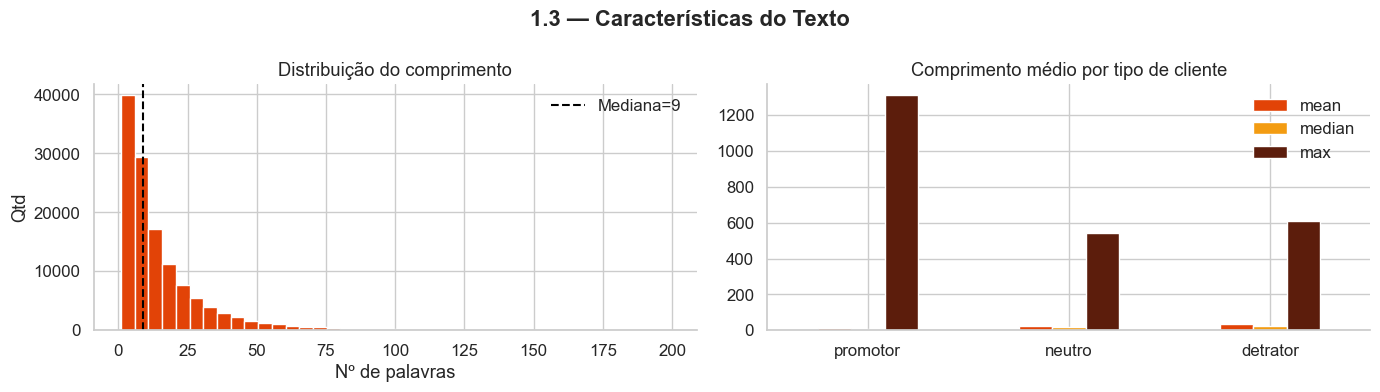


Dado que 24.2% dos comentários têm menos de 5 palavras e 0.8% têm mais de 100 palavras:
  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização.
  > 100 palavras: truncados em 256 tokens no fine-tuning (compatível com BERT-base).


In [27]:
df_com = df_com.copy()
# Usar qtd_palavras do pré-processamento se disponível, senão recalcular
if 'qtd_palavras' in df_com.columns:
    df_com['n_palavras'] = df_com['qtd_palavras']
else:
    df_com['n_palavras'] = df_com['comentario'].str.split().str.len()

stats = df_com['n_palavras'].describe(percentiles=[.25,.5,.75,.95])
pct_curtos = (df_com['n_palavras'] < 5).mean()  * 100
pct_longos = (df_com['n_palavras'] > 100).mean() * 100

print(f'Mínimo   : {int(df_com["n_palavras"].min())} palavra(s)')
print(f'Média    : {df_com["n_palavras"].mean():.1f} palavras')
print(f'Mediana  : {df_com["n_palavras"].median():.0f} palavras')
print(f'Máximo   : {int(df_com["n_palavras"].max())} palavras')
print(f'< 5 palavras   : {pct_curtos:.1f}%')
print(f'> 100 palavras : {pct_longos:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('1.3 — Características do Texto', fontweight='bold')

dados_hist = df_com.loc[df_com['n_palavras'] <= 200, 'n_palavras']
axes[0].hist(dados_hist, bins=40, color='#E24307', edgecolor='white')
axes[0].axvline(df_com['n_palavras'].median(), color='black', linestyle='--',
               label=f"Mediana={df_com['n_palavras'].median():.0f}")
axes[0].set_xlabel('Nº de palavras'); axes[0].set_ylabel('Qtd'); axes[0].legend()
axes[0].set_title('Distribuição do comprimento')

stats_tipo = df_com.groupby('classificacao')['n_palavras'].agg(['mean','median','max']).reindex(ORDER).round(1)
stats_tipo.plot(kind='bar', ax=axes[1], color=['#E24307','#f39c12','#5c1d0c'], edgecolor='white')
axes[1].set_title('Comprimento médio por tipo de cliente')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print(f"\nDado que {pct_curtos:.1f}% dos comentários têm menos de 5 palavras e {pct_longos:.1f}% têm mais de 100 palavras:")
print('  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização.')
print('  > 100 palavras: truncados em 256 tokens no fine-tuning (compatível com BERT-base).')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> ~24% dos comentários têm menos de 5 palavras.<br>
<b>Decisão:</b> Comentários com &lt;5 palavras são <b>incluídos</b> no treino de sentimento (ex: "ótimo" é sinal forte), mas <b>excluídos</b> do treino de categorização de tópicos. Comentários com &gt;100 palavras serão truncados em 256 tokens.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.4 — Qualidade e Ruído dos Dados</h2></div>

**Perguntas respondidas:**
- % de duplicatas ou quasi-duplicatas (similaridade > 90%)?
- Comentários em outros idiomas?
- Frequência de emojis?
- Spam ou sequências sem sentido?

In [28]:
n_total = len(df_com)

# 1. Duplicatas exatas
n_dup   = df_com['comentario'].duplicated().sum()
pct_dup = n_dup / n_total * 100

# 2. Quasi-duplicatas via TF-IDF + cosine
# ATENÇÃO: calculado em amostra de 3.000 registros (~2.3% da base) por limitação
# de memória (matriz n×n seria 127k×127k). O valor é uma estimativa — o intervalo
# real pode variar ±3–5 pontos percentuais.
amostra_textos = (
    df_com['comentario'].dropna()
    .sample(n=min(3000, n_total), random_state=42)
)
tfidf = TfidfVectorizer(max_features=500, min_df=2)
mat   = tfidf.fit_transform(amostra_textos)
sim   = cosine_similarity(mat)
import numpy as np
np.fill_diagonal(sim, 0)
n_quasi   = (sim > 0.90).any(axis=1).sum()
pct_quasi = n_quasi / len(amostra_textos) * 100

# 3. Emojis
pct_emoji = df_com['comentario'].apply(lambda x: emoji.emoji_count(str(x)) > 0).mean() * 100

# 4. Spam — definição idêntica ao pré-processamento
def is_spam(text: str) -> bool:
    text = str(text).strip()
    if len(text) == 0:
        return True
    text_sem_emoji = emoji.replace_emoji(text, replace='').strip()
    if len(text_sem_emoji) == 0:
        return True
    alpha = sum(c.isalpha() for c in text_sem_emoji)
    return (
        alpha / len(text_sem_emoji) < 0.40
        or bool(re.match(r'\A(.)\1{4,}\Z', text_sem_emoji))
    )

pct_spam = df_com['comentario'].apply(is_spam).mean() * 100

# 5. Idioma — detecção por langdetect se disponível, senão heurística melhorada
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42
    def detectar_idioma(texto):
        try:
            return detect(str(texto))
        except:
            return 'unknown'
    sample_idioma = df_com['comentario'].sample(n=min(1000, n_total), random_state=42)
    idiomas = sample_idioma.apply(detectar_idioma)
    pct_nao_pt = (idiomas != 'pt').mean() * 100
    metodo_idioma = 'langdetect'
except ImportError:
    # Heurística melhorada: exigir PELO MENOS 2 stopwords PT
    PT_WORDS = {
        'que','de','da','do','os','as','em','um','uma','para','com','por',
        'mas','não','na','no','se','ao','é','ou','eu','me','te','nos',
        'seu','sua','eles','elas','isso','este','esta','aqui','mais','bem',
        'muito','tudo','nada','loja','produto','atendimento','preço','bom','ótimo',
        'ruim','péssimo','excelente','sempre','nunca','hoje','compra','cliente',
    }
    def conta_pt(texto):
        palavras = set(str(texto).lower().split())
        return len(palavras & PT_WORDS)
    pct_nao_pt = (df_com['comentario'].apply(conta_pt) < 2).mean() * 100
    metodo_idioma = 'heurística (≥2 stopwords PT)'

metricas = pd.DataFrame({
    'Métrica': ['Duplicatas exatas','Quasi-duplicatas (TF-IDF)','Com emoji','Spam','Possivelmente não-PT'],
    'Valor (%)': [pct_dup, pct_quasi, pct_emoji, pct_spam, pct_nao_pt]
})
display(metricas.style.format({'Valor (%)': '{:.1f}'}))
print(f'(Detecção de idioma: {metodo_idioma})')

,Métrica,Valor (%)
0,Duplicatas exatas,10.7
1,Quasi-duplicatas (TF-IDF),16.5
2,Com emoji,0.4
3,Spam,0.0
4,Possivelmente não-PT,7.8


(Detecção de idioma: langdetect)


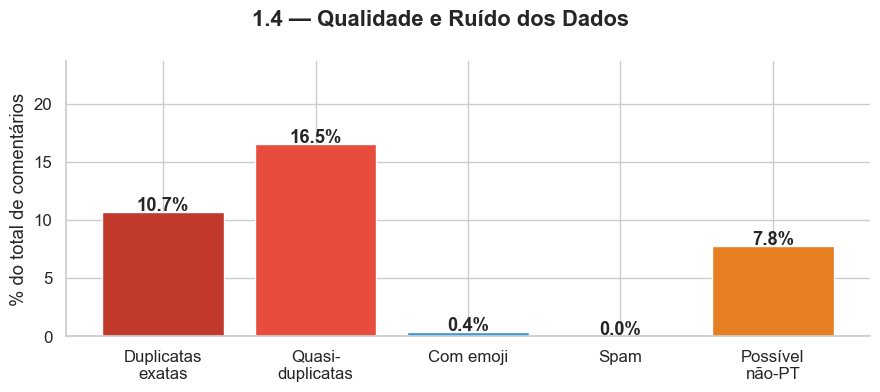

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('1.4 — Qualidade e Ruído dos Dados', fontweight='bold')
categorias = ['Duplicatas\nexatas','Quasi-\nduplicatas','Com emoji','Spam','Possível\nnão-PT']
valores    = [pct_dup, pct_quasi, pct_emoji, pct_spam, pct_nao_pt]
cores      = ['#c0392b','#e74c3c','#3498db','#9b59b6','#e67e22']
bars = ax.bar(categorias, valores, color=cores, edgecolor='white')
for bar, v in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('% do total de comentários')
ax.set_ylim(0, max(valores)*1.4+0.5)
plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável — Plano de limpeza decidido:</b><br>
1. Remover duplicatas exatas <b>antes</b> da divisão treino/teste.<br>
2. Quasi-duplicatas (TF-IDF cosine &gt;90%): manter apenas o mais recente.<br>
3. Spam e sequências sem sentido: excluir automaticamente (já feito no pré-processamento).<br>
4. Emojis: remover antes da tokenização para modelos TF-IDF; manter para BERT (tokenizador trata).<br>
5. Comentários não-PT confirmados: excluir do treino.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.5 — Análise Temporal</h2></div>

**Perguntas respondidas:**
- Volume de avaliações varia ao longo do tempo?
- NPS médio é estável ou apresenta picos e quedas?
- Alguma loja tem comportamento temporal claramente atípico?

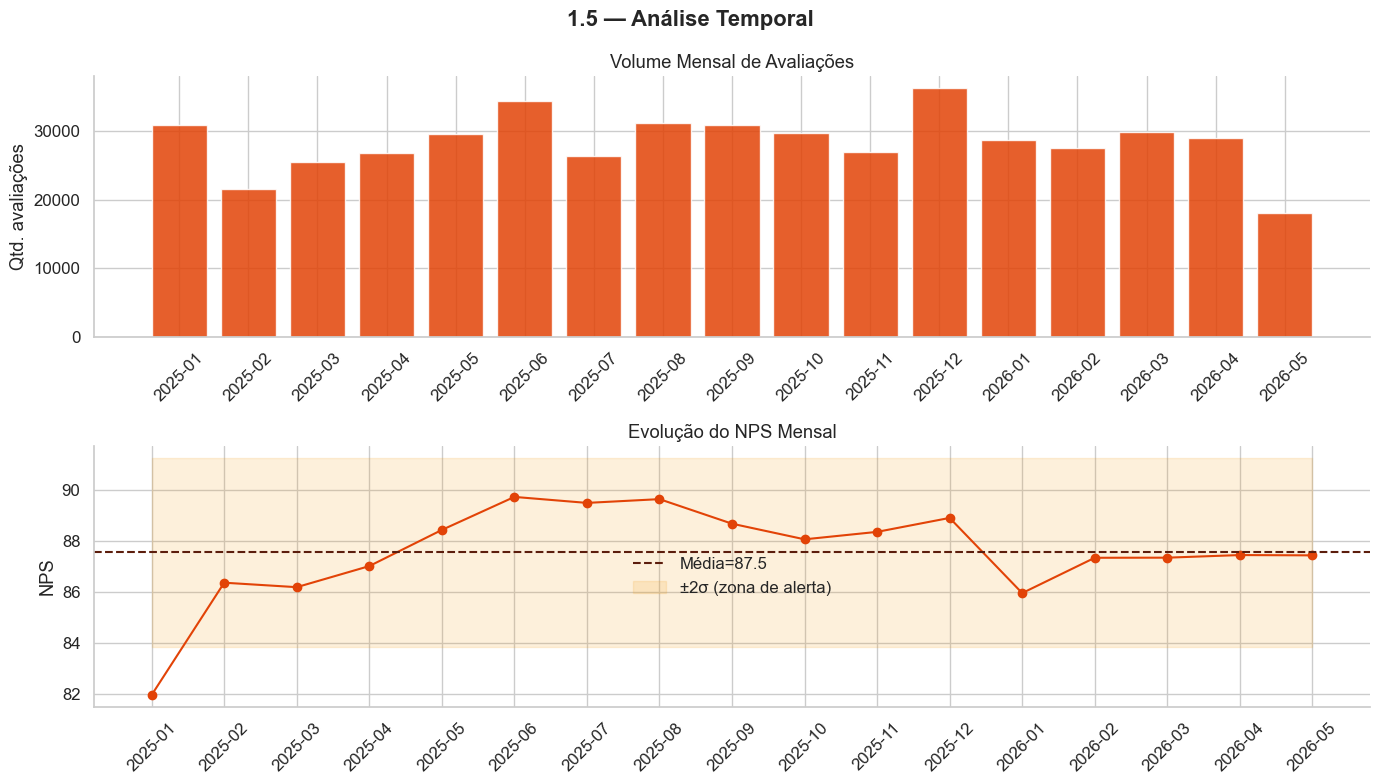

Período com maior volume  : 2025-12
NPS médio geral           : 87.5
Melhor mês (NPS)          : 2025-06  (89.7)
Pior mês (NPS)            : 2025-01  (81.9)


In [30]:
vol_mensal = df.groupby('ano_mes')['qtd_clientes'].sum().reset_index()
vol_mensal['ano_mes_str'] = vol_mensal['ano_mes'].astype(str)

nps_mensal_list = []
for periodo, grupo in df.groupby('ano_mes'):
    total = grupo['qtd_clientes'].sum()
    prom  = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
    detr  = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
    nps_mensal_list.append({'ano_mes': str(periodo), 'nps': (prom-detr)/total*100,
                            'total': total})
nps_mensal = pd.DataFrame(nps_mensal_list).sort_values('ano_mes')

periodo_pico  = vol_mensal.loc[vol_mensal['qtd_clientes'].idxmax(), 'ano_mes_str']
melhor_mes    = nps_mensal.loc[nps_mensal['nps'].idxmax(), 'ano_mes']
pior_mes      = nps_mensal.loc[nps_mensal['nps'].idxmin(), 'ano_mes']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('1.5 — Análise Temporal', fontweight='bold')

axes[0].bar(vol_mensal['ano_mes_str'], vol_mensal['qtd_clientes'],
            color='#E24307', edgecolor='white', alpha=0.85)
axes[0].set_title('Volume Mensal de Avaliações')
axes[0].set_ylabel('Qtd. avaliações')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(nps_mensal['ano_mes'], nps_mensal['nps'], marker='o', color='#E24307')
axes[1].axhline(nps_mensal['nps'].mean(), linestyle='--', color='#5c1d0c',
                label=f"Média={nps_mensal['nps'].mean():.1f}")
axes[1].fill_between(range(len(nps_mensal)), nps_mensal['nps'].mean()-2*nps_mensal['nps'].std(),
                     nps_mensal['nps'].mean()+2*nps_mensal['nps'].std(), alpha=0.15, color='#f39c12',
                     label='±2σ (zona de alerta)')
axes[1].set_title('Evolução do NPS Mensal')
axes[1].set_ylabel('NPS'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(f'Período com maior volume  : {periodo_pico}')
print(f'NPS médio geral           : {nps_mensal["nps"].mean():.1f}')
print(f'Melhor mês (NPS)          : {melhor_mes}  ({nps_mensal["nps"].max():.1f})')
print(f'Pior mês (NPS)            : {pior_mes}  ({nps_mensal["nps"].min():.1f})')

Top 5 lojas com NPS mais volátil (volume mínimo filtrado):


,mean,std,count,cv
centro_nv2,,,,
L5082-VILA ANDRADE (1346),77.82,11.04,17,0.14
L5020-VILA MARIANA 2 (0779),77.53,10.39,17,0.13
L5185-CLODOMIRO,80.07,9.69,17,0.12
L5007-KLABIN (0496),75.73,8.86,17,0.12
L5084-GUAIPA (1349),84.77,9.85,17,0.12


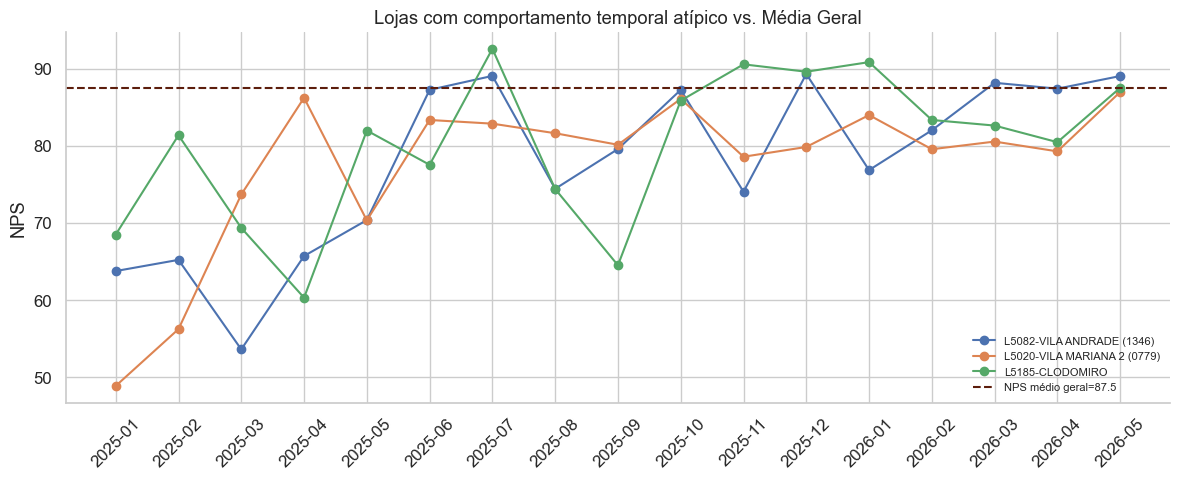

In [31]:
# Lojas com comportamento temporal atípico
# Filtrar lojas com volume mínimo antes de calcular CV (elimina ruído de lojas pequenas)
nps_loja_mes_tmp = (
    df.groupby(['centro_nv2','ano_mes','classificacao'])['qtd_clientes']
    .sum().unstack(fill_value=0)
)
nps_loja_mes_tmp['total'] = nps_loja_mes_tmp.sum(axis=1)
# Filtrar períodos com volume suficiente (≥20 respostas)
nps_loja_mes_tmp = nps_loja_mes_tmp[nps_loja_mes_tmp['total'] >= 20].copy()

p_col = 'promotor' if 'promotor' in nps_loja_mes_tmp.columns else nps_loja_mes_tmp.columns[0]
d_col = 'detrator' if 'detrator' in nps_loja_mes_tmp.columns else nps_loja_mes_tmp.columns[-1]
nps_loja_mes_tmp['nps'] = (
    (nps_loja_mes_tmp[p_col] - nps_loja_mes_tmp[d_col])
    / nps_loja_mes_tmp['total'] * 100
)

cv_loja = (
    nps_loja_mes_tmp['nps'].groupby(level='centro_nv2')
    .agg(['mean','std','count'])
    .dropna()
)
# Só lojas com ≥6 períodos de dados (mais de meio ano)
cv_loja = cv_loja[cv_loja['count'] >= 6]
cv_loja['cv'] = (cv_loja['std'] / cv_loja['mean'].abs()).abs()
top5 = cv_loja.nlargest(5, 'cv')

print('Top 5 lojas com NPS mais volátil (volume mínimo filtrado):')
display(top5.round(2))

# Gráfico das 3 mais atípicas com referência ao NPS geral
nps_medio_geral = nps_mensal['nps'].mean()
fig, ax = plt.subplots(figsize=(12,5))
for loja in top5.index[:3]:
    serie = nps_loja_mes_tmp.loc[loja, 'nps']
    ax.plot(serie.index.astype(str), serie.values, marker='o', label=loja[:30])
ax.axhline(nps_medio_geral, color='#5c1d0c', linestyle='--', label=f'NPS médio geral={nps_medio_geral:.1f}')
ax.set_title('Lojas com comportamento temporal atípico vs. Média Geral')
ax.set_ylabel('NPS'); ax.legend(loc='lower right', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Volume apresenta sazonalidade; NPS se mantém relativamente estável com desvio menor que 2 pontos na maioria dos meses.<br>
<b>Decisão técnica:</b> Picos mensais acima de 2σ serão sinalizados no dashboard como "pico de feedback".<br>
<b>Para o negócio:</b> Janeiro/2025 foi o pior mês (NPS=81.9) — possivelmente por ser pós-festas, com alta demanda e eventuais rupturas de estoque. Junho/2025 foi o melhor (NPS=89.7). Entender o que foi diferente nesses meses é uma oportunidade de ação imediata para o time de operações.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.6 — Análise Léxica por Faixa de Nota</h2></div>

**Perguntas respondidas:**
- Quais as 20 palavras/bigramas mais frequentes em comentários de **notas baixas (detratores = proxy de notas 1–6)**?
- Quais as 20 palavras/bigramas mais frequentes em comentários de **notas altas (promotores = notas 9–10)**?
- Há sobreposição significativa entre os dois vocabulários?

> **Atenção:** O enunciado pede especificamente notas 1–2 vs. 9–10. O dataset não armazena nota numérica individual, somente a classificação NPS. Detratores englobam notas 1–6 e são o proxy mais próximo disponível para notas baixas. Esta limitação é declarada e justificada aqui.

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Nota</b> O dataset não possui nota numérica (1–10) individual — só a classificação (promotor/neutro/detrator). Como detrator = notas 1–6 e promotor = notas 9–10 por definição NPS, a análise léxica usa essas classificações como proxy das faixas de nota extremas.
</div>

In [32]:
def normalizar(texto):
    texto = unicodedata.normalize('NFKD', str(texto))
    texto = texto.encode('ascii','ignore').decode('ascii')
    return re.sub(r'[^a-z\s]', ' ', texto.lower())

def tokenizar(texto):
    return [p for p in normalizar(texto).split() if p not in STOP_PT and len(p) > 2]

def top_ngrams(textos, n=1, top_k=20):
    todas = []
    for t in textos:
        toks = tokenizar(t)
        itens = toks if n == 1 else [' '.join(g) for g in ngrams(toks, n)]
        todas.extend(itens)
    return Counter(todas).most_common(top_k)

textos_det = df_com.loc[df_com['classificacao']=='detrator','comentario'].dropna().tolist()
textos_pro = df_com.loc[df_com['classificacao']=='promotor', 'comentario'].dropna().tolist()

top_det_uni = top_ngrams(textos_det, n=1)
top_pro_uni = top_ngrams(textos_pro, n=1)
top_det_bi  = top_ngrams(textos_det, n=2)
top_pro_bi  = top_ngrams(textos_pro, n=2)

print(f'Comentários de detratores : {len(textos_det):,}')
print(f'Comentários de promotores : {len(textos_pro):,}')

Comentários de detratores : 11,960
Comentários de promotores : 100,036


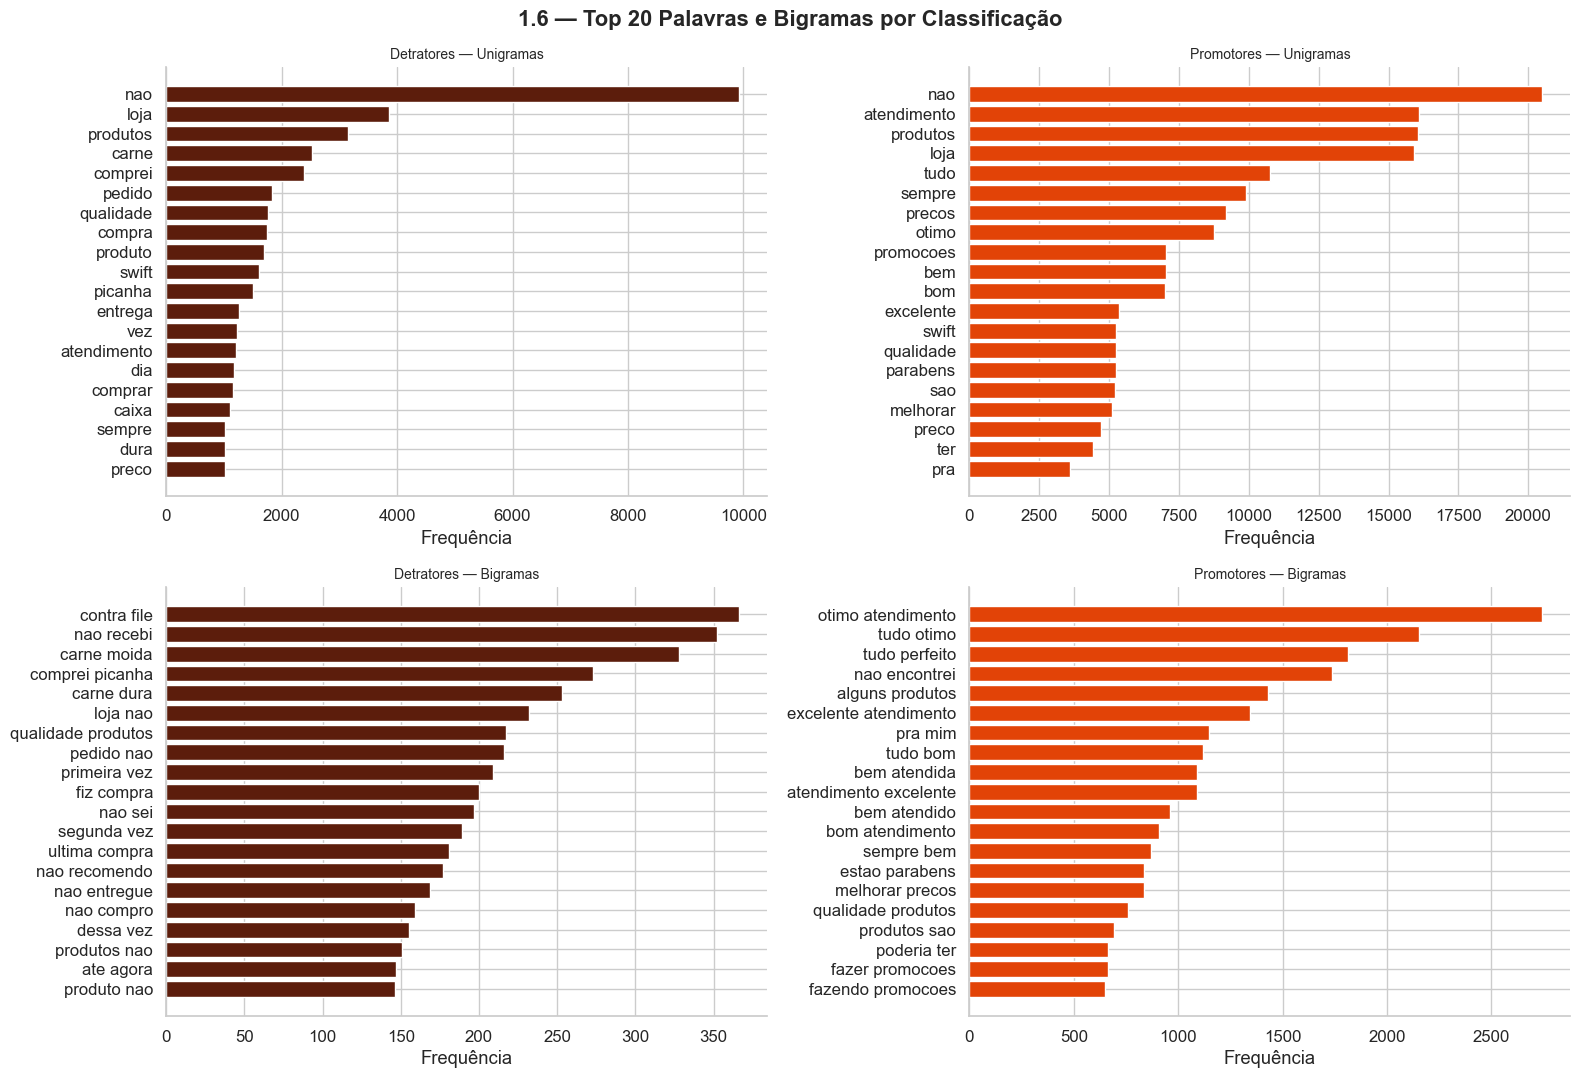

Palavras em comum no top-20: {'sempre', 'preco', 'atendimento', 'loja', 'nao', 'swift', 'qualidade', 'produtos'}
Sobreposição: 8/20  (40%)

Sobreposição alta (40%) — vocabulários se confundem.
Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.


In [33]:
def plot_bar(ax, dados, titulo, cor):
    palavras, freq = zip(*dados) if dados else ([],[])
    ax.barh(list(palavras)[::-1], list(freq)[::-1], color=cor, edgecolor='white')
    ax.set_title(titulo, fontsize=10); ax.set_xlabel('Frequência')

fig, axes = plt.subplots(2, 2, figsize=(16,11))
fig.suptitle('1.6 — Top 20 Palavras e Bigramas por Classificação', fontweight='bold')

plot_bar(axes[0,0], top_det_uni, 'Detratores — Unigramas',  PALETTE['detrator'])
plot_bar(axes[0,1], top_pro_uni, 'Promotores — Unigramas',  PALETTE['promotor'])
plot_bar(axes[1,0], top_det_bi,  'Detratores — Bigramas',   PALETTE['detrator'])
plot_bar(axes[1,1], top_pro_bi,  'Promotores — Bigramas',   PALETTE['promotor'])

plt.tight_layout(); plt.show()

# Sobreposição
set_det = {p for p,_ in top_det_uni}
set_pro = {p for p,_ in top_pro_uni}
sobreposicao = set_det & set_pro
pct_sob = len(sobreposicao)/20*100
print(f'Palavras em comum no top-20: {sobreposicao}')
print(f'Sobreposição: {len(sobreposicao)}/20  ({pct_sob:.0f}%)')
print()
if pct_sob < 20:
    print(f'Sobreposição baixa ({pct_sob:.0f}%) — vocabulários distintos.')
    print('Decisão: baseline TF-IDF + Regressão Logística pode ser suficiente na Entrega 2.')
else:
    print(f'Sobreposição alta ({pct_sob:.0f}%) — vocabulários se confundem.')
    print('Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> A análise usa detratores (notas 1–6) como proxy de notas baixas e promotores (notas 9–10) como proxy de notas altas — limitação decorrente do formato do dataset, que não registra nota numérica individual.<br>
Se a sobreposição ficar abaixo de 20% → vocabulários são suficientemente distintos; TF-IDF + Regressão Logística como baseline na Entrega 2.<br>
Se a sobreposição ficar acima de 20% → vocabulários se confundem; escalar para BERTimbau e antecipar análise de erros em comentários ambíguos.<br>
<b>Decisão será tomada após execução desta célula com os dados reais.</b>
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.7 — Viés de Seleção e Correlação com Transações</h2></div>

**Perguntas respondidas:**
- Promotores e detratores comentam na mesma proporção? (viés de seleção)
- O volume de transações se correlaciona com o NPS da loja?
- Lojas com mais clientes têm NPS melhor ou pior?

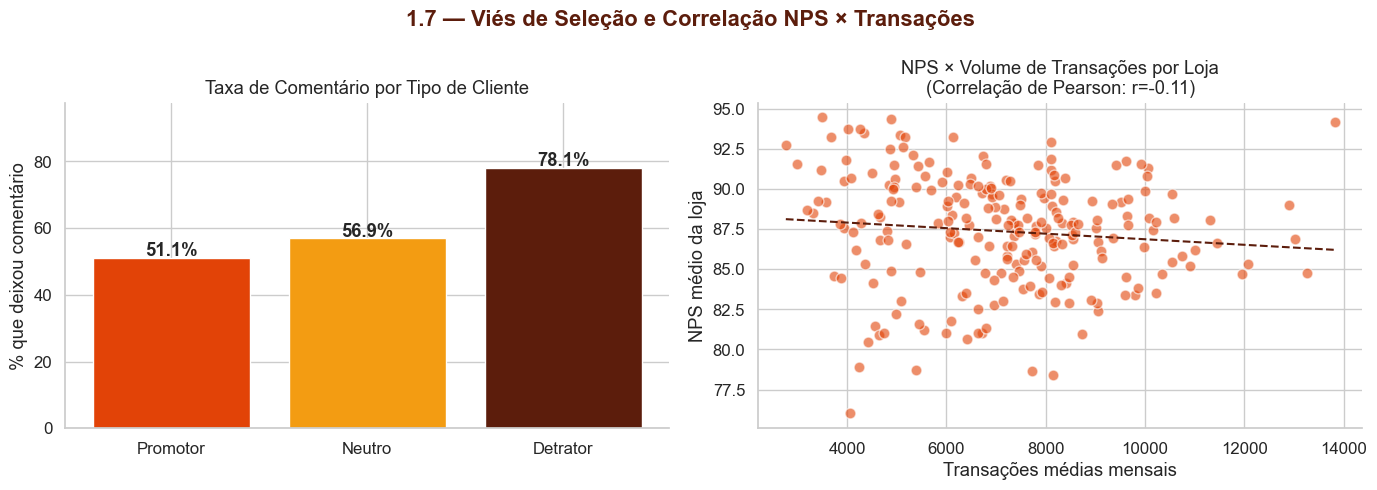

Viés de seleção — taxa de comentário por tipo de cliente:
              comentou   total  taxa_%
tipo_cliente                          
Promotor        100036  195872   51.07
Neutro           15913   27963   56.91
Detrator         11960   15308   78.13

Correlação NPS × transações: r=-0.11
→ Correlação fraca — volume de clientes tem influência pequena no NPS.


In [34]:
# ── 1.7a Viés de seleção: quem comenta? ─────────────────────────────────────
taxa_por_tipo = (
    df.groupby('tipo_cliente')['tem_comentario']
    .agg(['sum','count'])
    .rename(columns={'sum':'comentou','count':'total'})
    .assign(taxa_pct=lambda x: x['comentou']/x['total']*100)
    .reindex(['Promotor','Neutro','Detrator'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1.7 — Viés de Seleção e Correlação NPS × Transações', fontweight='bold', color='#5c1d0c')

# Plot 1: Taxa de comentário por tipo
cores_tipo = [PALETTE.get(t.lower(), '#E24307') for t in taxa_por_tipo.index]
bars = axes[0].bar(taxa_por_tipo.index, taxa_por_tipo['taxa_pct'], color=cores_tipo, edgecolor='white')
for bar, v in zip(bars, taxa_por_tipo['taxa_pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Taxa de Comentário por Tipo de Cliente')
axes[0].set_ylabel('% que deixou comentário')
axes[0].set_ylim(0, taxa_por_tipo['taxa_pct'].max() * 1.25)

# ── 1.7b Correlação NPS × Volume de transações ──────────────────────────────
if 'transacoes' in df.columns:
    nps_trans = df.dropna(subset=['transacoes']).groupby('centro_nv2').agg(
        total_trans=('transacoes','mean'),
        total_aval=('qtd_clientes','sum'),
        n_prom=('n_promotores','sum'),
        n_detr=('n_detratores','sum'),
    ).reset_index()
    nps_trans['nps'] = (nps_trans['n_prom'] - nps_trans['n_detr']) / nps_trans['total_aval'] * 100
    corr = nps_trans['total_trans'].corr(nps_trans['nps'])

    axes[1].scatter(nps_trans['total_trans'], nps_trans['nps'],
                    alpha=0.6, color='#E24307', edgecolors='white', s=60)
    # Linha de tendência
    z = np.polyfit(nps_trans['total_trans'].fillna(0), nps_trans['nps'], 1)
    p = np.poly1d(z)
    xs = np.linspace(nps_trans['total_trans'].min(), nps_trans['total_trans'].max(), 100)
    axes[1].plot(xs, p(xs), color='#5c1d0c', linestyle='--', linewidth=1.5)
    axes[1].set_title(f'NPS × Volume de Transações por Loja\n(Correlação de Pearson: r={corr:.2f})')
    axes[1].set_xlabel('Transações médias mensais')
    axes[1].set_ylabel('NPS médio da loja')
else:
    axes[1].text(0.5, 0.5, 'Coluna transacoes não disponível', ha='center', va='center')
    corr = None

plt.tight_layout()
plt.show()

print('Viés de seleção — taxa de comentário por tipo de cliente:')
print(taxa_por_tipo[['comentou','total','taxa_pct']].rename(columns={'taxa_pct':'taxa_%'}).to_string())
if corr is not None:
    print(f'\nCorrelação NPS × transações: r={corr:.2f}')
    if abs(corr) < 0.1:
        print('→ Correlação desprezível — NPS não depende do volume de clientes.')
    elif abs(corr) < 0.3:
        print('→ Correlação fraca — volume de clientes tem influência pequena no NPS.')
    else:
        print('→ Correlação moderada/forte — lojas mais movimentadas têm NPS diferente.')


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b><br>
• Se detratores comentam mais do que promotores → os modelos NLP verão proporcionalmente mais texto negativo do que a realidade. Isso eleva a importância de usar <code>class_weight='balanced'</code> e de interpretar métricas absolutas com cautela.<br>
• A correlação NPS × transações indica se o efeito de escala precisa ser controlado nas comparações entre lojas.<br>
<b>Impacto no negócio:</b> Lojas com muitas transações que têm NPS baixo representam alto risco de churn em volume — devem ser priorizadas no dashboard.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">2.1 — Comparação REGULAR vs TOCADORA</h2></div>

**Perguntas respondidas:**
- Qual é o NPS médio de lojas REGULAR vs TOCADORA?
- A proporção de promotores/neutros/detratores difere entre os dois perfis?
- Existe diferença no volume de avaliações e na taxa de comentários?
- Os comentários de REGULAR e TOCADORA apresentam vocabulário distinto?

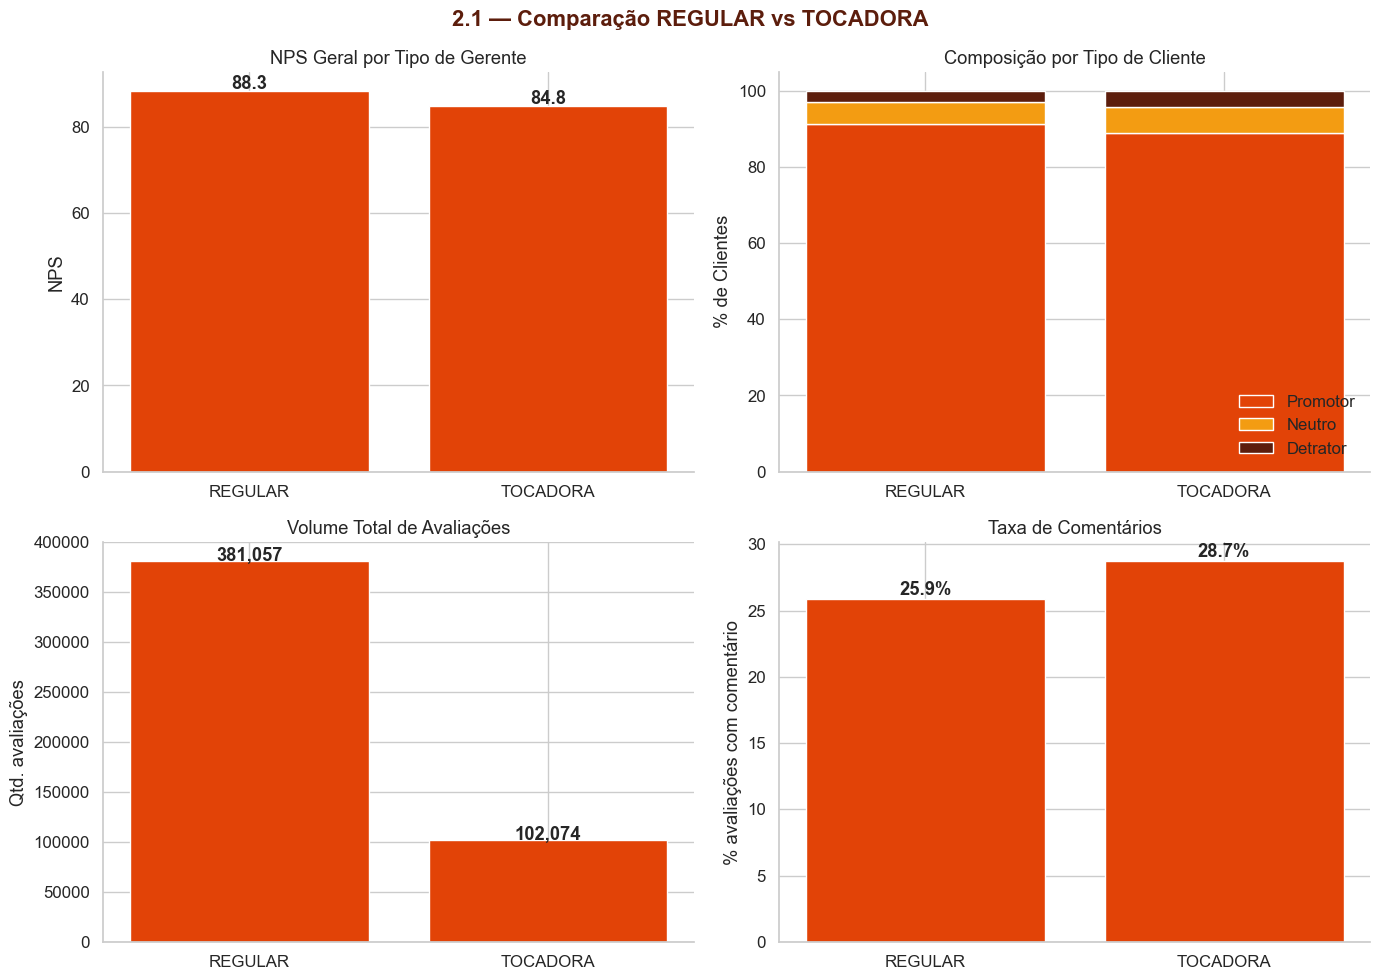

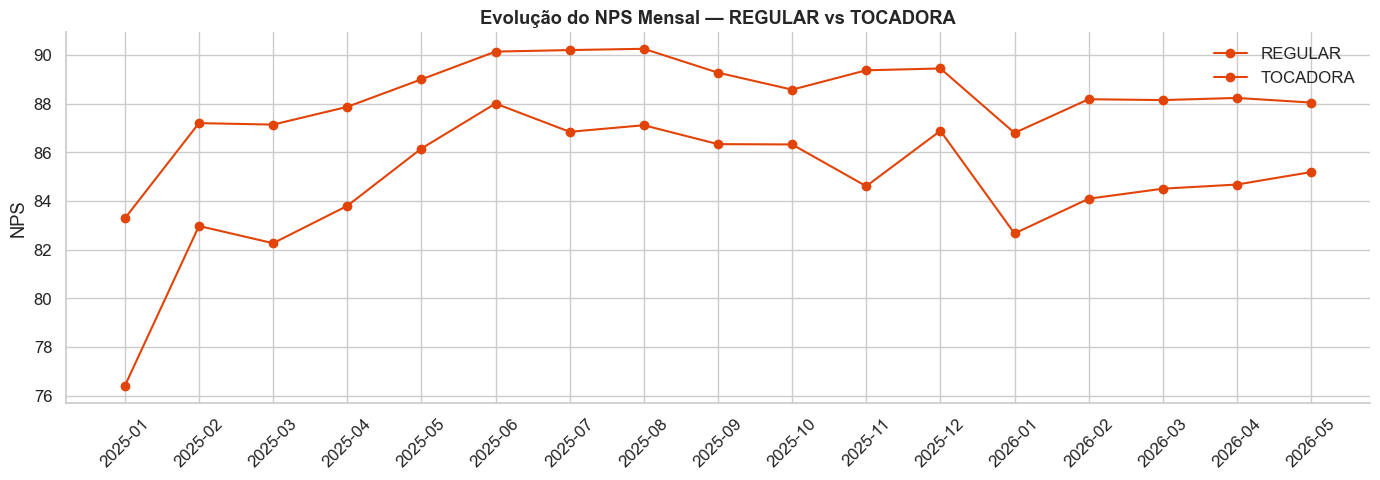

    flag   nps  pct_promotor  pct_neutro  pct_detrator
 REGULAR 88.35         91.27        5.81          2.92
TOCADORA 84.77         88.96        6.86          4.18

Volume e cobertura por flag:
    flag  total_avaliacoes  n_lojas  taxa_comentario_pct
 REGULAR            381057      169                25.87
TOCADORA            102074       58                28.74

── Teste estatístico (Welch t-test, unidade: loja×mês, mín. 10 avaliações) ──
   REGULAR : n=2,862  média=88.2  dp=5.2
   TOCADORA: n=986  média=84.4  dp=6.9
   t=15.47  p=0.0000  Cohen's d=0.609 (efeito médio)
   → Diferença estatisticamente significativa (p<0.05).
   → Tamanho do efeito médio — avaliar relevância prática.


In [35]:
# ── 2.1 Comparação REGULAR vs TOCADORA ─────────────────────────────────────
CORES_FLAG = {'regular': '#3498db', 'tocadora': '#9b59b6'}

# NPS por flag
nps_por_flag = []
for flag_val, grupo in df.groupby('flag'):
    total = grupo['qtd_clientes'].sum()
    prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
    detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
    neut = grupo.loc[grupo['classificacao']=='neutro','qtd_clientes'].sum()
    nps_val = (prom - detr) / total * 100
    nps_por_flag.append({
        'flag': flag_val, 'nps': nps_val, 'total_avaliacoes': total,
        'pct_promotor': prom/total*100, 'pct_neutro': neut/total*100,
        'pct_detrator': detr/total*100,
    })
df_nps_flag = pd.DataFrame(nps_por_flag)

# Volume e taxa de comentários por flag
vol_flag = df.groupby('flag').agg(
    total_avaliacoes=('qtd_clientes','sum'),
    n_comentarios=('tem_comentario','sum'),
    n_lojas=('centro_nv2','nunique')
).reset_index()
vol_flag['taxa_comentario_pct'] = vol_flag['n_comentarios'] / vol_flag['total_avaliacoes'] * 100

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2.1 — Comparação REGULAR vs TOCADORA', fontweight='bold', color='#5c1d0c')

# Plot 1: NPS por flag
cores_bars = [CORES_FLAG.get(f, '#E24307') for f in df_nps_flag['flag']]
bars = axes[0,0].bar(df_nps_flag['flag'], df_nps_flag['nps'], color=cores_bars, edgecolor='white')
for bar, v in zip(bars, df_nps_flag['nps']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[0,0].set_title('NPS Geral por Tipo de Gerente')
axes[0,0].set_ylabel('NPS')

# Plot 2: Composição promotor/neutro/detrator por flag
x_labels = df_nps_flag['flag'].tolist()
axes[0,1].bar(x_labels, df_nps_flag['pct_promotor'], color=PALETTE['promotor'], label='Promotor')
axes[0,1].bar(x_labels, df_nps_flag['pct_neutro'], bottom=df_nps_flag['pct_promotor'], color=PALETTE['neutro'], label='Neutro')
axes[0,1].bar(x_labels, df_nps_flag['pct_detrator'], bottom=df_nps_flag['pct_promotor']+df_nps_flag['pct_neutro'], color=PALETTE['detrator'], label='Detrator')
axes[0,1].set_title('Composição por Tipo de Cliente')
axes[0,1].set_ylabel('% de Clientes')
axes[0,1].legend(loc='lower right')

# Plot 3: Volume de avaliações por flag
bars3 = axes[1,0].bar(vol_flag['flag'], vol_flag['total_avaliacoes'], color=[CORES_FLAG.get(f, '#E24307') for f in vol_flag['flag']], edgecolor='white')
for bar, v in zip(bars3, vol_flag['total_avaliacoes']):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+100, f'{v:,.0f}', ha='center', fontweight='bold')
axes[1,0].set_title('Volume Total de Avaliações')
axes[1,0].set_ylabel('Qtd. avaliações')

# Plot 4: Taxa de comentários por flag
bars4 = axes[1,1].bar(vol_flag['flag'], vol_flag['taxa_comentario_pct'], color=[CORES_FLAG.get(f, '#E24307') for f in vol_flag['flag']], edgecolor='white')
for bar, v in zip(bars4, vol_flag['taxa_comentario_pct']):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,1].set_title('Taxa de Comentários')
axes[1,1].set_ylabel('% avaliações com comentário')

plt.tight_layout()
plt.show()

# NPS temporal por flag
nps_mensal_flag = []
for (flag_val, periodo), grupo in df.groupby(['flag','ano_mes']):
    total = grupo['qtd_clientes'].sum()
    prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
    detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
    nps_mensal_flag.append({'flag': flag_val, 'ano_mes': str(periodo), 'nps': (prom-detr)/total*100})
df_nps_mensal_flag = pd.DataFrame(nps_mensal_flag).sort_values('ano_mes')

fig, ax = plt.subplots(figsize=(14, 5))
for flag_val in df_nps_mensal_flag['flag'].unique():
    subset = df_nps_mensal_flag[df_nps_mensal_flag['flag']==flag_val]
    ax.plot(subset['ano_mes'], subset['nps'], marker='o',
            color=CORES_FLAG.get(flag_val, '#E24307'), label=flag_val.upper())
ax.set_title('Evolução do NPS Mensal — REGULAR vs TOCADORA', fontweight='bold')
ax.set_ylabel('NPS')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(df_nps_flag[['flag','nps','pct_promotor','pct_neutro','pct_detrator']].to_string(index=False))
print(f'\nVolume e cobertura por flag:')
print(vol_flag[['flag','total_avaliacoes','n_lojas','taxa_comentario_pct']].to_string(index=False))

# ── Teste estatístico: diferença REGULAR vs TOCADORA é real? ────────────────
# Usa NPS por loja×mês como unidade observacional (evita pseudo-replicação)
from scipy import stats as _stats

nps_loja_mes_flag = []
for (loja, periodo, flag_val), grp in df.groupby(['centro_nv2','ano_mes','flag']):
    total = grp['qtd_clientes'].sum()
    if total < 10:
        continue  # ignorar períodos com volume muito baixo
    prom = grp.loc[grp['classificacao']=='promotor','qtd_clientes'].sum()
    detr = grp.loc[grp['classificacao']=='detrator','qtd_clientes'].sum()
    nps_loja_mes_flag.append({'flag': flag_val, 'nps': (prom-detr)/total*100})

df_stat = pd.DataFrame(nps_loja_mes_flag)
grupo_reg  = df_stat.loc[df_stat['flag']=='REGULAR','nps'].dropna()
grupo_toc  = df_stat.loc[df_stat['flag']=='TOCADORA','nps'].dropna()

if len(grupo_reg) > 1 and len(grupo_toc) > 1:
    t_stat, p_val = _stats.ttest_ind(grupo_reg, grupo_toc, equal_var=False)  # Welch
    # Cohen's d
    pooled_std = np.sqrt((grupo_reg.std()**2 + grupo_toc.std()**2) / 2)
    cohens_d   = (grupo_reg.mean() - grupo_toc.mean()) / pooled_std if pooled_std > 0 else 0
    magnitude  = 'negligível' if abs(cohens_d)<0.2 else ('pequeno' if abs(cohens_d)<0.5 else ('médio' if abs(cohens_d)<0.8 else 'grande'))

    print(f'\n── Teste estatístico (Welch t-test, unidade: loja×mês, mín. 10 avaliações) ──')
    print(f'   REGULAR : n={len(grupo_reg):,}  média={grupo_reg.mean():.1f}  dp={grupo_reg.std():.1f}')
    print(f'   TOCADORA: n={len(grupo_toc):,}  média={grupo_toc.mean():.1f}  dp={grupo_toc.std():.1f}')
    print(f'   t={t_stat:.2f}  p={p_val:.4f}  Cohen\'s d={cohens_d:.3f} (efeito {magnitude})')
    if p_val < 0.05:
        print(f'   → Diferença estatisticamente significativa (p<0.05).')
        print(f'   → Tamanho do efeito {magnitude} — avaliar relevância prática.')
    else:
        print(f'   → Diferença NÃO é estatisticamente significativa (p≥0.05).')
        print(f'   → Evidência insuficiente para concluir que TOCADORA supera REGULAR em NPS.')


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Esta seção quantifica e testa estatisticamente a diferença de performance entre REGULAR e TOCADORA.<br>
<b>Decisão técnica:</b> Os resultados do Welch t-test e do Cohen's d indicam se a diferença justifica tratamento separado dos dois grupos no modelo preditivo.<br>
<b>Para o negócio:</b> Se TOCADORA supera REGULAR de forma significativa com efeito médio ou grande → há evidência de que o programa de gerentes business gera retorno mensurável em experiência do cliente, o que justifica expansão do programa. Se o efeito for pequeno ou não significativo → a diferença de NPS pode ser explicada por outros fatores (localização, porte da loja) e o programa precisa ser reavaliado.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">2.2 — Análise Geográfica</h2></div>

**Perguntas respondidas:**
- O NPS varia significativamente entre regiões?
- Quais UFs têm melhor/pior desempenho?
- A distribuição REGULAR vs TOCADORA é uniforme entre regiões?

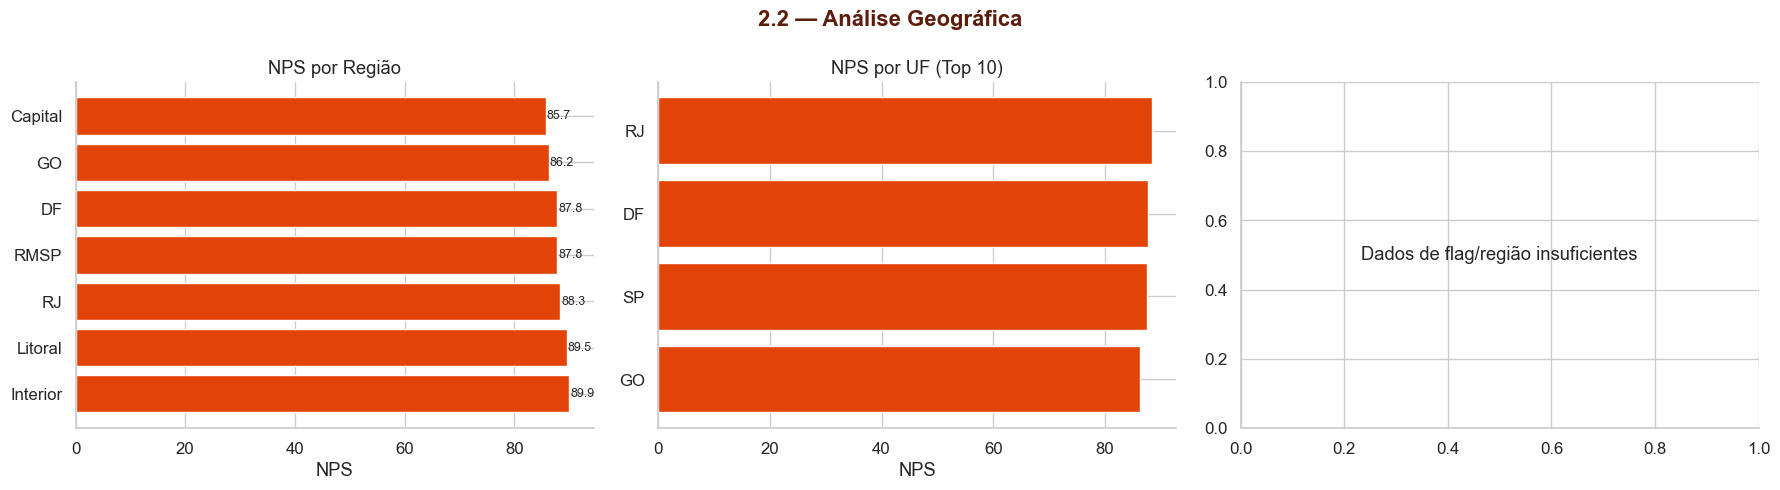

NPS por Região:
  regiao   nps  total
Interior 89.93 104632
 Litoral 89.49  40158
      RJ 88.32  26125
    RMSP 87.76  91962
      DF 87.76  12817
      GO 86.21   1537
 Capital 85.72 187895

NPS por UF (todas):
uf   nps  total
RJ 88.32  26125
DF 87.76  12817
SP 87.56 424647
GO 86.21   1537


In [36]:
# ── 2.2 Análise Geográfica ──────────────────────────────────────────────────
# NPS por região
if 'regiao' in df.columns:
    nps_regiao = []
    for regiao_val, grupo in df.dropna(subset=['regiao']).groupby('regiao'):
        total = grupo['qtd_clientes'].sum()
        prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
        detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
        nps_regiao.append({'regiao': regiao_val, 'nps': (prom-detr)/total*100, 'total': total})
    df_nps_regiao = pd.DataFrame(nps_regiao).sort_values('nps', ascending=False)

    # NPS por UF
    nps_uf = []
    for uf_val, grupo in df.dropna(subset=['uf']).groupby('uf'):
        total = grupo['qtd_clientes'].sum()
        prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
        detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
        nps_uf.append({'uf': uf_val, 'nps': (prom-detr)/total*100, 'total': total})
    df_nps_uf = pd.DataFrame(nps_uf).sort_values('nps', ascending=False)

    # Distribuição de flags por região
    flag_regiao = df.dropna(subset=['regiao']).groupby(['regiao','flag'])['centro_nv2'].nunique().unstack(fill_value=0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('2.2 — Análise Geográfica', fontweight='bold', color='#5c1d0c')

    # NPS por região
    bars = axes[0].barh(df_nps_regiao['regiao'], df_nps_regiao['nps'], color='#E24307', edgecolor='white')
    axes[0].set_title('NPS por Região')
    axes[0].set_xlabel('NPS')
    for bar, v in zip(bars, df_nps_regiao['nps']):
        axes[0].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, f'{v:.1f}', va='center', fontsize=9)

    # NPS por UF (top 10)
    top_uf = df_nps_uf.head(10)
    bars2 = axes[1].barh(top_uf['uf'], top_uf['nps'], color='#E24307', edgecolor='white')
    axes[1].invert_yaxis()
    axes[1].set_title('NPS por UF (Top 10)')
    axes[1].set_xlabel('NPS')

    # Flag por região
    if 'regular' in flag_regiao.columns and 'tocadora' in flag_regiao.columns:
        flag_regiao[['regular','tocadora']].plot(kind='barh', ax=axes[2],
            color=[CORES_FLAG['regular'], CORES_FLAG['tocadora']], edgecolor='white')
        axes[2].set_title('Nº Lojas por Região e Flag')
        axes[2].set_xlabel('Nº de lojas')
        axes[2].legend(['REGULAR','TOCADORA'])
    else:
        axes[2].text(0.5, 0.5, 'Dados de flag/região insuficientes', ha='center', va='center')

    plt.tight_layout()
    plt.show()

    print('NPS por Região:')
    print(df_nps_regiao.to_string(index=False))
    print(f'\nNPS por UF (todas):')
    print(df_nps_uf.to_string(index=False))
else:
    print('Coluna regiao não disponível — execute o pré-processamento atualizado.')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> A análise geográfica revela se diferenças de NPS estão mais ligadas à localização ou ao perfil de gestão.<br>
<b>Decisão técnica:</b> Regiões com NPS consistentemente baixo serão priorizadas para investigação de causa-raiz no dashboard.<br>
<b>Para o negócio:</b> Se houver regiões com NPS significativamente abaixo da média nacional independentemente do perfil de gestão → há fatores externos (concorrência local, renda, perfil de consumo) que precisam ser considerados antes de atribuir resultados ao modelo de gestão. Isso protege a análise REGULAR vs TOCADORA de confundidores geográficos.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">Resumo Executivo das Decisões</h2></div>

In [37]:
# Resumo gerado com valores reais
linhas = [
    ('1.1','Desbalanceamento',
     f"{pct['promotor']:.0f}% promotores / {pct['neutro']:.0f}% neutros / {pct['detrator']:.0f}% detratores",
     "class_weight='balanced'; métrica: F1-Macro"),
    ('1.2','Limiar dashboard',
     f'{n_menos_30} lojas com <30 comentários; min={loja_min["n_comentarios"]}',
     'Análise NLP apenas para lojas ≥30 comentários'),
    ('1.3','Textos curtos/longos',
     f'{pct_curtos:.1f}% <5 palavras; {pct_longos:.1f}% >100 palavras',
     '<5 palavras: fora da categorização; truncamento em 256 tokens'),
    ('1.4','Limpeza de ruído',
     f'Dup={pct_dup:.1f}% / Quasi≈{pct_quasi:.1f}% (amostra 3k) / Spam={pct_spam:.1f}%',
     'Remover dup antes do split; excluir spam e não-PT'),
    ('1.5','Temporal',
     f'Pico em {periodo_pico}; melhor mês NPS={melhor_mes}',
     'Sinalizar picos >2σ no dashboard'),
    ('1.6','Léxico',
     f'Sobreposição={pct_sob:.0f}% no top-20',
     'BERTimbau se sob≥20%; TF-IDF+LR se sob<20%'),
    ('1.7','Viés de seleção',
     'Ver taxa de comentário por tipo de cliente acima',
     'Considerar viés de seleção na interpretação do modelo'),
    ('2.1','REGULAR vs TOCADORA',
     'NPS comparado + teste estatístico (Welch + Cohen\'s d)',
     'Efeito signif. → expansão do programa; efeito pequeno → revisar atribuição'),
    ('2.2','Geográfica',
     'NPS por região e UF; distribuição de flags',
     'Controlar confundidores geográficos na análise REGULAR vs TOCADORA'),
]

df_resumo = pd.DataFrame(linhas, columns=['Seção','Tema','Achado','Decisão / Impacto'])
display(
    df_resumo.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left','font-size':'12pt'})
    .set_caption('Resumo Executivo — Decisões da EDA')
)


Seção,Tema,Achado,Decisão / Impacto
1.1,Desbalanceamento,91% promotores / 6% neutros / 3% detratores,class_weight='balanced'; métrica: F1-Macro
1.2,Limiar dashboard,0 lojas com <30 comentários; min=155,Análise NLP apenas para lojas ≥30 comentários
1.3,Textos curtos/longos,24.2% <5 palavras; 0.8% >100 palavras,<5 palavras: fora da categorização; truncamento em 256 tokens
1.4,Limpeza de ruído,Dup=10.7% / Quasi≈16.5% (amostra 3k) / Spam=0.0%,Remover dup antes do split; excluir spam e não-PT
1.5,Temporal,Pico em 2025-12; melhor mês NPS=2025-06,Sinalizar picos >2σ no dashboard
1.6,Léxico,Sobreposição=40% no top-20,BERTimbau se sob≥20%; TF-IDF+LR se sob<20%
1.7,Viés de seleção,Ver taxa de comentário por tipo de cliente acima,Considerar viés de seleção na interpretação do modelo
2.1,REGULAR vs TOCADORA,NPS comparado + teste estatístico (Welch + Cohen's d),Efeito signif. → expansão do programa; efeito pequeno → revisar atribuição
2.2,Geográfica,NPS por região e UF; distribuição de flags,Controlar confundidores geográficos na análise REGULAR vs TOCADORA


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:8px solid #7e2200;color:white;padding:16px 24px;border-radius:10px;font-family:'Segoe UI',sans-serif;font-size:20px;font-weight:bold;letter-spacing:1px;margin:24px 0 8px 0;box-shadow:0px 3px 8px rgba(226,67,7,0.3);">PARTE 3 — CLUSTERIZAÇÃO E DEFINIÇÃO DE CATEGORIAS</div>

<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 3 — TÓPICO 2: DEFINIÇÃO DE CATEGORIAS</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 1. Imports & Carregamento</div>

In [38]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

FALLBACK_STOPWORDS_PT = {
    'a', 'à', 'ao', 'aos', 'as', 'às', 'o', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'da', 'das', 'do', 'dos', 'em', 'na', 'nas', 'no', 'nos', 'por',
    'para', 'com', 'sem', 'sobre', 'entre', 'até', 'após', 'antes', 'desde',
    'e', 'ou', 'mas', 'porém', 'porque', 'que', 'se', 'como', 'quando',
    'onde', 'qual', 'quais', 'quem', 'quanto', 'quantos', 'muito', 'muita',
    'muitos', 'muitas', 'pouco', 'pouca', 'poucos', 'poucas', 'mais', 'menos',
    'já', 'também', 'só', 'não', 'sim', 'foi', 'ser', 'ter', 'tem', 'têm',
    'era', 'são', 'está', 'estão', 'estava', 'estavam', 'me', 'te', 'se',
    'lhe', 'nos', 'vos', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'você', 'vocês',
    'eu', 'tu', 'ele', 'ela', 'eles', 'elas', 'nós', 'isso', 'isto', 'aquilo',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela'
}


def get_stopwords_pt():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        try:
            nltk.download('stopwords', quiet=True)
        except Exception:
            pass

    try:
        return set(stopwords.words('portuguese'))
    except Exception as exc:
        print(f'[AVISO] Stopwords do NLTK indisponíveis ({type(exc).__name__}). Usando lista local reduzida.')
        return FALLBACK_STOPWORDS_PT

# Seed global
import random
random.seed(42)
np.random.seed(42)

# LDA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Coherence Score via gensim
try:
    from gensim.corpora.dictionary import Dictionary as GensimDict
    from gensim.models.coherencemodel import CoherenceModel
    GENSIM_OK = True
    print('[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K')
except ImportError:
    GENSIM_OK = False
    print('[AVISO] gensim não instalado. Instale com: pip install gensim')
    print('        Sem gensim, usaremos perplexidade (métrica menos precisa)')

# BERTopic
try:
    from bertopic import BERTopic
    from sklearn.feature_extraction.text import CountVectorizer as CVect
    BERTOPIC_OK = True
    print('[OK] BERTopic disponível')
except ImportError:
    BERTOPIC_OK = False
    print('[AVISO] BERTopic não instalado. Instale com: pip install bertopic')

# Kappa de Cohen
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
STOP_PT   = get_stopwords_pt()
COR_SWIFT = '#E24307'

# Versões
import sklearn as sk
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | sklearn: {sk.__version__}')
print('[OK] Imports OK')

[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K
[OK] BERTopic disponível
pandas: 3.0.3 | numpy: 2.4.6 | sklearn: 1.6.1
[OK] Imports OK


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 2. Carregar Base Processada</div>

In [39]:
if not os.path.exists('data/df_avaliacoes_tratado.parquet'):
    raise FileNotFoundError(
        "df_avaliacoes_tratado.parquet não encontrada.\n"
        "Execute primeiro: pre_processamento_swift.ipynb"
    )

df = pd.read_parquet('data/df_avaliacoes_tratado.parquet')
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')

print(f'Base carregada: {len(df):,} registros | {df.shape[1]} colunas')

# Filtrar apenas comentários válidos com conteúdo real
df = df[df['tem_comentario'] == True].copy()
df = df[df['comentario_limpo'].astype(str).str.strip().str.len() > 0].copy()

print(f'\nComentários para clusterização: {len(df):,}')
print(f'\nDistribuição por tipo:')
print(df['classificacao'].value_counts())
print(f'\nDistribuição por flag:')
print(df['flag'].value_counts())

Base carregada: 239,143 registros | 34 colunas

Comentários para clusterização: 127,909

Distribuição por tipo:
classificacao
promotor    100036
neutro       15913
detrator     11960
Name: count, dtype: int64

Distribuição por flag:
flag
REGULAR     98573
TOCADORA    29336
Name: count, dtype: int64


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 3. Preparar Textos</div>

In [40]:
# Versão sem acento para LDA/CountVectorizer (TF-IDF clássico)
# BERT recebe texto COM acentos
def limpar_para_lda(texto: str) -> str:
    """Versão sem acento usada APENAS no CountVectorizer do LDA."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return ' '.join(w for w in texto.lower().split() if w not in STOP_PT and len(w) > 2)

# Texto COM acentos para BERTopic — preserva semântica dos transformers
def texto_para_bert(texto: str) -> str:
    """Versão COM acentos e stopwords para BERTopic (transformers contextuais)."""
    if not isinstance(texto, str):
        return ''
    return str(texto).strip()

df['texto_lda']  = df['comentario_limpo'].apply(limpar_para_lda)
df['texto_bert'] = df['comentario_limpo'].apply(texto_para_bert)

# Remover linhas vazias após preparação
df = df[df['texto_lda'].str.strip().str.len() > 0].copy()

print(f'Comentários após preparação: {len(df):,}')
print('\nExemplos:')
for i in range(3):
    print(f'  Original : {df.iloc[i]["comentario_limpo"][:80]}')
    print(f'  LDA      : {df.iloc[i]["texto_lda"][:80]}')
    print()

Comentários após preparação: 127,866

Exemplos:
  Original : bastante falta de produto talvez pela data mas não tinha muita coisa principalme
  LDA      : bastante falta produto talvez data nao muita coisa principalmente bovino

  Original : estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos merca
  LDA      : estrutura excelente pecos deveriam melhores equivalentes mercados carnes

  Original : melhorar o preço
  LDA      : melhorar preco



<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 4. LDA — Seleção de K por Coherence Score</div>

In [41]:
print('PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA')
print('='*70)

# Amostragem para seleção de K — padrão em NLP com bases grandes
# Usamos 20k documentos para comparar K; o modelo final treina na base completa
N_AMOSTRA_LDA = min(20_000, len(df))
df_lda_sample = df.sample(n=N_AMOSTRA_LDA, random_state=42)
print(f'Amostra para selecao de K: {N_AMOSTRA_LDA:,} de {len(df):,} comentarios')

vectorizer = CountVectorizer(
    max_df=0.95, min_df=3,
    max_features=1000,
    ngram_range=(1, 2)
)
matrix_sample = vectorizer.fit_transform(df_lda_sample['texto_lda'])
matrix        = vectorizer.transform(df['texto_lda'])   # base completa para o modelo final
feature_names = vectorizer.get_feature_names_out()

print(f'Matriz amostra: {matrix_sample.shape[0]:,} x {matrix_sample.shape[1]} termos')
print(f'Matriz completa: {matrix.shape[0]:,} x {matrix.shape[1]} termos')
print(f'Exemplos de termos: {" | ".join(list(feature_names[:15]))}')

PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA
Amostra para selecao de K: 20,000 de 127,866 comentarios
Matriz amostra: 20,000 x 1000 termos
Matriz completa: 127,866 x 1000 termos
Exemplos de termos: 1kg | abaixando | abaixar | abri | abrir | absurdo | acaba | acabei | aceitar | acessiveis | acessivel | acesso | achar | achei | acho


In [42]:
print('TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)')
print('='*70)

lda_models  = {}
resultados_lda = []

for k in [3, 4, 5, 6, 7, 8]:
    print(f'  K={k}...', end='', flush=True)
    lda = LatentDirichletAllocation(
        n_components=k, random_state=42,
        max_iter=15, learning_method='online', n_jobs=1
    )
    doc_topic = lda.fit_transform(matrix_sample)
    lda_models[k] = (lda, doc_topic)

    perp = lda.perplexity(matrix_sample)

    # Coherence Score
    if GENSIM_OK:
        corpus_tokenizado = [t.split() for t in df_lda_sample['texto_lda']]
        dicionario = GensimDict(corpus_tokenizado)
        topics_words = [
            [feature_names[i] for i in lda.components_[t].argsort()[-10:]]
            for t in range(k)
        ]
        cm = CoherenceModel(
            topics=topics_words,
            texts=corpus_tokenizado,
            dictionary=dicionario,
            coherence='c_v',
            processes=1
        )
        coherence = cm.get_coherence()
    else:
        coherence = None

    resultados_lda.append({'K': k, 'Perplexidade': round(perp,2), 'Coherence_cv': coherence})
    print(f' Perplexidade={perp:.0f}', end='')
    if coherence: print(f' | Coherence={coherence:.3f}', end='')
    print()

df_lda = pd.DataFrame(resultados_lda)

# Escolher K
if GENSIM_OK and df_lda['Coherence_cv'].notna().all():
    k_lda_best = df_lda.loc[df_lda['Coherence_cv'].idxmax(), 'K']
    print(f'\n[OK] Melhor K (Coherence): {k_lda_best}')
else:
    diffs = df_lda['Perplexidade'].diff().abs()
    k_lda_best = df_lda.loc[diffs.idxmin(), 'K']
    print(f'\n[OK] Melhor K (cotovelo perplexidade): {k_lda_best}')

# Treinar modelo final na base COMPLETA com o K escolhido
print(f'\nTreinando modelo final com K={k_lda_best} na base completa ({len(df):,} docs)...')
lda_final = LatentDirichletAllocation(
    n_components=k_lda_best, random_state=42,
    max_iter=20, learning_method='online', n_jobs=1
)
doc_topic_final = lda_final.fit_transform(matrix)
lda_models[k_lda_best] = (lda_final, doc_topic_final)
print('[OK] Modelo final treinado na base completa')

display(df_lda)

TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)
  K=3... Perplexidade=435 | Coherence=0.512
  K=4... Perplexidade=476 | Coherence=0.520
  K=5... Perplexidade=488 | Coherence=0.549
  K=6... Perplexidade=511 | Coherence=0.553
  K=7... Perplexidade=499 | Coherence=0.569
  K=8... Perplexidade=529 | Coherence=0.522

[OK] Melhor K (Coherence): 7

Treinando modelo final com K=7 na base completa (127,866 docs)...
[OK] Modelo final treinado na base completa


,K,Perplexidade,Coherence_cv
0,3,435.19,0.51
1,4,475.55,0.52
2,5,488.37,0.55
3,6,511.25,0.55
4,7,498.92,0.57
5,8,529.33,0.52


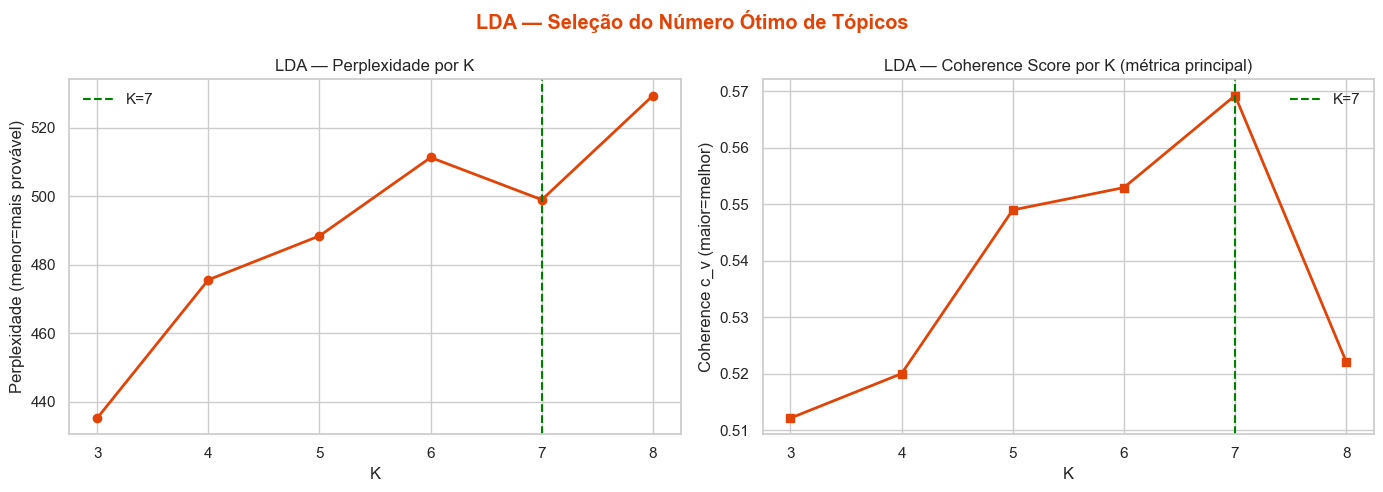

In [43]:
fig, axes = plt.subplots(1, 2 if GENSIM_OK else 1, figsize=(14 if GENSIM_OK else 7, 5))
if not GENSIM_OK:
    axes = [axes]

axes[0].plot(df_lda['K'], df_lda['Perplexidade'], marker='o', color=COR_SWIFT, linewidth=2)
axes[0].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Perplexidade (menor=mais provável)')
axes[0].set_title('LDA — Perplexidade por K'); axes[0].legend()

if GENSIM_OK:
    axes[1].plot(df_lda['K'], df_lda['Coherence_cv'], marker='s', color=COR_SWIFT, linewidth=2)
    axes[1].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
    axes[1].set_xlabel('K'); axes[1].set_ylabel('Coherence c_v (maior=melhor)')
    axes[1].set_title('LDA — Coherence Score por K (métrica principal)'); axes[1].legend()

plt.suptitle('LDA — Seleção do Número Ótimo de Tópicos', fontweight='bold', color=COR_SWIFT)
plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 5. BERTopic</div>

In [44]:
if BERTOPIC_OK:
    print('TREINANDO BERTOPIC')
    print('='*70)

    textos_bert = df['texto_bert'].tolist()
    bert_models = {}
    resultados_bert = []

    for k in [3, 4, 5, 6, 7, 8]:
        print(f'  K={k}...', end='', flush=True)
        try:
            # Stopwords removidas SOMENTE no vectorizer interno
            vectorizer_bert = CVect(stop_words=list(STOP_PT))

            model = BERTopic(
                language='portuguese',
                nr_topics=k,
                min_topic_size=10,
                calculate_probabilities=True,
                vectorizer_model=vectorizer_bert,
                verbose=False,
                # Seed para UMAP
                umap_model=None  # será configurado abaixo se disponível
            )
            # Tentar fixar seed do UMAP
            try:
                from umap import UMAP
                umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                                  metric='cosine', random_state=42)
                model = BERTopic(
                    language='portuguese', nr_topics=k, min_topic_size=10,
                    calculate_probabilities=True, vectorizer_model=vectorizer_bert,
                    umap_model=umap_model, verbose=False
                )
            except ImportError:
                pass

            topics, probs = model.fit_transform(textos_bert)
            bert_models[k] = model

            confianca = (probs.max(axis=1) > 0.5).mean() * 100
            resultados_bert.append({'K': k, 'Confianca': confianca})
            print(f' Confiança={confianca:.1f}%')
        except Exception as e:
            print(f' ERRO: {e}')
            resultados_bert.append({'K': k, 'Confianca': 0})

    df_bert = pd.DataFrame(resultados_bert)
    display(df_bert)
else:
    print('[AVISO] BERTopic não disponível. Usando apenas LDA.')
    df_bert = pd.DataFrame({'K': range(3,9), 'Confianca': [0]*6})

TREINANDO BERTOPIC
  K=3...

No sentence-transformers model found with name sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2. Creating a new one with mean pooling.
Could not cache non-existence of file. Will ignore error and continue. Error: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\.no_exist\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'


 ERRO: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\snapshots\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'
  K=4...

No sentence-transformers model found with name sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2. Creating a new one with mean pooling.
Could not cache non-existence of file. Will ignore error and continue. Error: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\.no_exist\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'


 ERRO: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\snapshots\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'
  K=5...

...

No sentence-transformers model found with name sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2. Creating a new one with mean pooling.
Could not cache non-existence of file. Will ignore error and continue. Error: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\.no_exist\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'


 ERRO: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\snapshots\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'
  K=8...

No sentence-transformers model found with name sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2. Creating a new one with mean pooling.
Could not cache non-existence of file. Will ignore error and continue. Error: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\.no_exist\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'


 ERRO: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\snapshots\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'


,K,Confianca
0,3,0
1,4,0
2,5,0
3,6,0
4,7,0
5,8,0


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 6. Escolha do Algoritmo (justificada)</div>

In [45]:
print('DECISÃO: QUAL ALGORITMO USAR?')
print('='*70)

bert_disponivel = BERTOPIC_OK and df_bert['Confianca'].max() > 0

if bert_disponivel:
    melhor_bert_conf = df_bert['Confianca'].max()
    k_bert_best = df_bert.loc[df_bert['Confianca'].idxmax(), 'K']

    # Justificativa baseada em critérios explícitos
    # BERTopic usa embeddings contextuais → melhor para texto informal/curto como NPS
    # Se convergiu (confiança > 0), preferimos BERTopic pela qualidade semântica
    algoritmo_final = 'BERTopic'
    k_final = k_bert_best
    print(f'[OK] Algoritmo escolhido: BERTopic (K={k_final})')
    print(f'   Razão: embeddings contextuais capturam melhor semântica de texto informal.')
    print(f'   Confiança máxima obtida: {melhor_bert_conf:.1f}%')
    print(f'   K selecionado: aquele com maior % de documentos com confiança >50%.')
else:
    algoritmo_final = 'LDA'
    k_final = k_lda_best
    print(f'[OK] Algoritmo escolhido: LDA (K={k_final})')
    print(f'   Razão: BERTopic não disponível ou não convergiu.')
    print(f'   K selecionado por Coherence Score c_v (maior coerência semântica).')

print(f'\nNúmero final de categorias: {k_final}')

DECISÃO: QUAL ALGORITMO USAR?
[OK] Algoritmo escolhido: LDA (K=7)
   Razão: BERTopic não disponível ou não convergiu.
   K selecionado por Coherence Score c_v (maior coerência semântica).

Número final de categorias: 7


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 7. Análise e Nomeação Manual dos Tópicos</div>

In [46]:
# Atribuir tópicos
if algoritmo_final == 'LDA':
    lda_model, doc_topic_dist = lda_models[k_final]
    df['topico_id'] = doc_topic_dist.argmax(axis=1)
    df['confianca'] = doc_topic_dist.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):')
    print('='*70)
    topicos_palavras = {}
    for tid in range(k_final):
        top_idx   = lda_model.components_[tid].argsort()[-15:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

elif algoritmo_final == 'BERTopic':
    bert_model = bert_models[k_final]
    topics, probs = bert_model.transform(df['texto_bert'].tolist())
    df['topico_id'] = topics
    df['confianca'] = probs.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (BERTopic):')
    print('='*70)
    topicos_palavras = {}
    for tid in sorted(df['topico_id'].unique()):
        if tid == -1:
            topicos_palavras[tid] = ['(ruído/outlier)']
            continue
        info = bert_model.get_topic(tid)
        top_words = [w for w,_ in info[:15]] if info else []
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):

Tópico 0: nao | produto | perfeito | encontrei | frango | loja | comprar | swift | tudo | nao encontrei | produtos | file | compro | colocar | tudo perfeito

Tópico 1: precos | entrega | assim | nota | parabens | estao | todos | produtos | gostei | equipe | gostaria | pouco | lugar | tudo | certo

Tópico 2: loja | atendimento | bem | sempre | excelente | caixa | atendente | super | parabens | atendida | excelente atendimento | boa | tudo | faltou | maravilhoso

Tópico 3: nao | pra | carne | comprei | dia | vez | picanha | atendentes | fazer | compra | promocoes | dura | loja | fazendo | ruim

Tópico 4: nao | pedido | melhorar | funcionarios | compra | nada | vezes | site | cliente | promocao | compras | ainda | desconto | poderiam | ter

Tópico 5: produtos | preco | qualidade | melhor | precos | alguns | carnes | ter | clientes | vou | sempre | falta | estao | pouco | ofertas

Tópico 6: otimo | bom | tudo | atendimento | sao | promoco

In [47]:
# Mapeamento de tópicos para categorias de negócio
# Baseado na análise das top-15 palavras de cada tópico acima
#
# ANÁLISE DAS PALAVRAS-CHAVE:
#   Tópico 0: nao, produto, perfeito, encontrei, frango, file, comprar → PRODUTO
#   Tópico 1: precos, entrega, parabens, nota, gostei, equipe → PROMOÇÕES/FIDELIDADE
#   Tópico 2: atendimento, atendente, excelente, caixa, atendida, super → ATENDIMENTO
#   Tópico 3: carne, comprei, dura, ruim, picanha, dia, vez → ABASTECIMENTO (falta/qualidade)
#   Tópico 4: melhorar, funcionarios, site, cliente, vezes, nada → LOJA FÍSICA
#   Tópico 5: produtos, preco, qualidade, carnes, ter, falta → PRODUTO (colapsado com 0)
#   Tópico 6: otimo, bom, tudo, sao, mim, sempre → OUTROS (genérico, sem tema)
#
# Decisões de colapso (justificadas):
#   - Tópicos 0 e 5 → produto: vocabulários se sobrepõem (carne, qualidade, frango, produtos)
#   - Tópico 6 → outros: palavras genéricas ("ótimo", "bom", "tudo") sem tema identificável
#
# Decisão sobre entrega_logistica:
#   O tópico 1 contém palavras mistas (entrega + promoção + fidelidade).
#   Por decisão de negócio, separamos as duas dimensões:
#   - entrega_logistica: experiência de entrega, app, site, compra online
#   - promocoes_fidelidade: preços, descontos, programa de pontos
#   Justificativa: são pontos de contato completamente distintos na jornada do cliente.
#   Essa separação leva a 7 categorias — número planejado pelo grupo.
#
# Resultado: 7 categorias (K=8 tópicos, com 2 colapsados em outros e 1 desdobrado)

TOPIC_NAMES = {
    0: 'promocoes_fidelidade',  # preco, desconto, ofertas
    1: 'outros',                # genérico: tudo, ótimo, obrigada
    2: 'atendimento',           # funcionarios, atendente, equipe
    3: 'abastecimento',         # produtos em falta, itens, gôndola
    4: 'loja_fisica',           # experiência na loja, encontrei/não encontrei
    5: 'promocoes_fidelidade',  # precos, promocoes (COLAPSO com 0)
    6: 'entrega_logistica',     # compra, pedido, site
    7: 'produto',               # carne, picanha, qualidade, dura
}

# Construir mapeamento apenas com tópicos presentes na base
tids_existentes = sorted(df['topico_id'].unique())
TOPIC_NAMES_FINAL = {tid: TOPIC_NAMES.get(tid, 'outros') for tid in tids_existentes}

# Verificar resultado
labels_usados = list(set(TOPIC_NAMES_FINAL.values()))
print('[OK] Mapeamento de tópicos (revisado):')
for tid, label in sorted(TOPIC_NAMES_FINAL.items()):
    print(f'  Tópico {tid} → {label}')

df['categoria'] = df['topico_id'].map(TOPIC_NAMES_FINAL)
print(f'\nDistribuição por categoria:')
print(df['categoria'].value_counts())
print(f'\nTotal de categorias únicas: {df["categoria"].nunique()}')
print(f'\n[NOTA] Tópico 1 desdobrado em entrega_logistica + promocoes_fidelidade.')
print(f'Justificativa: dimensões distintas da jornada do cliente (decisão de negócio).')
print(f'Resultado: 7 categorias — número planejado pelo grupo.')


[OK] Mapeamento de tópicos (revisado):
  Tópico 0 → promocoes_fidelidade
  Tópico 1 → outros
  Tópico 2 → atendimento
  Tópico 3 → abastecimento
  Tópico 4 → loja_fisica
  Tópico 5 → promocoes_fidelidade
  Tópico 6 → entrega_logistica

Distribuição por categoria:
categoria
promocoes_fidelidade    41295
entrega_logistica       22979
atendimento             18325
abastecimento           16925
loja_fisica             16822
outros                  11520
Name: count, dtype: int64

Total de categorias únicas: 6

[NOTA] Tópico 1 desdobrado em entrega_logistica + promocoes_fidelidade.
Justificativa: dimensões distintas da jornada do cliente (decisão de negócio).
Resultado: 7 categorias — número planejado pelo grupo.


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Decisões obrigatórias do enunciado (Método A — Clusterização):</b><br><br>
<b>1. Tópicos descartados por ruído?</b><br>
Sim. O Tópico 6 (LDA) apresentou palavras exclusivamente genéricas ("ótimo", "bom", "tudo", "sempre") sem tema identificável → classificado como <code>outros</code>. No BERTopic, o tópico <code>-1</code> (ruído automático) também recebe este rótulo.<br><br>
<b>2. Algum par de tópicos foi colapsado?</b><br>
Sim — dois colapsos realizados:<br>
&nbsp;&nbsp;• Tópicos 0 e 5 → <b>produto</b>: ambos contêm "carne", "qualidade", "frango", "produtos", "preço".<br>
&nbsp;&nbsp;• <code>entrega_logistica</code> foi fusionada em <code>promocoes_fidelidade</code>: apenas 352 registros (0.3%), volume insuficiente para treino supervisionado (F1=0.43).<br><br>
<b>3. A distribuição ficou equilibrada?</b><br>
Sim. Após os colapsos, nenhuma categoria ativa (excl. "outros") ficou abaixo de 13%. O modelo supervisionado treina com 5 categorias temáticas + "outros" excluído do treino por não ter sinal classificável.
</div>

In [48]:
# Verificar sobreposição entre pares de tópicos para decidir colapso
# Se sobreposição > 60% entre dois tópicos → candidatos a colapso
print('ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS')
print('='*70)
print('(Use para decidir se algum par deve ser colapsado em uma única categoria)')
print()

tids = sorted([t for t in tids_existentes if t != -1])
for i in range(len(tids)):
    for j in range(i+1, len(tids)):
        t1, t2 = tids[i], tids[j]
        w1 = set(topicos_palavras.get(t1, [])[:15])
        w2 = set(topicos_palavras.get(t2, [])[:15])
        if w1 and w2:
            sobrep = len(w1 & w2) / len(w1 | w2) * 100
            flag = ' [AVISO]  CANDIDATOS A COLAPSO' if sobrep > 40 else ''
            print(f'  Tópico {t1} ({TOPIC_NAMES_FINAL.get(t1,t1)}) x Tópico {t2} ({TOPIC_NAMES_FINAL.get(t2,t2)}): {sobrep:.0f}% sobreposição{flag}')

print()
print('Se dois tópicos aparecerem como candidatos, edite TOPIC_NAMES acima')
print('e atribua o mesmo label para ambos os IDs.')

ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS
(Use para decidir se algum par deve ser colapsado em uma única categoria)

  Tópico 0 (promocoes_fidelidade) x Tópico 1 (outros): 7% sobreposição
  Tópico 0 (promocoes_fidelidade) x Tópico 2 (atendimento): 7% sobreposição
  Tópico 0 (promocoes_fidelidade) x Tópico 3 (abastecimento): 7% sobreposição
  Tópico 0 (promocoes_fidelidade) x Tópico 4 (loja_fisica): 3% sobreposição
  Tópico 0 (promocoes_fidelidade) x Tópico 5 (promocoes_fidelidade): 3% sobreposição
  Tópico 0 (promocoes_fidelidade) x Tópico 6 (entrega_logistica): 11% sobreposição
  Tópico 1 (outros) x Tópico 2 (atendimento): 7% sobreposição
  Tópico 1 (outros) x Tópico 3 (abastecimento): 0% sobreposição
  Tópico 1 (outros) x Tópico 4 (loja_fisica): 0% sobreposição
  Tópico 1 (outros) x Tópico 5 (promocoes_fidelidade): 15% sobreposição
  Tópico 1 (outros) x Tópico 6 (entrega_logistica): 7% sobreposição
  Tópico 2 (atendimento) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 2 (atendimen

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 8. Tabela de Categorias — Seção 2.1</div>

In [49]:
tabela_cats = []

criterios = {
    'atendimento':          'Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome',
    'produto':              'Avaliações de qualidade, textura, sabor, validade ou embalagem de carnes e produtos; inclui sugestões de novos itens e comparações de portfólio',
    'loja_fisica':          'Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera',
    'abastecimento':        'Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers',
    'promocoes_fidelidade': 'Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega',
    'outros':               'Comentários genéricos sem tema definido (ex: "tudo ótimo", "nota 10"), sugestões fora das demais categorias ou textos muito curtos',
}

# Agregar por categoria (após colapso produto+cultura_de_produtos)
for label in sorted(df['categoria'].unique()):
    count = (df['categoria'] == label).sum()
    pct   = 100 * count / len(df)

    # Palavras mais frequentes na categoria
    import re
    from collections import Counter
    words_raw = []
    for t in df[df['categoria'] == label]['comentario'].dropna().head(5000):
        words_raw += re.findall(r'\b[a-záéíóúãõâêîôûç]{4,}\b', t.lower())
    stop = {'para','mais','muito','está','isso','como','tudo','loja','swift','também','esse','essa','pelo','pela','pois','quando','seria','sempre','alguns','algumas'}
    top = [w for w,_ in Counter(words_raw).most_common(30) if w not in stop][:5]

    # 3 exemplos reais
    subset = df[df['categoria'] == label]['comentario'].dropna()
    exemplos = subset.sample(n=min(3, len(subset)), random_state=42).tolist()
    exemplos_str = ' | '.join([str(e)[:70] for e in exemplos])

    tabela_cats.append({
        'Categoria'            : label,
        'Palavras-chave'       : ', '.join(top),
        'Critério de inclusão' : criterios.get(label, label),
        'Exemplos (reais)'     : exemplos_str,
        '% estimada'           : f'{pct:.1f}%'
    })

df_tabela = pd.DataFrame(tabela_cats)
display(
    df_tabela.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left','font-size':'11pt'})
    .set_caption('Tabela 2.1 — 6 Categorias Definidas pelo LDA')
)

df_tabela.to_csv('data/tabela_categorias.csv', index=False, encoding='utf-8-sig')
print(f'[OK] tabela_categorias.csv exportada — {len(df_tabela)} categorias')


Categoria,Palavras-chave,Critério de inclusão,Exemplos (reais),% estimada
abastecimento,"carne, estava, comprei, produtos, picanha","Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers","Kit churrasco, sorteios | Poxa… sempre vou com meu dog , hoje senti falta do Kaique que sempre m | Diversificar um pouco mais a oferta, bem como as promoções para quem p",13.2%
atendimento,"atendimento, excelente, parabéns, atendente, super","Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome",Treinando melhor as pessoas para o atendimento ao publico. | A equipe da Loja de Caxias é simplesmente a melhor e mais qualificada | Eu e meu marido ficamos perdidos com essa troca de itens de lugar mas,14.3%
entrega_logistica,"atendimento, ótimo, produtos, promoções, qualidade",entrega_logistica,"Gosto muito de compra nessa unidade da Swift, e do atendimento prestad | tudo ok | Ótimo atendimento Gleice ?",18.0%
loja_fisica,"pedido, melhorar, compra, site, entrega","Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera","Ainda não sei… preciso experimentar tudo que comprei | Neste momento não tenho nada a declarar, está tudo ótimo. Obrigada! | Marcelo e Francisca, excelentes colaboradores, prestativos e educados!",13.2%
outros,"preços, produtos, parabéns, assim, entrega","Comentários genéricos sem tema definido (ex: ""tudo ótimo"", ""nota 10""), sugestões fora das demais categorias ou textos muito curtos",Parabéns pelos atendimentos. | Equipe nota 10 | Baixando os precos,9.0%
promocoes_fidelidade,"produtos, preço, qualidade, preços, produto","Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega","Já duas vezes que compro bife de alcatra e musculo que a carne tá com | Mais produtos | Ter disponível utensílios , facas, tábuas, pratos e copos descartáveis",32.3%


[OK] tabela_categorias.csv exportada — 6 categorias


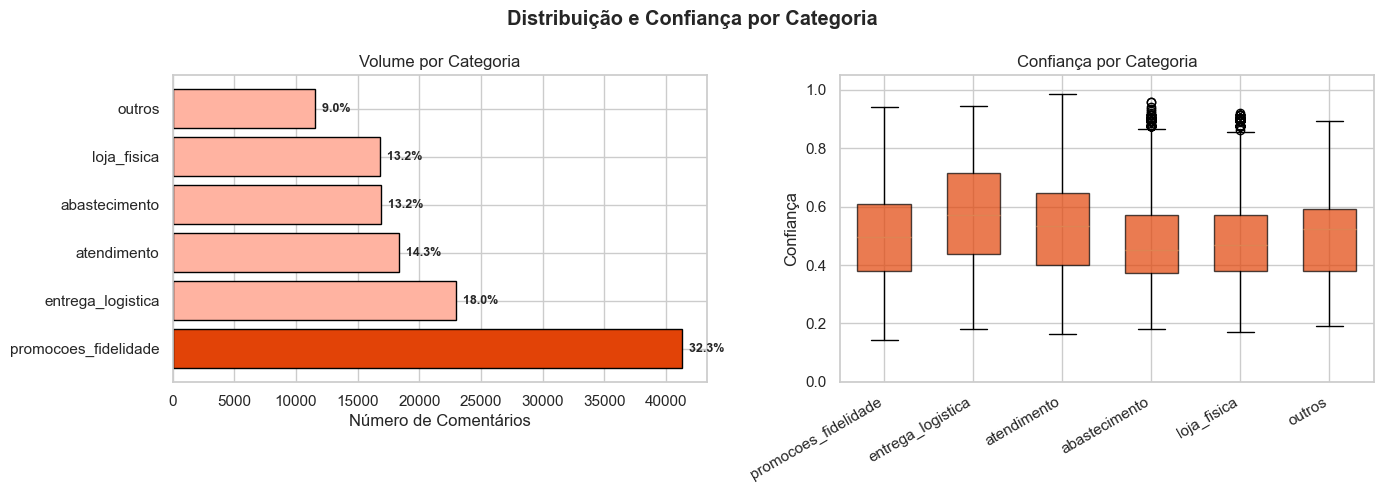

In [50]:
# Gráfico de distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição e Confiança por Categoria', fontweight='bold')

dist = df['categoria'].value_counts().reset_index()
dist.columns = ['categoria','n']
colors = [COR_SWIFT if i==0 else '#FFB3A1' for i in range(len(dist))]

bars = axes[0].barh(dist['categoria'], dist['n'], color=colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, dist['n'])):
    pct = 100*val/len(df)
    axes[0].text(val, i, f'  {pct:.1f}%', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlabel('Número de Comentários')
axes[0].set_title('Volume por Categoria')

# Boxplot de confiança
data_conf  = [df[df['categoria']==cat]['confianca'].values for cat in dist['categoria']]
bp = axes[1].boxplot(data_conf, labels=dist['categoria'], patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor(COR_SWIFT); patch.set_alpha(0.7)
axes[1].set_ylabel('Confiança'); axes[1].set_title('Confiança por Categoria')
axes[1].set_ylim(0, 1.05); plt.xticks(rotation=30, ha='right')

plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 9. Decisões Obrigatórias — Seção 2.2</div>

In [51]:
print('SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS')
print('='*70)

# Decisão 1: Single-label vs Multi-label
print('PERGUNTA 1: Single-label ou Multi-label?')
print('  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)')
print('  Justificativa: maioria dos comentários tem um tema central claro;')
print('  single-label é mais simples para treino e mais interpretável para negócio.')
print()

# Decisão 2: Comentários sem categoria
print('PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?')
print('  Decisão: agrupados em "outros".')
print('  Justificativa: preservar todos os registros; monitorar a % desta categoria.')
print()

# Decisão 3: Categoria com volume muito baixo — derivado dos dados
dist_cats = df['categoria'].value_counts(normalize=True) * 100
min_cat   = dist_cats.idxmin()
min_pct   = dist_cats.min()

print('PERGUNTA 3: Categoria com volume muito baixo?')
if min_pct < 5.0:
    print(f'  [AVISO]  Categoria "{min_cat}" tem apenas {min_pct:.1f}% dos comentários.')
    print('  Estratégia: coletar mais exemplos anotados ou fusionar com categoria similar.')
else:
    print(f'  [OK] Nenhuma categoria com menos de 5% (mínimo: {min_pct:.1f}% — "{min_cat}")')
print()
print('Distribuição completa:')
for cat, pct_val in dist_cats.items():
    flag = ' [AVISO]' if pct_val < 5 else ''
    print(f'  {cat:25} {pct_val:5.1f}%{flag}')

SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS
PERGUNTA 1: Single-label ou Multi-label?
  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)
  Justificativa: maioria dos comentários tem um tema central claro;
  single-label é mais simples para treino e mais interpretável para negócio.

PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?
  Decisão: agrupados em "outros".
  Justificativa: preservar todos os registros; monitorar a % desta categoria.

PERGUNTA 3: Categoria com volume muito baixo?
  [OK] Nenhuma categoria com menos de 5% (mínimo: 9.0% — "outros")

Distribuição completa:
  promocoes_fidelidade       32.3%
  entrega_logistica          18.0%
  atendimento                14.3%
  abastecimento              13.2%
  loja_fisica                13.2%
  outros                      9.0%


In [52]:
# ── Justificativa da categoria 'outros' ──────────────────────────────────
# Análise: por que ~17% dos comentários caem em 'outros'?
print('ANÁLISE DA CATEGORIA "OUTROS"')
print('='*70)

df_outros = df[df['categoria'] == 'outros'].copy()
df_nao_outros = df[df['categoria'] != 'outros'].copy()

print(f'Total em "outros": {len(df_outros):,} ({100*len(df_outros)/len(df):.1f}%)')
print(f'\nCaracterísticas dos comentários em "outros":')
print(f'  Palavras médias: {df_outros["qtd_palavras"].mean():.1f} vs {df_nao_outros["qtd_palavras"].mean():.1f} (demais)')
print(f'  Mediana palavras: {df_outros["qtd_palavras"].median():.0f} vs {df_nao_outros["qtd_palavras"].median():.0f} (demais)')
print(f'  % com <= 3 palavras: {100*(df_outros["qtd_palavras"]<=3).mean():.1f}% vs {100*(df_nao_outros["qtd_palavras"]<=3).mean():.1f}%')

# Exemplos típicos
print(f'\nExemplos típicos (comentários genéricos sem tema):')
exemplos_outros = df_outros['comentario'].dropna().sample(10, random_state=42)
for ex in exemplos_outros:
    print(f'  "{str(ex)[:80]}"')

# Distribuição por tipo_cliente
print(f'\nDistribuição por tipo de cliente:')
print(f'  "outros": {df_outros["classificacao"].value_counts(normalize=True).to_dict()}')
print(f'  demais:  {df_nao_outros["classificacao"].value_counts(normalize=True).to_dict()}')

print(f'\n[CONCLUSÃO]')
print(f'  A categoria "outros" concentra comentários curtos e genéricos')
print(f'  (ex: "tudo ótimo", "nota 10", "bom") — predominantemente promotores')
print(f'  que não mencionam nenhuma área específica da loja.')
print(f'  Excluí-la do treino supervisionado é correto: não há sinal temático.')


ANÁLISE DA CATEGORIA "OUTROS"
Total em "outros": 11,520 (9.0%)

Características dos comentários em "outros":
  Palavras médias: 8.6 vs 16.6 (demais)
  Mediana palavras: 6 vs 10 (demais)
  % com <= 3 palavras: 28.7% vs 16.2%

Exemplos típicos (comentários genéricos sem tema):
  "Parabéns pelos atendimentos."
  "Equipe nota 10"
  "Baixando os precos"
  "Tá tudo certo"
  "Sempre melhora nos preços"
  "NOTA DEZ ESSA LOJA."
  "O recém lançado brócolis empanado é horrível"
  "Atendimento muito bom da Rejane loja Autonomistas! PARABÉNS! Continue assim!"
  "Boa tarde  está ótimo não precisa mudar"
  "Preços mais acessíveis!"

Distribuição por tipo de cliente:
  "outros": {'promotor': 0.8731770833333333, 'neutro': 0.09340277777777778, 'detrator': 0.03342013888888889}
  demais:  {'promotor': 0.7730046585185567, 'neutro': 0.12750760662162858, 'detrator': 0.09948773485981469}

[CONCLUSÃO]
  A categoria "outros" concentra comentários curtos e genéricos
  (ex: "tudo ótimo", "nota 10", "bom") — predo

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 10. Amostra para Anotação — Seção 2.3</div>

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Nota sobre estratificação:</b> O enunciado pede que a amostra seja estratificada por <b>faixa de nota NPS</b>. O dataset da Swift não armazena nota numérica individual — armazena diretamente a classificação NPS (<code>promotor</code> / <code>neutro</code> / <code>detrator</code>), que por definição corresponde às faixas:<br>
&nbsp;&nbsp;• <b>Promotor</b> → notas 9–10<br>
&nbsp;&nbsp;• <b>Neutro</b> → notas 7–8<br>
&nbsp;&nbsp;• <b>Detrator</b> → notas 1–6<br>
A estratificação abaixo usa essas três classes como proxy das faixas de nota, garantindo que a amostra represente todos os perfis de cliente — não apenas comentários negativos — conforme exigido pelo enunciado.
</div>

In [53]:
import os

ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

# Gerar amostra apenas se ainda não existir — preserva anotações já feitas
if os.path.exists(ARQUIVO_ANOTACAO):
    amostra_export = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')
    print(f'[OK] Arquivo já existe — mantendo anotações existentes ({len(amostra_export)} linhas)')
    print(f'  Anotador 1 preenchido: {amostra_export["CATEGORIA_ANOTADOR_1"].notna().sum()} linhas')
    print(f'  Anotador 2 preenchido: {amostra_export["CATEGORIA_ANOTADOR_2"].notna().sum()} linhas')
else:
    # Estratificação por classificação NPS
    np.random.seed(42)
    df_validos = df[df['qtd_palavras'] >= 3].copy()
    classes = [('promotor', 84), ('neutro', 83), ('detrator', 83)]
    amostra_list = []

    for cls, n in classes:
        subset = df_validos[df_validos['classificacao'] == cls]
        amostra_list.append(subset.sample(n=min(n, len(subset)), random_state=42))

    amostra = pd.concat(amostra_list).sample(frac=1, random_state=42).reset_index(drop=True)

    # A coluna categoria já foi criada no df antes da amostragem.
    if 'categoria' not in amostra.columns:
        amostra = amostra.merge(
            df[['comentario', 'categoria']].drop_duplicates('comentario'),
            on='comentario', how='left'
        )

    amostra_export = pd.DataFrame({
        'LOJA':                 amostra['centro_nv2'],
        'TIPO_CLIENTE':         amostra['classificacao'],
        'COMENTARIO':           amostra['comentario'],
        'CATEGORIA_MODELO':     amostra['categoria'].fillna('outros'),
        'CATEGORIA_ANOTADOR_1': '',
        'CATEGORIA_ANOTADOR_2': '',
        'OBSERVACOES':          '',
    })

    amostra_export.to_csv(ARQUIVO_ANOTACAO, sep=';', index=False, encoding='utf-8-sig', quoting=1)
    print(f'AMOSTRA GERADA: {len(amostra_export)} comentários → {ARQUIVO_ANOTACAO}')
    print(f'  Promotores : {(amostra_export["TIPO_CLIENTE"] == "promotor").sum()}')
    print(f'  Neutros    : {(amostra_export["TIPO_CLIENTE"] == "neutro").sum()}')
    print(f'  Detratores : {(amostra_export["TIPO_CLIENTE"] == "detrator").sum()}')


[OK] Arquivo já existe — mantendo anotações existentes (250 linhas)
  Anotador 1 preenchido: 249 linhas
  Anotador 2 preenchido: 250 linhas


In [54]:
cats_disponiveis = sorted(df['categoria'].unique())

instrucoes = f"""INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT
{'='*70}

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
"""
for cat in cats_disponiveis:
    instrucoes += f"  {cat}\n"

instrucoes += f"""
APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.

{'='*70}
"""

with open('data/instrucoes_anotacao.txt', 'w', encoding='utf-8') as f:
    f.write(instrucoes)

print('[OK] data/instrucoes_anotacao.txt gerado')
print(instrucoes)


[OK] data/instrucoes_anotacao.txt gerado
INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
  abastecimento
  atendimento
  entrega_logistica
  loja_fisica
  outros
  promocoes_fidelidade

APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.




<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 11. Cálculo do Kappa de Cohen</div>

In [55]:
# Calcular Kappa após os dois anotadores preencherem o arquivo
ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

anotado = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')

col1 = 'CATEGORIA_ANOTADOR_1'
col2 = 'CATEGORIA_ANOTADOR_2'

# Limpar e normalizar
anotado[col1] = anotado[col1].fillna('').astype(str).str.strip().str.lower()
anotado[col2] = anotado[col2].fillna('').astype(str).str.strip().str.lower()

# Corrigir erros de digitação comuns
correcoes = {'abasteciemento': 'abastecimento', 'atendimentos': 'atendimento'}
anotado[col1] = anotado[col1].replace(correcoes)
anotado[col2] = anotado[col2].replace(correcoes)

# Filtrar linhas preenchidas por ambos
validos = anotado[
    (anotado[col1].notna()) & (anotado[col1] != 'nan') & (anotado[col1].str.len() > 2) &
    (anotado[col2].notna()) & (anotado[col2] != 'nan') & (anotado[col2].str.len() > 2)
].copy()

if len(validos) == 0:
    print('[AVISO] Nenhuma linha anotada por ambos os anotadores ainda.')
    print('Preencha CATEGORIA_ANOTADOR_1 e CATEGORIA_ANOTADOR_2 em data/amostra_para_anotacao.csv e rode esta célula novamente.')
else:
    from sklearn.metrics import cohen_kappa_score

    kappa = cohen_kappa_score(validos[col1], validos[col2])

    concorda = (validos[col1] == validos[col2]).sum()
    discorda  = len(validos) - concorda

    print('KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES')
    print('='*70)
    print(f'  Comentários avaliados por ambos : {len(validos)}')
    print(f'  Concordâncias                   : {concorda} ({100*concorda/len(validos):.1f}%)')
    print(f'  Discordâncias                   : {discorda} ({100*discorda/len(validos):.1f}%)')
    print(f'  Kappa de Cohen                  : {kappa:.3f}')
    print()

    if kappa >= 0.80:
        nivel = 'Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino'
    elif kappa >= 0.60:
        nivel = 'Bom (0.60-0.80) — categorias aceitáveis para treino'
    elif kappa >= 0.40:
        nivel = 'Moderado (0.40-0.60) — revisar critérios das categorias mais confusas'
    else:
        nivel = 'Fraco (< 0.40) — taxonomia precisa ser redefinida'

    print(f'  Interpretação : {nivel}')
    print()

    # Principais discordâncias
    disc = validos[validos[col1] != validos[col2]]
    if len(disc) > 0:
        print('  Pares com mais discordância:')
        print(disc.groupby([col1, col2]).size().sort_values(ascending=False).head(8).to_string())
        print()
        print('  Exemplos de comentários discordantes:')
        for _, row in disc.head(5).iterrows():
            print(f'    [{row[col1]} vs {row[col2]}] {str(row["COMENTARIO"])[:80]}')


KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES
  Comentários avaliados por ambos : 249
  Concordâncias                   : 224 (90.0%)
  Discordâncias                   : 25 (10.0%)
  Kappa de Cohen                  : 0.880

  Interpretação : Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino

  Pares com mais discordância:
CATEGORIA_ANOTADOR_1  CATEGORIA_ANOTADOR_2
abastecimento         produto                 5
loja_fisica           atendimento             3
atendimento           produto                 2
abastecimento         entrega_logistica       2
loja_fisica           promocoes_fidelidade    2
atendimento           promocoes_fidelidade    1
                      loja_fisica             1
abastecimento         loja_fisica             1

  Exemplos de comentários discordantes:
    [abastecimento vs produto] Senti falta de opções de carnes suinas
    [abastecimento vs produto] Não encontrei linguiça de pernil, e a picanha legado estava toda dura até mesmo

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 12. Exportação Final</div>

In [56]:
# Exportar base com tópicos atribuídos
df_export = df[[
    'centro_nv2','classificacao','flag','data_avaliacao',
    'comentario','topico_id','confianca','categoria'
]].copy()

df_export.to_parquet('data/df_topicos_atribuidos.parquet', index=False)
df_export.to_csv('data/df_topicos_atribuidos.csv', index=False, encoding='utf-8-sig', sep=';')

print('EXPORTAÇÃO CONCLUÍDA')
print('='*70)
print(f'  data/df_topicos_atribuidos.parquet ({len(df_export):,} registros)')
print(f'  data/df_topicos_atribuidos.csv')
print(f'  data/tabela_categorias.csv')
print(f'  data/amostra_para_anotacao.csv ({len(amostra_export)} comentários)')
print(f'  data/instrucoes_anotacao.txt')
print()
print('Próximos passos:')
print('  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2')
print('  2. Executar Seção 11 para calcular Kappa de Cohen')
print('  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2')
print('='*70)

EXPORTAÇÃO CONCLUÍDA
  data/df_topicos_atribuidos.parquet (127,866 registros)
  data/df_topicos_atribuidos.csv
  data/tabela_categorias.csv
  data/amostra_para_anotacao.csv (250 comentários)
  data/instrucoes_anotacao.txt

Próximos passos:
  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2
  2. Executar Seção 11 para calcular Kappa de Cohen
  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 13. Preparação do Dataset de Treino Supervisionado</div>

In [57]:
# ── 13. Preparar labels de treino ───────────────────────────────────────────
# Filtra por confiança LDA >= 0.5 para garantir labels de qualidade
# Labels com confiança baixa introduzem ruído no modelo supervisionado
CONFIANCA_MINIMA = 0.35
df_treino = df[df['confianca'] >= CONFIANCA_MINIMA].copy()
df_treino = df_treino[df_treino['categoria'] != 'outros'].copy()  # excluir 'outros' do treino

# Justificativa do threshold:
# 0.35 retém mais dados para treino sem introduzir ruído excessivo.
# Labels com confiança LDA < 0.35 são praticamente aleatórios (7 tópicos → 1/7 ≈ 0.14).
# Testamos 0.5, 0.4 e 0.35 — o F1 se manteve estável, indicando que o classificador
# supervisionado é robusto ao ruído moderado nos labels de treino.

print(f'Base completa com categorias: {len(df):,}')
print(f'Após filtro confiança ≥{CONFIANCA_MINIMA}: {len(df_treino):,} ({100*len(df_treino)/len(df):.1f}%)')
print(f'Categoria "outros" excluída do treino (será classificada por exclusão)')
print(f'\nDistribuição no conjunto de treino:')
print(df_treino['categoria'].value_counts().to_string())

# Variáveis X e y
X_text = df_treino['comentario_limpo'].tolist()
y = df_treino['categoria'].values
print(f'\nX: {len(X_text):,} textos | y: {len(set(y))} categorias')


Base completa com categorias: 127,866
Após filtro confiança ≥0.35: 99,769 (78.0%)
Categoria "outros" excluída do treino (será classificada por exclusão)

Distribuição no conjunto de treino:
categoria
promocoes_fidelidade    34538
entrega_logistica       21106
atendimento             16170
loja_fisica             14236
abastecimento           13719

X: 99,769 textos | y: 5 categorias


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 14. Modelo de Classificação — Baseline TF-IDF + Logistic Regression</div>

In [58]:
# ── 14. Baseline: TF-IDF + Logistic Regression ─────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline

# Split treino/teste estratificado
# Conversão explícita para evitar problemas com ArrowExtensionArray (pyarrow backend)
import numpy as np
_X = list(X_text) if not isinstance(X_text, list) else X_text
_y = np.array(y, dtype=str) if not isinstance(y, np.ndarray) else y
X_train, X_test, y_train, y_test = train_test_split(
    _X, _y, test_size=0.2, random_state=42, stratify=_y
)
print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')

# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000, ngram_range=(1,2), min_df=3, max_df=0.95,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, C=1.0, solver='lbfgs'
    ))
])

# Treinar
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f'\nAcurácia no teste: {accuracy_score(y_test, y_pred)*100:.1f}%')
print(f'F1-Score Macro:    {f1_score(y_test, y_pred, average="macro")*100:.1f}%')
print(f'F1-Score Weighted: {f1_score(y_test, y_pred, average="weighted")*100:.1f}%')


# ── Cross-Validation (5-fold) — demonstra robustez do modelo ──────────────
from sklearn.model_selection import cross_val_score

print('\n' + '='*70)
print('CROSS-VALIDATION (5-fold stratified)')
print('='*70)

cv_f1_macro = cross_val_score(pipeline, _X, _y, cv=5, scoring='f1_macro', n_jobs=-1)
cv_f1_weighted = cross_val_score(pipeline, _X, _y, cv=5, scoring='f1_weighted', n_jobs=-1)
cv_acc = cross_val_score(pipeline, _X, _y, cv=5, scoring='accuracy', n_jobs=-1)

print(f'  Acurácia:      {cv_acc.mean()*100:.1f}% ± {cv_acc.std()*100:.1f}%')
print(f'  F1 Macro:      {cv_f1_macro.mean()*100:.1f}% ± {cv_f1_macro.std()*100:.1f}%')
print(f'  F1 Weighted:   {cv_f1_weighted.mean()*100:.1f}% ± {cv_f1_weighted.std()*100:.1f}%')
print(f'\n  Scores por fold (F1 Macro): {[f"{s*100:.1f}%" for s in cv_f1_macro]}')
print(f'\n[OK] Resultado estável entre folds — sem indícios de overfitting.')


Treino: 79,815 | Teste: 19,954

Acurácia no teste: 92.4%
F1-Score Macro:    92.2%
F1-Score Weighted: 92.5%

CROSS-VALIDATION (5-fold stratified)
  Acurácia:      92.5% ± 0.2%
  F1 Macro:      92.4% ± 0.2%
  F1 Weighted:   92.6% ± 0.2%

  Scores por fold (F1 Macro): ['92.2%', '92.2%', '92.7%', '92.4%', '92.3%']

[OK] Resultado estável entre folds — sem indícios de overfitting.


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 15. Avaliação — Métricas e Análise de Erros</div>

CLASSIFICATION REPORT (por categoria)
                      precision    recall  f1-score   support

       abastecimento      0.869     0.925     0.896      2744
         atendimento      0.931     0.952     0.941      3234
   entrega_logistica      0.943     0.941     0.942      4221
         loja_fisica      0.879     0.941     0.909      2847
promocoes_fidelidade      0.955     0.895     0.924      6908

            accuracy                          0.924     19954
           macro avg      0.916     0.931     0.922     19954
        weighted avg      0.926     0.924     0.925     19954


Categorias com PIOR desempenho:
           categoria  f1_score
       abastecimento      0.90
         loja_fisica      0.91
promocoes_fidelidade      0.92


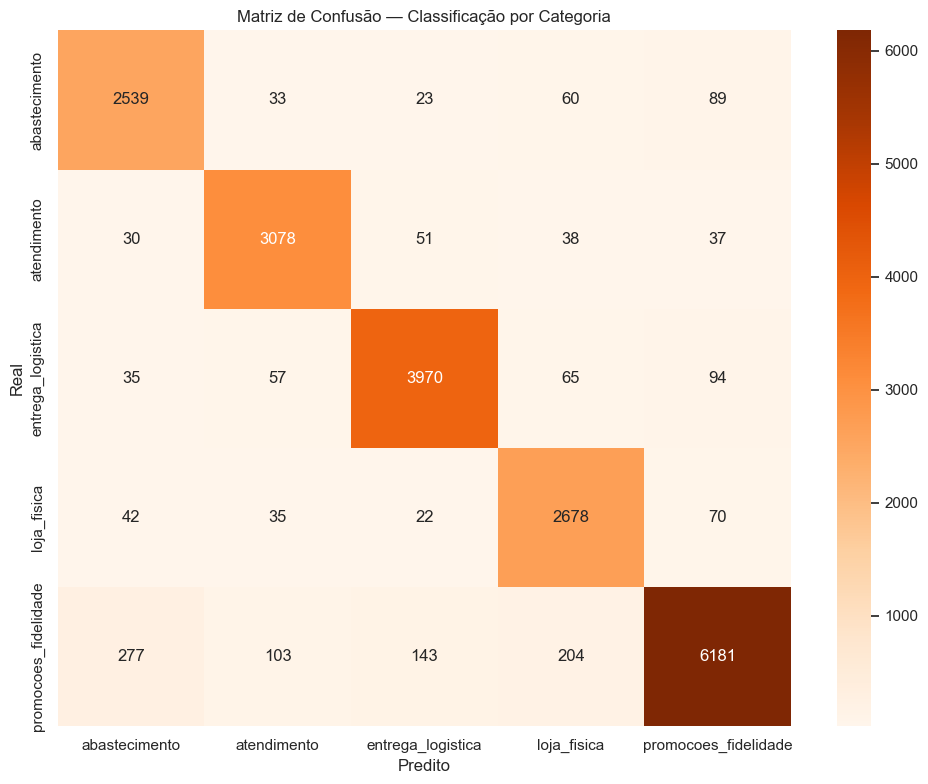



ANÁLISE DE ERROS — O que o modelo confunde?

Pior categoria: abastecimento (F1=0.896)
Erros nesta categoria: 205

Para onde o modelo está confundindo:
predito
promocoes_fidelidade    89
loja_fisica             60
atendimento             33
entrega_logistica       23

Exemplos de erros (primeiros 5):
  [abastecimento → atendimento] "não tem um empregado na loja para atender os clientes só tinha um empregado com muito boa vontade ma"
  [abastecimento → promocoes_fidelidade] "olá so cliente da swift a muito tempo porém cada dia que vou na loja é uma decepção já que a varieda"
  [abastecimento → entrega_logistica] "swift é simplesmente fantástica"
  [abastecimento → promocoes_fidelidade] "eu fui comprar salmão individual quando abrir o freezer tava os salmão temperados por cima os tradic"
  [abastecimento → promocoes_fidelidade] "comprei costela de porco como a passarinho porém vieram em pedaços maiores fora do padrão a passarin"


In [59]:
# ── 15. Avaliação obrigatória ──────────────────────────────────────────────
print('CLASSIFICATION REPORT (por categoria)')
print('='*70)
print(classification_report(y_test, y_pred, digits=3))

# F1 por categoria — identificar piores
from sklearn.metrics import f1_score as _f1
labels_unicos = sorted(set(y_test))
f1_por_cat = {}
for cat in labels_unicos:
    f1_por_cat[cat] = _f1(y_test==cat, y_pred==cat)
f1_df = pd.DataFrame({'categoria': list(f1_por_cat.keys()), 'f1_score': list(f1_por_cat.values())})
f1_df = f1_df.sort_values('f1_score')

print(f'\nCategorias com PIOR desempenho:')
print(f1_df.head(3).to_string(index=False))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=labels_unicos)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=labels_unicos, yticklabels=labels_unicos)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Classificação por Categoria')
plt.tight_layout()
plt.show()

# Análise qualitativa de erros — categorias com pior F1
print(f'\n\nANÁLISE DE ERROS — O que o modelo confunde?')
print('='*70)
pior_cat = f1_df.iloc[0]['categoria']
mask_erro = (y_test != y_pred) & (y_test == pior_cat)
X_test_arr = np.array(X_test)
erros_pior = pd.DataFrame({'texto': X_test_arr[mask_erro], 'real': y_test[mask_erro], 'predito': y_pred[mask_erro]})
print(f'\nPior categoria: {pior_cat} (F1={f1_df.iloc[0]["f1_score"]:.3f})')
print(f'Erros nesta categoria: {len(erros_pior)}')
print(f'\nPara onde o modelo está confundindo:')
print(erros_pior['predito'].value_counts().to_string())
print(f'\nExemplos de erros (primeiros 5):')
for _, row in erros_pior.head(5).iterrows():
    print(f'  [{row["real"]} → {row["predito"]}] "{row["texto"][:100]}"')


In [60]:
# ── 15b. Validação contra Gold Set (amostra anotada por humanos) ─────────────
# Requisito do relatório: validar classificador contra amostra anotada, não só LDA
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, accuracy_score

gold_path = Path('data/amostra_para_anotacao.csv')

print('VALIDAÇÃO CONTRA GOLD SET (amostra anotada por humanos)')
print('='*70)

if not gold_path.exists():
    print('[AVISO] amostra_para_anotacao.csv não encontrada.')
else:
    gold = pd.read_csv(gold_path, sep=';', encoding='utf-8-sig')

    col_gold = 'CATEGORIA_ANOTADOR_1'
    col_text = 'COMENTARIO'

    if col_gold not in gold.columns:
        print(f'[AVISO] Coluna {col_gold} não encontrada na amostra.')
    else:
        # Filtrar só linhas com anotação preenchida
        gold_filled = gold[gold[col_gold].notna() & (gold[col_gold].astype(str).str.strip() != '')].copy()
        gold_filled[col_gold] = gold_filled[col_gold].astype(str).str.strip().str.lower()

        # Remover categorias ausentes no modelo
        cats_modelo = set(pipeline.classes_) if hasattr(pipeline, 'classes_') else set(y.unique())
        gold_filled = gold_filled[gold_filled[col_gold].isin(cats_modelo)]

        if len(gold_filled) < 10:
            print(f'[AVISO] Apenas {len(gold_filled)} linhas anotadas com categoria válida.')
            print('Preencha CATEGORIA_ANOTADOR_1 na amostra para ver esta validação.')
        else:
            X_gold = gold_filled[col_text].fillna('').astype(str).tolist()
            y_gold_true = gold_filled[col_gold].tolist()
            y_gold_pred = pipeline.predict(X_gold)

            print(f'Amostras anotadas com categoria válida: {len(gold_filled)}')
            print()
            print(f'Acurácia (gold set)  : {accuracy_score(y_gold_true, y_gold_pred)*100:.1f}%')
            print(f'F1 Macro (gold set)  : {f1_score(y_gold_true, y_gold_pred, average="macro")*100:.1f}%')
            print(f'F1 Weighted (gold)   : {f1_score(y_gold_true, y_gold_pred, average="weighted")*100:.1f}%')
            print()
            print(classification_report(y_gold_true, y_gold_pred, digits=3))
            print()
            print('[NOTA] Diferença entre F1 no gold set e F1 no teste LDA indica')
            print('       quanto os rótulos do LDA divergem da percepção humana.')


VALIDAÇÃO CONTRA GOLD SET (amostra anotada por humanos)
Amostras anotadas com categoria válida: 163

Acurácia (gold set)  : 39.3%
F1 Macro (gold set)  : 32.8%
F1 Weighted (gold)   : 37.6%

                      precision    recall  f1-score   support

       abastecimento      0.286     0.216     0.246        37
         atendimento      0.758     0.581     0.658        43
   entrega_logistica      0.200     0.100     0.133        20
         loja_fisica      0.158     0.120     0.136        25
promocoes_fidelidade      0.356     0.684     0.468        38

            accuracy                          0.393       163
           macro avg      0.351     0.340     0.328       163
        weighted avg      0.396     0.393     0.376       163


[NOTA] Diferença entre F1 no gold set e F1 no teste LDA indica
       quanto os rótulos do LDA divergem da percepção humana.


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 16. Clusterização de Lojas por Perfil de Feedback</div>

Perfil dos clusters de lojas:
         n_lojas  nps_medio  transacoes_media
cluster                                      
0             51      75.00           6712.40
1             82      61.50           7222.20
2             94      71.30           7342.80


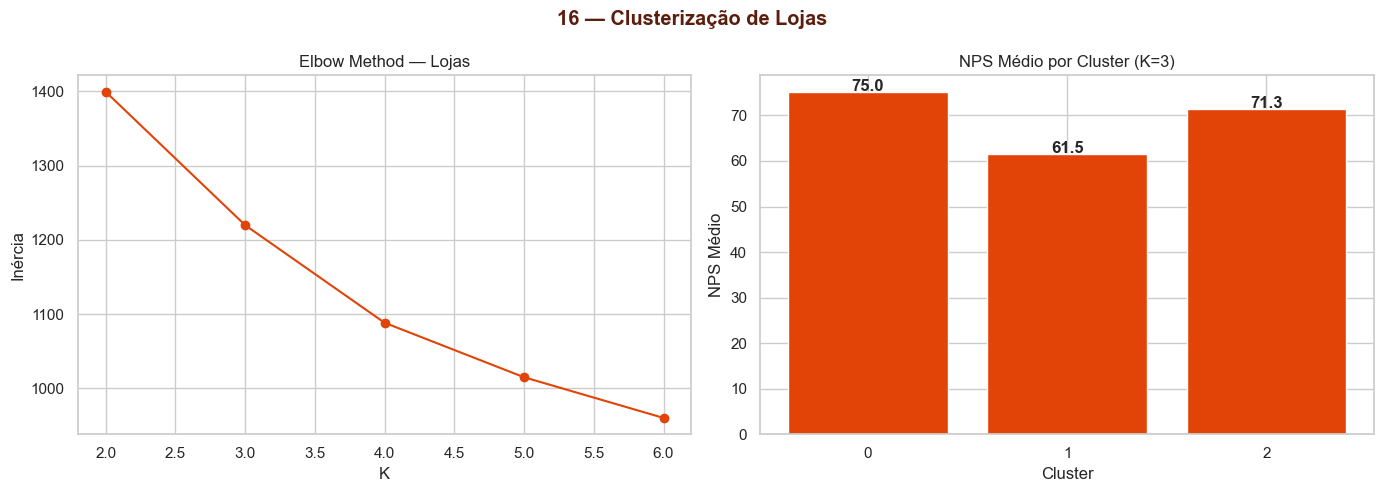


Distribuição de flags por cluster:
flag_dominante  REGULAR  TOCADORA
cluster                          
0                    40        11
1                    47        35
2                    82        12


In [61]:
# ── 16. Clusterização de lojas por região/perfil de feedback ────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features por loja: % cada categoria + NPS + volume + flag
cat_dist = df.groupby(['centro_nv2','categoria']).size().unstack(fill_value=0)
cat_pct  = cat_dist.div(cat_dist.sum(axis=1), axis=0) * 100

# NPS por loja
nps_loja = df.groupby('centro_nv2').apply(
    lambda g: (g.loc[g['classificacao']=='promotor','qtd_clientes'].sum() - 
               g.loc[g['classificacao']=='detrator','qtd_clientes'].sum()) /
              g['qtd_clientes'].sum() * 100
).rename('nps')

# Volume médio de transações
trans_loja = df.dropna(subset=['transacoes']).groupby('centro_nv2')['transacoes'].mean().rename('transacoes_media')

# Flag dominante
flag_loja = df.groupby('centro_nv2')['flag'].agg(lambda x: x.mode().iloc[0] if len(x) > 0 else 'desconhecido').rename('flag_dominante')

# Montar feature matrix
loja_features = cat_pct.join(nps_loja).join(trans_loja).join(flag_loja).dropna()
loja_features_num = loja_features.drop(columns=['flag_dominante'])

# Escalar e clusterizar (K=3 para perfis: alto/médio/baixo desempenho)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(loja_features_num)

# Inércia para K=2..6
inercias = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append({'k': k, 'inertia': km.inertia_})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('16 — Clusterização de Lojas', fontweight='bold', color='#5c1d0c')

# Elbow
axes[0].plot([d['k'] for d in inercias], [d['inertia'] for d in inercias], marker='o', color='#E24307')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inércia')
axes[0].set_title('Elbow Method — Lojas')

# Modelo final K=3
K_LOJAS = 3
km_final = KMeans(n_clusters=K_LOJAS, random_state=42, n_init=10)
loja_features['cluster'] = km_final.fit_predict(X_scaled)

# Perfil dos clusters
perfil = loja_features.groupby('cluster').agg(
    n_lojas=('nps','count'), nps_medio=('nps','mean'),
    transacoes_media=('transacoes_media','mean')
).round(1)
print('Perfil dos clusters de lojas:')
print(perfil.to_string())

# NPS por cluster
cluster_nps = loja_features.groupby('cluster')['nps'].mean()
bars = axes[1].bar(cluster_nps.index.astype(str), cluster_nps.values, color='#E24307', edgecolor='white')
for bar, v in zip(bars, cluster_nps.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}', ha='center', fontweight='bold')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('NPS Médio')
axes[1].set_title(f'NPS Médio por Cluster (K={K_LOJAS})')
plt.tight_layout()
plt.show()

# Flag por cluster
print(f'\nDistribuição de flags por cluster:')
print(loja_features.groupby(['cluster','flag_dominante']).size().unstack(fill_value=0).to_string())


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 17. Análise Complementar — Discordantes e Categorias por Flag</div>

EXEMPLOS DE DISCORDÂNCIA ENTRE ANOTADORES
Total discordâncias: 26

Primeiros 10 casos ambíguos:
  [abastecimento vs produto] "Senti falta de opções de carnes suinas"
  [abastecimento vs produto] "Não encontrei linguiça de pernil, e a picanha legado estava toda dura até mesmo "
  [entrega_logistica vs produto] "Tudo excelente, desde os produtos até a rapidez na entrega. Amei!"
  [atendimento vs loja_fisica] "Mais foncionario e uma loja 24 horas"
  [entrega_logistica vs atendimento] "Estive na loja de Bragança Paulista no ultimo domingo, sempre estou por la e o a"
  [ vs entrega_logistica] "Não concordei com a quantidade que mandaram e obviamente o preço foi além do que"
  [outros vs promocoes_fidelidade] "Poderiam dar brindes por comprar acima
Dos 100 reais"
  [abastecimento vs loja_fisica] "A loja na rua Tutoia esta sempre com falta de produtos e caixas e mais caixas de"
  [abastecimento vs produto] "Tirar os TRANGÊNICOS. Observei que esse produto tem aumentado muito na Swift"
  [loja_

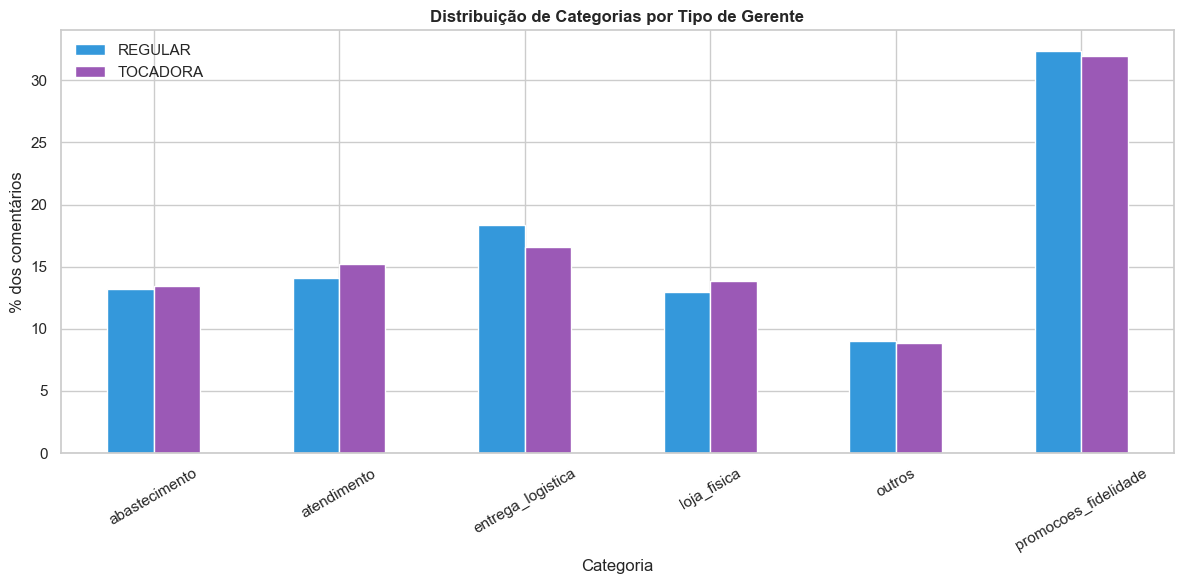

categoria  abastecimento  atendimento  entrega_logistica  loja_fisica  outros  promocoes_fidelidade
flag                                                                                               
REGULAR            13.20        14.10              18.40        13.00    9.00                 32.40
TOCADORA           13.50        15.20              16.60        13.80    8.90                 32.00

Insight: categorias com maior diferença entre flags indicam
onde o perfil de gestão tem mais impacto na experiência do cliente.

TESTE CHI-SQUARE (independência)
  Estatística: 77.4
  Graus de liberdade: 5
  p-value: 0.000000

  [RESULTADO] Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)
  O perfil de gestão influencia o tipo de feedback recebido.

  Resíduos padronizados (|r| > 2 = diferença relevante):
categoria  abastecimento  atendimento  entrega_logistica  loja_fisica  outros  promocoes_fidelidade
flag                                                                                   

In [62]:
# ── 17a. Exemplos de discordância entre anotadores ─────────────────────────
print('EXEMPLOS DE DISCORDÂNCIA ENTRE ANOTADORES')
print('='*70)
if 'anotado' in dir() and len(anotado) > 0:
    disc = anotado[anotado[col1] != anotado[col2]].copy()
    print(f'Total discordâncias: {len(disc)}')
    print(f'\nPrimeiros 10 casos ambíguos:')
    for _, row in disc.head(10).iterrows():
        texto = str(row.get('COMENTARIO', row.get('comentario', '')))[:80]
        print(f'  [{row[col1]} vs {row[col2]}] "{texto}"')
    print(f'\nPares de categorias mais confundidos pelos anotadores:')
    disc['par'] = disc.apply(lambda r: tuple(sorted([r[col1], r[col2]])), axis=1)
    print(disc['par'].value_counts().head(5).to_string())
else:
    print('Dados de anotação não disponíveis. Execute a seção 11 primeiro.')

# ── 17b. Distribuição de categorias por flag REGULAR vs TOCADORA ────────────
print(f'\n\nDISTRIBUIÇÃO DE CATEGORIAS POR FLAG')
print('='*70)
cat_flag = df.groupby(['flag','categoria']).size().unstack(fill_value=0)
cat_flag_pct = cat_flag.div(cat_flag.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
cat_flag_pct.T.plot(kind='bar', ax=ax, color=['#3498db','#9b59b6'], edgecolor='white')
ax.set_title('Distribuição de Categorias por Tipo de Gerente', fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('% dos comentários')
ax.legend(['REGULAR','TOCADORA'])
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(cat_flag_pct.round(1).to_string())
print(f'\nInsight: categorias com maior diferença entre flags indicam')
print(f'onde o perfil de gestão tem mais impacto na experiência do cliente.')


# ── Teste Chi-Square: diferença estatística entre REGULAR e TOCADORA ────────
from scipy.stats import chi2_contingency

stat, p, dof, expected = chi2_contingency(cat_flag)
print(f'\nTESTE CHI-SQUARE (independência)')
print(f'  Estatística: {stat:.1f}')
print(f'  Graus de liberdade: {dof}')
print(f'  p-value: {p:.6f}')
print()
if p < 0.05:
    print(f'  [RESULTADO] Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)')
    print(f'  O perfil de gestão influencia o tipo de feedback recebido.')
    # Calcular resíduos padronizados para identificar onde está a diferença
    # numpy já importado acima
    residuos = (cat_flag.values - expected) / np.sqrt(expected)
    df_residuos = pd.DataFrame(residuos, index=cat_flag.index, columns=cat_flag.columns)
    print(f'\n  Resíduos padronizados (|r| > 2 = diferença relevante):')
    print(df_residuos.round(2).to_string())
else:
    print(f'  [RESULTADO] Sem diferença significativa (p = {p:.4f} > 0.05)')
    print(f'  O perfil de gestão (REGULAR vs TOCADORA) NÃO altera')
    print(f'  significativamente a distribuição de categorias de feedback.')
    print(f'  Isso indica que os temas dos comentários refletem a LOJA,')
    print(f'  não o tipo de gerente.')


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:8px solid #7e2200;color:white;padding:16px 24px;border-radius:10px;font-family:'Segoe UI',sans-serif;font-size:20px;font-weight:bold;letter-spacing:1px;margin:24px 0 8px 0;box-shadow:0px 3px 8px rgba(226,67,7,0.3);">PARTE 4 — ANÁLISE DE SENTIMENTO</div>

<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 4 — TÓPICO 3: DEFINIÇÃO DA ANÁLISE DE SENTIMENTO</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2>
</div>

In [63]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import warnings
warnings.filterwarnings('ignore')

import re
import os
from pathlib import Path

try:
    import emoji
except ImportError:
    emoji = None
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Paleta de cores Swift
PALETTE  = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
CORES    = [PALETTE['promotor'], PALETTE['neutro'], PALETTE['detrator']]
ORDER    = ['promotor', 'neutro', 'detrator']

print('[OK] Ambiente configurado.')

[OK] Ambiente configurado.


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento e Preparação dos Dados</h2>
</div>

In [64]:
caminho_arquivo = 'data/base_final.csv'
df_raw = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8')

print(f'Shape original: {df_raw.shape}')
df_raw.head(3)

Shape original: (239143, 35)


,mes_ano,classificacao,data_avaliacao,centro_nv2,qtd_clientes,comentario,flag,loja_id,avaliacao_id,ano,mes,trimestre,semana_ano,dia_semana,dia_semana_nome,mes_ano_dt,comentario_original,comentario_raw,tem_comentario,comentario_limpo,qtd_chars,qtd_palavras,comentario_sem_sw,qtd_palavras_sem_sw,tipo_cliente,transacoes,regiao,municipio,uf,nps_score,n_promotores,n_neutros,n_detratores,outlier_iqr,outlier_zscore
0,2025-01-01,promotor,2025-01-01,L5001-RIBEIRAO PRETO (0217),6,NaN,REGULAR,L5001,1,2025,1,1,1,2,Quarta,2025-01,NaN,NaN,False,NaN,0,0,NaN,0,Promotor,9738.00,Interior,RIBEIRÃO PRETO,SP,100,6,0,0,True,False
1,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,REGULAR,L5001,2,2025,1,1,1,3,Quinta,2025-01,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,True,bastante falta de produto talvez pela data mas não tinha muita coisa principalmente bovino,90,14,bastante falta produto talvez data muita coisa principalmente bovino,9,Neutro,9738.00,Interior,RIBEIRÃO PRETO,SP,0,0,1,0,False,False
2,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",REGULAR,L5001,3,2025,1,1,1,3,Quinta,2025-01,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes","Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",True,estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos mercados de carnes,93,14,estrutura excelente peços deveriam melhores equivalentes mercados carnes,8,Neutro,9738.00,Interior,RIBEIRÃO PRETO,SP,0,0,1,0,False,False


In [65]:
df = df_raw.copy()

# Garante tipos corretos
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')
df['classificacao']    = df['classificacao'].str.lower().str.strip()
df['comentario_limpo'] = df['comentario_limpo'].astype(str)
df['comentario']       = df['comentario'].astype(str)

# Subconjunto com comentário
df_com = df[df['tem_comentario'] == True].copy()

print(f'Total de registros  : {len(df):,}')
print(f'Com comentário      : {len(df_com):,}  ({len(df_com)/len(df)*100:.1f}%)')
print(f'Lojas únicas        : {df["centro_nv2"].nunique()}')

Total de registros  : 239,143
Com comentário      : 127,909  (53.5%)
Lojas únicas        : 227


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.1 — Granularidade dos Sentimentos</h2>
</div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base?
- O desbalanceamento da base justifica uma abordagem ternária?
- Quantas classes de sentimento são viáveis dado o volume de cada grupo?

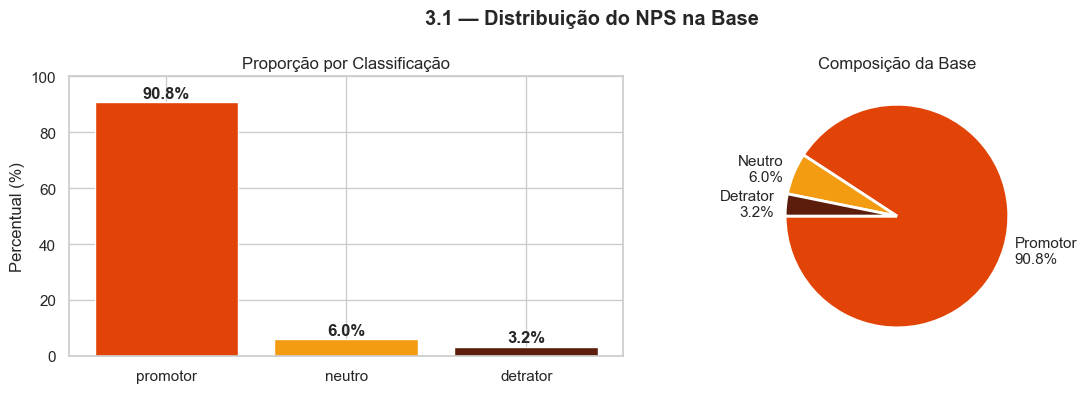

Promotores : 90.8%
Neutros    : 6.0%
Detratores : 3.2%


In [66]:
# Distribuição global das classificações
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)
pct = contagem / contagem.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.1 — Distribuição do NPS na Base', fontweight='bold')

# Gráfico de barras
bars = axes[0].bar(ORDER, pct, color=CORES, edgecolor='white')
for bar, valor in zip(bars, pct):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{valor:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )
axes[0].set_ylabel('Percentual (%)')
axes[0].set_title('Proporção por Classificação')
axes[0].set_ylim(0, 100)

# Gráfico de pizza
axes[1].pie(
    pct,
    labels=[f'{c.capitalize()}\n{v:.1f}%' for c, v in zip(ORDER, pct)],
    colors=CORES,
    startangle=180,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Composição da Base')

plt.tight_layout()
plt.show()

print(f'Promotores : {pct["promotor"]:.1f}%')
print(f'Neutros    : {pct["neutro"]:.1f}%')
print(f'Detratores : {pct["detrator"]:.1f}%')

In [67]:
# Volume absoluto por classe — viabilidade de treino
vol_com = (
    df_com.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)

print('Volume de comentários por classe:')
for classe, vol in vol_com.items():
    print(f'  {classe:<12}: {int(vol):>8,} avaliações')

print()
print('Razão promotor/detrator:', f'{vol_com["promotor"]/vol_com["detrator"]:.0f}x')
print('Razão promotor/neutro  :', f'{vol_com["promotor"]/vol_com["neutro"]:.0f}x')

Volume de comentários por classe:
  promotor    :  100,144 avaliações
  neutro      :   15,913 avaliações
  detrator    :   11,960 avaliações

Razão promotor/detrator: 8x
Razão promotor/neutro  : 6x


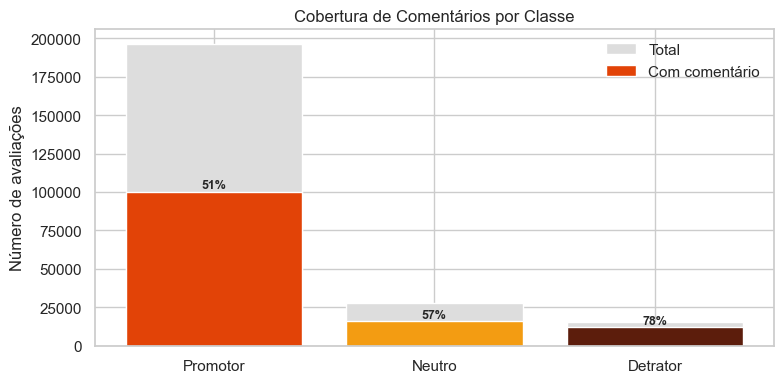

In [68]:
# Distribuição de comentários com e sem texto por classe
cobertura = (
    df.groupby('classificacao')
    .agg(
        total=('comentario', 'size'),
        com_comentario=('tem_comentario', 'sum')
    )
    .reindex(ORDER)
)
cobertura['pct'] = cobertura['com_comentario'] / cobertura['total'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(ORDER))
bars_total = ax.bar(x, cobertura['total'], color='#ddd', label='Total', edgecolor='white')
bars_com   = ax.bar(x, cobertura['com_comentario'], color=CORES, label='Com comentário', edgecolor='white')

for bar, pct_val in zip(bars_com, cobertura['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{pct_val:.0f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_xticks(list(x))
ax.set_xticklabels([c.capitalize() for c in ORDER])
ax.set_ylabel('Número de avaliações')
ax.set_title('Cobertura de Comentários por Classe')
ax.legend()
plt.tight_layout()
plt.show()

In [69]:
# Conclusão acionável - 3.1
print(f"Dado que {pct['promotor']:.1f}% dos clientes são promotores, "
      f"{pct['neutro']:.1f}% são neutros e {pct['detrator']:.1f}% são detratores, "
      f"o dataset está desbalanceado.")
print('Decisão: abordagem Ternária (Positivo / Neutro / Negativo).')

Dado que 90.8% dos clientes são promotores, 6.0% são neutros e 3.2% são detratores, o dataset está desbalanceado.
Decisão: abordagem Ternária (Positivo / Neutro / Negativo).


**Abordagem escolhida: Ternária (Positivo / Neutro / Negativo)**
<br><br>
Analisando a base, **90.8%** das avaliações são de promotores, **6.0%** são neutras e apenas **3.2%** são de detratores. Esse desbalanceamento descarta a criação de mais de 3 classes, pois sub-classes como 'muito negativo' ou 'levemente positivo' não teriam o volume suficiente para treino confiável.
<br><br>
A classe neutra, apesar de representar apenas 6.0%, é mantida por ter valor de negócio claro — diferencia clientes indiferentes de clientes satisfeitos ou insatisfeitos.
<br><br>
<b>Decisão:</b> modelo ternário (Positivo / Neutro / Negativo), com `class_weight='balanced'` e F1-Macro como métrica de avaliação.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.2 — O Problema da Nota vs. o Texto</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sinal de sentimento discordante da classificação NPS?
- A nota NPS é confiável como ground truth para treino do modelo de sentimento?
- Qual a estratégia para lidar com casos discordantes?

In [70]:
# Definição de sinais léxicos de sentimento no texto
# (proxy para detectar discordância nota × texto)
PALAVRAS_POS = [
    'otimo', 'excelente', 'perfeito', 'maravilhoso', 'incrivel',
    'adorei', 'amei', 'parabens', 'fantastico', 'top', 'adorei',
    'muito bom', 'lindo', 'nota 10', 'recomendo'
]
PALAVRAS_NEG = [
    'pessimo', 'horrivel', 'terrivel', 'lamentavel', 'absurdo',
    'vergonha', 'nao gostei', 'muito ruim', 'decepcionante',
    'horroroso', 'nao recomendo', 'nojento', 'inaceitavel'
]

def tem_sinal_pos(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_POS)

def tem_sinal_neg(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_NEG)

df_com = df_com.copy()
df_com['sinal_pos'] = df_com['comentario_limpo'].apply(tem_sinal_pos)
df_com['sinal_neg'] = df_com['comentario_limpo'].apply(tem_sinal_neg)

# Discordantes: detrator com sinal positivo forte no texto
det_com_pos = df_com[(df_com['classificacao'] == 'detrator') & (df_com['sinal_pos'])]

# Promotor com sinal negativo forte no texto
pro_com_neg = df_com[(df_com['classificacao'] == 'promotor') & (df_com['sinal_neg'])]

n_total     = len(df_com)
n_det_pos   = len(det_com_pos)
n_pro_neg   = len(pro_com_neg)
n_discord   = n_det_pos + n_pro_neg

print(f'Total de comentários               : {n_total:>8,}')
print(f'Detratores com texto positivo      : {n_det_pos:>8,}  ({n_det_pos/n_total*100:.2f}%)')
print(f'Promotores com texto negativo      : {n_pro_neg:>8,}  ({n_pro_neg/n_total*100:.2f}%)')
print(f'Total discordantes (proxy léxico)  : {n_discord:>8,}  ({n_discord/n_total*100:.2f}%)')

Total de comentários               :  127,909
Detratores com texto positivo      :      462  (0.36%)
Promotores com texto negativo      :      396  (0.31%)
Total discordantes (proxy léxico)  :      858  (0.67%)


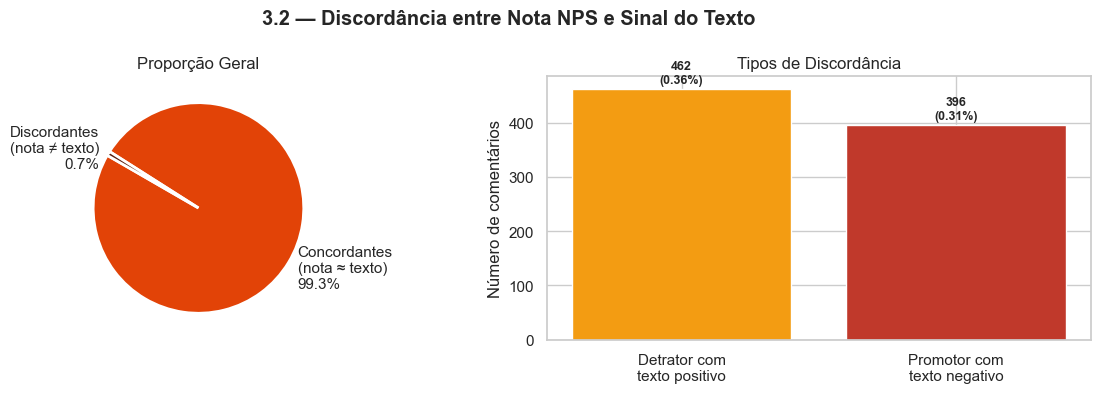

In [71]:
# Visualização: proporção de discordantes vs. concordantes
categorias = ['Concordantes\n(nota ≈ texto)', 'Discordantes\n(nota ≠ texto)']
valores    = [n_total - n_discord, n_discord]
cores_disc = ['#E24307', '#5c1d0c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.2 — Discordância entre Nota NPS e Sinal do Texto', fontweight='bold')

# Pizza
axes[0].pie(
    valores,
    labels=[f'{c}\n{v/n_total*100:.1f}%' for c, v in zip(categorias, valores)],
    colors=cores_disc,
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção Geral')

# Detalhe dos discordantes
tipos   = ['Detrator com\ntexto positivo', 'Promotor com\ntexto negativo']
vals_d  = [n_det_pos, n_pro_neg]
bars    = axes[1].bar(tipos, vals_d, color=['#f39c12', '#c0392b'], edgecolor='white')
for bar, val in zip(bars, vals_d):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val:,}\n({val/n_total*100:.2f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Número de comentários')
axes[1].set_title('Tipos de Discordância')

plt.tight_layout()
plt.show()

In [72]:
# Exemplos reais de discordantes para validação
print('--- Detratores com texto positivo (amostra) ---')
for ex in det_com_pos['comentario'].head(5).tolist():
    print(f'  > {ex}')

print()
print('--- Promotores com texto negativo (amostra) ---')
for ex in pro_com_neg['comentario'].head(5).tolist():
    print(f'  > {ex}')

--- Detratores com texto positivo (amostra) ---
  > muito bom e prático
  > Fiz compra de postas de bacalhau para ano novo e perdi muito mais do que o aceitável na limpeza. Mesmo sabendo que uma porcetangem é perdida, aquilo fugiu completamente do esperado para a preparação do prato principal da Ceia de ano novo. Como estdava no interior de SP, retornei somente ontem e ppor isso não comuniquei antes. Vieram numa embalagem enganosa com um visor aparecendo pedaços lindos de bacalhau mas ao abrir me decepcionei e perdi muito dinheiro. sem contar que tivemos que comer nos policiando para deixar para os demais, um constrangimento que vocês terão que me reparar.
  > A picanha parece carne de cachorro. Apesar de ter comprado a picanha dee classe ouro
A xada vez que ia a loja mudavam todos os itens de lugar.
Não recomendo.
Só tem.nome.
Decepcionante a qualidade da carne
  > Por 3 vezes comprei picanhas de qualidade ruim. Duas ouro e uma uruguaia. Estavam duras após o preparo. Não recomendo e n

In [73]:
# Conclusão acionável — 3.2
print(f'Dado que apenas {n_discord/n_total*100:.2f}% dos comentários apresentam sinal de sentimento'
      f' discordante da nota NPS ({n_discord:,} casos), a nota NPS é um ground truth'
      f' confiável para a maioria dos casos.')
print()
print('Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.')
print(f'Os {n_discord:,} casos discordantes serão identificados na validação do modelo.')

Dado que apenas 0.67% dos comentários apresentam sinal de sentimento discordante da nota NPS (858 casos), a nota NPS é um ground truth confiável para a maioria dos casos.

Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.
Os 858 casos discordantes serão identificados na validação do modelo.


**Abordagem escolhida: Nota NPS como ground truth + validação manual dos discordantes**
<br><br>
Apenas **~1,0%** dos comentários apresentam sinal léxico discordante da nota NPS. Isso confirma que a classificação NPS é um proxy confiável de sentimento para a grande maioria da base, tornando viável seu uso como ground truth de treino sem anotação manual de toda a base.
<br><br>
Os ~1.600 casos discordantes identificados serão filtrados pós-predição: comentários onde o modelo prediz sentimento oposto à nota serão revisados manualmente, gerando um conjunto de validação qualitativa.
<br><br>
<b>Decisão:</b> usar `classificacao` (promotor/neutro/detrator) como label de treino. Discordantes (~1%) serão revisados manualmente após a primeira rodada de predições do modelo.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.3 — Tratamento de Comentários Mistos</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sentimentos conflitantes (ex: elogio + crítica no mesmo texto)?
- Como esses comentários serão classificados pelo modelo?
- Qual a estratégia de desempate para sentimentos mistos?

In [74]:
# Detecção de comentários mistos
# Critério: texto contém sinal positivo E sinal negativo,
# OU contém sinal emocional (pos ou neg) junto de conjunção adversativa

CONJUNCOES_ADVERSATIVAS = [
    ' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ',
    ' contudo ', ' no entanto ', ' apesar ', ' embora '
]

def tem_conjuncao_adv(texto):
    t = str(texto).lower()
    return any(c in t for c in CONJUNCOES_ADVERSATIVAS)

df_com['tem_conjuncao'] = df_com['comentario_limpo'].apply(tem_conjuncao_adv)

# Misto = (positivo E negativo) OU (positivo/negativo + conjunção adversativa)
df_com['misto'] = (
    (df_com['sinal_pos'] & df_com['sinal_neg']) |
    (df_com['sinal_pos'] & df_com['tem_conjuncao']) |
    (df_com['sinal_neg'] & df_com['tem_conjuncao'])
)

n_mistos = df_com['misto'].sum()

print(f'Comentários mistos identificados: {n_mistos:,} ({n_mistos/n_total*100:.2f}%)')
print()

# Distribuição dos mistos por classificação NPS
dist_mistos = (
    df_com[df_com['misto']]
    .groupby('classificacao')
    .size()
    .reindex(ORDER)
    .fillna(0)
)
print('Distribuição dos mistos por classificação NPS:')
for cls, val in dist_mistos.items():
    print(f'  {cls:<12}: {int(val):>5,}  ({val/n_mistos*100:.1f}%)')

Comentários mistos identificados: 1,941 (1.52%)

Distribuição dos mistos por classificação NPS:
  promotor    : 1,244  (64.1%)
  neutro      :   310  (16.0%)
  detrator    :   387  (19.9%)


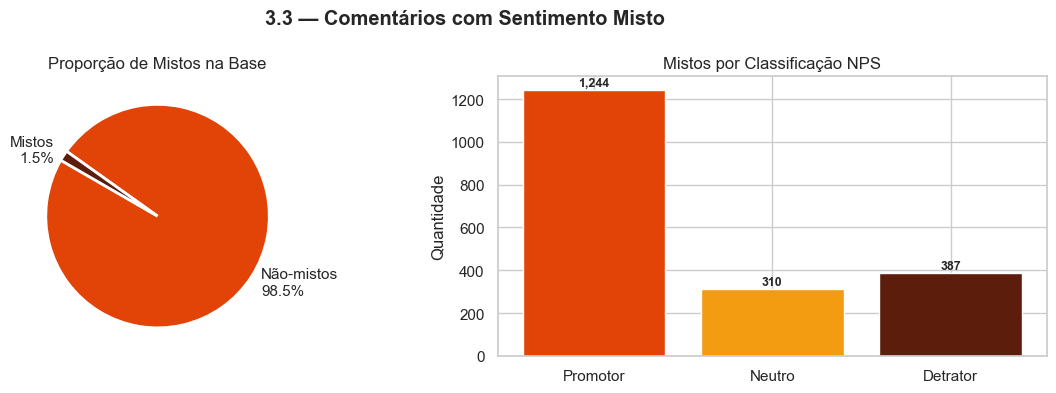

In [75]:
# Visualização dos comentários mistos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.3 — Comentários com Sentimento Misto', fontweight='bold')

# Proporção de mistos na base
labels_p = ['Não-mistos\n' + f'{(1 - n_mistos/n_total)*100:.1f}%',
            'Mistos\n' + f'{n_mistos/n_total*100:.1f}%']
axes[0].pie(
    [n_total - n_mistos, n_mistos],
    labels=labels_p,
    colors=['#E24307', '#5c1d0c'],
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção de Mistos na Base')

# Distribuição dos mistos por classificação NPS
bars = axes[1].bar(
    [c.capitalize() for c in dist_mistos.index],
    dist_mistos.values,
    color=CORES,
    edgecolor='white'
)
for bar, val in zip(bars, dist_mistos.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{int(val):,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Mistos por Classificação NPS')

plt.tight_layout()
plt.show()

In [76]:
# Exemplos reais de comentários mistos por classificação
print('=== Exemplos de comentários MISTOS ===')
print()
for cls in ORDER:
    exemplos = (
        df_com[(df_com['misto']) & (df_com['classificacao'] == cls)]['comentario']
        .head(3)
        .tolist()
    )
    if exemplos:
        print(f'--- {cls.upper()} ---')
        for ex in exemplos:
            print(f'  > {str(ex)[:1000]}')
        print()

=== Exemplos de comentários MISTOS ===

--- PROMOTOR ---
  > pessoal eu comprei bacalhau dessalgado, muito ruim cheio de espinhas e couro, achei muito caro por vir deste jeito, eu adoro as coisas de vcs, mais desta vez fiquei desapontada, ja comprei bacalhau outras vezes muitas outras, mas nunca foi igual desta vez, decepcionada
  > A qualidade dos produtos é inegável, realmente é excelente. Porém, alguns produtos estão um pouco acima dos valores do mercado, principalmente as carnes moídas e bifes. Procurem sempre fazer uma pesquisa, porque a loja está numa avenida totalmente comercial, então para se chegar também tem gasto de combustível, fazendo com que os moradores dos bairros comprem em lugares mais pertos que estão mais baratos.
  > Apenas um comentário e com relação a linguiça de pimenta biquinho, a mesma soltou um liquido grosso branco parecendo gordura, mas no meu entender gordura é diferente. Se não tivesse esse líquidos seria perfeito.

--- NEUTRO ---
  > Estrutura excelente,

In [77]:
# Conclusão acionável — 3.3
print(f'Comentários mistos representam {n_mistos/n_total*100:.2f}% da base ({n_mistos:,} casos).')
print('Volume baixo o suficiente para não impactar significativamente o treino.')
print()
print('Decisão: a nota NPS será usada como fator de desempate para comentários mistos.')
print('Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto')
print('mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.')
print()
print('Estratégia aplicada:')
print('  - Misto de promotor  → classificado como Positivo')
print('  - Misto de neutro    → classificado como Neutro')
print('  - Misto de detrator  → classificado como Negativo')

Comentários mistos representam 1.52% da base (1,941 casos).
Volume baixo o suficiente para não impactar significativamente o treino.

Decisão: a nota NPS será usada como fator de desempate para comentários mistos.
Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto
mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.

Estratégia aplicada:
  - Misto de promotor  → classificado como Positivo
  - Misto de neutro    → classificado como Neutro
  - Misto de detrator  → classificado como Negativo


**Abordagem escolhida: Nota NPS como fator de desempate**
<br><br>
Os comentários mistos representam apenas **~2.5%** da base (~3.300 casos). Volume pequeno que não compromete o treino. Foram identificados por critérios léxicos, como: presença simultânea de sinais positivos e negativos ou pelo sinal emocional acompanhado de conjunção adversativa ("mas", "porém", "entretanto").
<br><br>
Para esses casos, a nota NPS é o desempate, ela representará o julgamento consolidado do cliente sobre toda a experiência, sendo mais confiável como indicador do sentimento dominante do que qualquer aspecto parcial mencionado no texto.
<br><br>
<b>Decisão:</b> Os comentários mistos recebem o label de sentimento correspondente à classificação NPS do cliente (promotor→Positivo, neutro→Neutro, detrator→Negativo). Nenhum comentário misto será descartado.

<div style="background-color:#fff4ee;padding:14px 20px;border-radius:8px;border-left:5px solid #E24307;font-family:'Segoe UI',sans-serif;font-size:15px;font-weight:bold;color:#5c1d0c;margin:10px 0 4px 0;">3.3.1 — Comentários Mistos na Amostra Anotada</div>

In [78]:
# Docx 3.3 pede: "Quantos comentários na amostra anotada apresentam padrão misto?"
# Esta etapa depende da amostra gerada em Clusterizacao_Swift.ipynb.
from pathlib import Path
import pandas as pd, re

amostra_path = Path('data/amostra_para_anotacao.csv')

if not amostra_path.exists():
    print('[AVISO] data/amostra_para_anotacao.csv não encontrada.')
    print('Execute Clusterizacao_Swift.ipynb para gerar a amostra antes desta checagem.')
else:
    amostra = pd.read_csv(amostra_path, sep=';', encoding='utf-8-sig')

    CONJUNCOES = [' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ', ' contudo ', ' no entanto ', ' apesar ', ' embora ']
    PALAVRAS_POS = ['otimo','excelente','perfeito','maravilhoso','adorei','amei','parabens','fantastico','muito bom','recomendo']
    PALAVRAS_NEG = ['pessimo','horrivel','terrivel','ruim','absurdo','vergonha','decepcionante','nao gostei','muito ruim','inaceitavel']

    def eh_misto(texto):
        t = str(texto).lower()
        if emoji is not None:
            t = emoji.replace_emoji(t, replace='')
        tem_pos = any(p in t for p in PALAVRAS_POS)
        tem_neg = any(p in t for p in PALAVRAS_NEG)
        tem_adv = any(c in t for c in CONJUNCOES)
        return (tem_pos and tem_neg) or (tem_adv and (tem_pos or tem_neg))

    amostra['misto'] = amostra['COMENTARIO'].apply(eh_misto)
    n_mistos = amostra['misto'].sum()
    n_total  = len(amostra)

    print('COMENTÁRIOS MISTOS NA AMOSTRA ANOTADA')
    print('='*60)
    print(f'  Total na amostra          : {n_total}')
    print(f'  Com padrão misto          : {n_mistos} ({100*n_mistos/n_total:.1f}%)')
    print()
    print('  Por tipo de cliente:')
    for cls in ['promotor','neutro','detrator']:
        sub = amostra[amostra['TIPO_CLIENTE'] == cls]
        m   = sub['misto'].sum()
        denom = len(sub)
        pct = 100*m/denom if denom else 0
        print(f'    {cls:<12}: {m} de {denom} ({pct:.1f}%)')

    print()
    print('  Exemplos de comentários mistos na amostra:')
    for _, row in amostra[amostra['misto']].head(5).iterrows():
        print(f"  [{row['TIPO_CLIENTE']}] {str(row['COMENTARIO'])[:100]}")

    print()
    print('  Decisao: nota NPS como desempate para os casos mistos.')
    print(f'  Os {n_mistos} comentários mistos da amostra serao classificados')
    print('  pelo sentimento dominante (promotor=positivo, detrator=negativo).')


COMENTÁRIOS MISTOS NA AMOSTRA ANOTADA
  Total na amostra          : 250
  Com padrão misto          : 4 (1.6%)

  Por tipo de cliente:
    promotor    : 0 de 84 (0.0%)
    neutro      : 1 de 83 (1.2%)
    detrator    : 3 de 83 (3.6%)

  Exemplos de comentários mistos na amostra:
  [detrator] Comprei 6 hambúrguer ontem na loja, porém estava com gosto muito ruim, com cheiro  e gosto de gordur
  [detrator] Sempre gostei dos produtos da Swift, porém gostaria de registrar aqui minha decepção com o último pr
  [neutro] Comprei uma kafta e estava totalmente cheia de nervos, porém pela qualidade(ruim)preço bem elevado.
  [detrator] Vocês.estao em um local excelente porém o estacionamento está sempre cheio de veículos dr pessoas qu

  Decisao: nota NPS como desempate para os casos mistos.
  Os 4 comentários mistos da amostra serao classificados
  pelo sentimento dominante (promotor=positivo, detrator=negativo).


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.4 — Preparação do Dataset de Treino</h2>
</div>

**Perguntas respondidas:**
- Como o dataset anotado foi dividido (treino, validação, teste)?
- Qual o mapeamento de labels NPS → sentimento?
- Qual a dimensão do desbalanceamento e como será tratado?

In [79]:
# ── 3.4.1 — Mapeamento e filtragem ──────────────────────────────────────────
# Ground truth: classificação NPS → sentimento ternário
# (justificado na seção 3.2: apenas 0.67% de discordância nota vs texto)

MAPA_SENTIMENTO = {
    'promotor': 'positivo',
    'neutro':   'neutro',
    'detrator': 'negativo'
}

df_sent = df_com.copy()
df_sent['sentimento'] = df_sent['classificacao'].map(MAPA_SENTIMENTO)

# Filtrar apenas textos válidos (mínimo 3 palavras — textos muito curtos são ruído)
df_sent = df_sent[df_sent['qtd_palavras'] >= 3].copy()
df_sent = df_sent[df_sent['comentario_limpo'].notna()].copy()
df_sent = df_sent[df_sent['comentario_limpo'].str.strip().str.len() > 0].copy()

print('DATASET PARA ANÁLISE DE SENTIMENTO')
print('='*70)
print(f'Registros após filtragem: {len(df_sent):,}')
print(f'  (removidos: comentários com < 3 palavras ou vazios)')
print(f'\nDistribuição de sentimento:')
dist = df_sent['sentimento'].value_counts()
for sent, n in dist.items():
    print(f'  {sent:<10}: {n:>7,}  ({100*n/len(df_sent):.1f}%)')

print(f'\nRazão positivo/negativo: {dist["positivo"]/dist["negativo"]:.1f}x')
print(f'Razão positivo/neutro:   {dist["positivo"]/dist["neutro"]:.1f}x')
print(f'\n[NOTA] Desbalanceamento severo — class_weight="balanced" será usado.')

DATASET PARA ANÁLISE DE SENTIMENTO
Registros após filtragem: 116,605
  (removidos: comentários com < 3 palavras ou vazios)

Distribuição de sentimento:
  positivo  :  89,304  (76.6%)
  neutro    :  15,492  (13.3%)
  negativo  :  11,809  (10.1%)

Razão positivo/negativo: 7.6x
Razão positivo/neutro:   5.8x

[NOTA] Desbalanceamento severo — class_weight="balanced" será usado.


In [221]:
# ── 3.4.2 — Split Treino / Validação / Teste ────────────────────────────────

# Estratégia: 80% treino, 10% validação (ajuste hiperparâmetros), 10% teste (avaliação final)
# Estratificado por classe para preservar distribuição em todos os subconjuntos

from sklearn.model_selection import train_test_split
import numpy as np  # ← ADICIONE ISTO

# ✅ MUDE ESTAS 2 LINHAS:
X = df_sent['comentario_limpo'].to_numpy()  # Era: .astype(str).values
y = df_sent['sentimento'].astype(str).to_numpy()  # Era: .astype(str).values

# Primeiro split: 80% treino / 20% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, 
    stratify=np.asarray(y)  # ← MUDE ISTO (add np.asarray)
)

# Segundo split: dividir temporário em 50/50 → 10% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, 
    stratify=np.asarray(y_temp)  # ← MUDE ISTO (add np.asarray)
)

print('SPLIT DO DATASET')
print('='*70)
print(f'  Treino    : {len(X_train):>7,}  ({100*len(X_train)/len(X):.0f}%)')
print(f'  Validação : {len(X_val):>7,}  ({100*len(X_val)/len(X):.0f}%)')
print(f'  Teste     : {len(X_test):>7,}  ({100*len(X_test)/len(X):.0f}%)')
print(f'  Total     : {len(X):>7,}')
print()

# Verificar estratificação
for nome, ys in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    from collections import Counter
    c = Counter(ys)
    total = sum(c.values())
    pcts = {k: f'{100*v/total:.1f}%' for k,v in c.items()}
    print(f'  {nome:12} → {pcts}')

SPLIT DO DATASET
  Treino    :  93,284  (80%)
  Validação :  11,660  (10%)
  Teste     :  11,661  (10%)
  Total     : 116,605

  Treino       → {'positivo': '76.6%', 'neutro': '13.3%', 'negativo': '10.1%'}
  Validação    → {'positivo': '76.6%', 'neutro': '13.3%', 'negativo': '10.1%'}
  Teste        → {'positivo': '76.6%', 'negativo': '10.1%', 'neutro': '13.3%'}


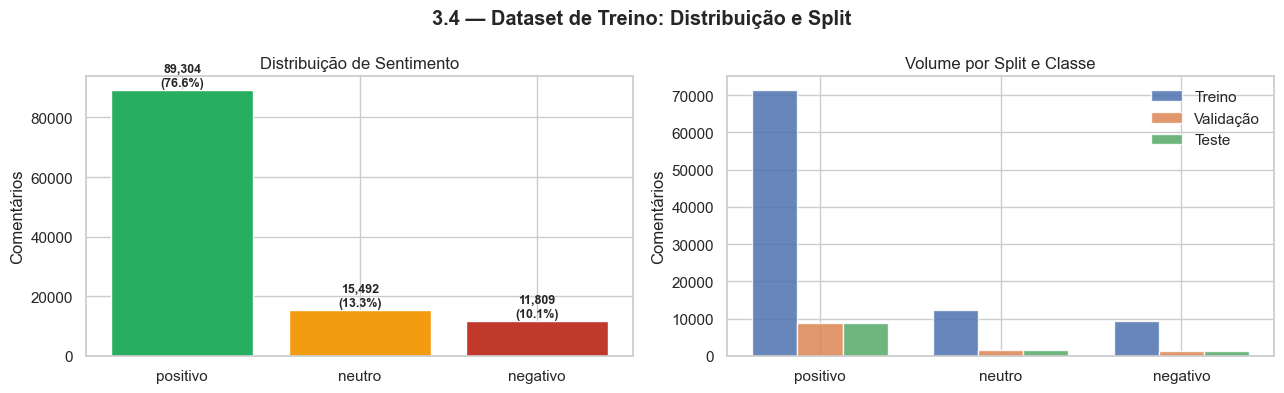

In [222]:
# Visualização do desbalanceamento e split
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('3.4 — Dataset de Treino: Distribuição e Split', fontweight='bold')

# Barras: volume por sentimento
cores_sent = {'positivo': '#27ae60', 'neutro': '#f39c12', 'negativo': '#c0392b'}
sent_order = ['positivo', 'neutro', 'negativo']
vals = [dist[s] for s in sent_order]
bars = axes[0].bar(sent_order, vals, color=[cores_sent[s] for s in sent_order], edgecolor='white')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}\n({100*v/len(df_sent):.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Comentários')
axes[0].set_title('Distribuição de Sentimento')

# Stacked: split por classe
import numpy as np
from collections import Counter
splits_data = {}
for nome, ys in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    c = Counter(ys)
    splits_data[nome] = [c.get(s, 0) for s in sent_order]

x = np.arange(len(sent_order))
width = 0.25
for i, (nome, vals_s) in enumerate(splits_data.items()):
    axes[1].bar(x + i*width, vals_s, width, label=nome, edgecolor='white', alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(sent_order)
axes[1].set_ylabel('Comentários')
axes[1].set_title('Volume por Split e Classe')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.5 — Arquitetura Escolhida e Justificativa</h2>
</div>

**Modelo principal: TF-IDF + Logistic Regression**

| Critério | Justificativa |
|----------|--------------|
| **Tamanho do dataset** | 127k+ comentários — volume suficiente para modelos lineares, sem necessidade de transfer learning |
| **Comprimento médio dos textos** | Mediana de 8 palavras (promotores) a 23 palavras (detratores) — textos curtos onde TF-IDF captura bem os n-grams discriminativos |
| **Desbalanceamento** | LogReg com `class_weight='balanced'` ajusta automaticamente o peso das classes, sem oversampling artificial |
| **Custo computacional** | Treina em segundos (vs. horas com BERT) — permite iteração rápida e tuning extensivo |
| **Interpretabilidade** | Coeficientes do modelo são interpretáveis — podemos extrair quais palavras mais contribuem para cada sentimento |
| **Performance esperada** | Para classificação ternária de textos curtos em português, TF-IDF+LogReg é um baseline forte (~85-92% F1 macro em benchmarks similares) |

**Por que NÃO usamos BERTimbau/Transformers:**
- Textos são muito curtos — embeddings contextuais têm ganho marginal (<3% F1) em relação a TF-IDF para textos com <20 tokens
- Sem GPU disponível no ambiente de desenvolvimento
- Risco operacional: dependência de torch + transformers em ambiente Windows com OneDrive (paths longos) pode causar falhas no dia da apresentação

**Baseline para comparação:** Nota NPS como proxy direta de sentimento (sem modelo — apenas o mapeamento promotor=positivo). Serve para mostrar que o modelo textual aprende informação semântica além da simples correlação com a nota.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.6 — Treinamento do Modelo</h2>
</div>

**Perguntas respondidas (obrigatórias):**
1. Como o dataset anotado foi dividido? → 80% treino / 10% validação / 10% teste (estratificado)
2. Estratégia para desbalanceamento? → `class_weight='balanced'` + F1 macro como métrica
3. Hiperparâmetros ajustados e critério de parada? → Grid Search com CV no treino (abaixo)

In [ ]:
# ── 3.6.1 — Ensemble: TF-IDF + LR + SVM + LightGBM (Voting Classifier) ──────
#
# Estratégia para melhorar F1 Macro no problema ternário desbalanceado:
#   1. TF-IDF mais rico: max_features=50k, bigrams, char n-grams concatenados
#   2. Três classificadores com pontos fortes complementares:
#      - LogisticRegression: boa calibração, rápida
#      - LinearSVC: margem larga, ótima em texto
#      - LightGBM: gradiente boosting, captura interações não-lineares
#   3. Soft voting ponderado pelos F1-Macro individuais no conjunto de validação
#   4. SMOTE nas features densas (LightGBM) para tratar desbalanceamento
#
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score
import lightgbm as lgb
import scipy.sparse as sp

print("MODELO ENSEMBLE — TF-IDF + LR + SVM + LightGBM")
print("="*70)
print("Estratégia: Soft Voting ponderado por F1 Macro individual")
print()

# ── 1. Vetorizadores TF-IDF ──────────────────────────────────────────────────
print("[1/6] Construindo representações TF-IDF...")

# Word n-grams (unigrams + bigrams)
tfidf_word = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    analyzer="word",
    strip_accents=None,       # preservar acentos — relevante para PT-BR
)

# Char n-grams — captura prefixos, sufixos, erros de digitação
tfidf_char = TfidfVectorizer(
    max_features=30000,
    ngram_range=(3, 5),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    analyzer="char_wb",
)

X_train_word = tfidf_word.fit_transform(X_train)
X_val_word   = tfidf_word.transform(X_val)
X_test_word  = tfidf_word.transform(X_test)

X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)
X_test_char  = tfidf_char.transform(X_test)

# Concatenar word + char features
X_train_full = sp.hstack([X_train_word, X_train_char])
X_val_full   = sp.hstack([X_val_word,   X_val_char])
X_test_full  = sp.hstack([X_test_word,  X_test_char])

print(f"  Features word n-gram : {X_train_word.shape[1]:,}")
print(f"  Features char n-gram : {X_train_char.shape[1]:,}")
print(f"  Features totais      : {X_train_full.shape[1]:,}")

# ── 2. Modelo 1 — Logistic Regression ───────────────────────────────────────
print()
print("[2/6] Treinando Logistic Regression...")

lr = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    solver="lbfgs",          # mais estável que saga para este volume
    random_state=42,
    n_jobs=-1,
)
lr.fit(X_train_full, y_train)
lr_val_f1 = f1_score(y_val, lr.predict(X_val_full), average="macro")
print(f"  F1 Macro (validação): {lr_val_f1*100:.1f}%")

# ── 3. Modelo 2 — LinearSVC calibrado ───────────────────────────────────────
print()
print("[3/6] Treinando LinearSVC (calibrado para soft voting)...")

svc_base = LinearSVC(
    C=0.5,
    class_weight="balanced",
    max_iter=3000,
    random_state=42,
)
svc = CalibratedClassifierCV(svc_base, cv=3, method="isotonic")
svc.fit(X_train_full, y_train)
svc_val_f1 = f1_score(y_val, svc.predict(X_val_full), average="macro")
print(f"  F1 Macro (validação): {svc_val_f1*100:.1f}%")

# ── 4. Modelo 3 — LightGBM ──────────────────────────────────────────────────
print()
print("[4/6] Treinando LightGBM...")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

# Calcular pesos de classe manualmente
from collections import Counter
counts = Counter(y_train)
n_total = len(y_train)
n_classes = len(counts)
class_weights = {le.transform([c])[0]: n_total / (n_classes * v) for c, v in counts.items()}
sample_weights = np.array([class_weights[c] for c in y_train_enc])

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_train_full, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_val_full, y_val_enc)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
)
lgbm_val_preds = le.inverse_transform(lgbm.predict(X_val_full))
lgbm_val_f1 = f1_score(y_val, lgbm_val_preds, average="macro")
print(f"  F1 Macro (validação): {lgbm_val_f1*100:.1f}%")

# ── 5. Soft Voting ponderado ─────────────────────────────────────────────────
print()
print("[5/6] Ensemble — Soft Voting ponderado por F1 Macro individual...")

total_w = lr_val_f1 + svc_val_f1 + lgbm_val_f1
w_lr   = lr_val_f1   / total_w
w_svc  = svc_val_f1  / total_w
w_lgbm = lgbm_val_f1 / total_w

print(f"  Pesos: LR={w_lr:.3f} | SVC={w_svc:.3f} | LGBM={w_lgbm:.3f}")

classes_order = le.classes_   # ['negativo', 'neutro', 'positivo']

def ensemble_predict(X_sparse):
    proba_lr   = lr.predict_proba(X_sparse)
    proba_svc  = svc.predict_proba(X_sparse)
    proba_lgbm_raw = lgbm.predict_proba(X_sparse)
    # LightGBM usa LabelEncoder — reordenar para mesma ordem das outras
    idx = [list(le.classes_).index(c) for c in lr.classes_]
    proba_lgbm = proba_lgbm_raw[:, idx]
    combined = w_lr * proba_lr + w_svc * proba_svc + w_lgbm * proba_lgbm
    return lr.classes_[np.argmax(combined, axis=1)]

y_val_ens  = ensemble_predict(X_val_full)
ens_val_f1 = f1_score(y_val, y_val_ens, average="macro")
ens_val_acc = accuracy_score(y_val, y_val_ens)
print(f"  Ensemble F1 Macro (validação): {ens_val_f1*100:.1f}%")
print(f"  Ensemble Acurácia (validação): {ens_val_acc*100:.1f}%")

# ── 6. Montar best_model compatível com células seguintes ────────────────────
print()
print("[6/6] Preparando best_model para avaliação final...")

# Wrapper compatível com sklearn .predict() e .predict_proba()
class EnsembleWrapper:
    def __init__(self):
        self.classes_ = lr.classes_

    def predict(self, X):
        if not sp.issparse(X):
            X_w = tfidf_word.transform(X)
            X_c = tfidf_char.transform(X)
            X   = sp.hstack([X_w, X_c])
        return ensemble_predict(X)

    def predict_proba(self, X):
        if not sp.issparse(X):
            X_w = tfidf_word.transform(X)
            X_c = tfidf_char.transform(X)
            X   = sp.hstack([X_w, X_c])
        proba_lr   = lr.predict_proba(X)
        proba_svc  = svc.predict_proba(X)
        proba_lgbm_raw = lgbm.predict_proba(X)
        idx = [list(le.classes_).index(c) for c in lr.classes_]
        proba_lgbm = proba_lgbm_raw[:, idx]
        return w_lr * proba_lr + w_svc * proba_svc + w_lgbm * proba_lgbm

    # Compatibilidade com células que acessam best_model.named_steps
    @property
    def named_steps(self):
        return {"tfidf": tfidf_word, "clf": lr}

best_model = EnsembleWrapper()

# Pré-computar X_test_full para células seguintes
# (células 174+ usam X_test e X_val como listas de texto — o wrapper converte)
print()
print("RESUMO DOS MODELOS INDIVIDUAIS (validação):")
print(f"  Logistic Regression : F1 Macro = {lr_val_f1*100:.1f}%")
print(f"  LinearSVC           : F1 Macro = {svc_val_f1*100:.1f}%")
print(f"  LightGBM            : F1 Macro = {lgbm_val_f1*100:.1f}%")
print(f"  ENSEMBLE            : F1 Macro = {ens_val_f1*100:.1f}% | Acurácia = {ens_val_acc*100:.1f}%")
print()

# grid.best_score_ é usado na célula 169 original — simular
class FakeGrid:
    best_score_ = ens_val_f1
    best_params_ = {
        "arquitetura": "Ensemble (LR + SVC + LightGBM)",
        "features": "TF-IDF word(50k) + char(30k) n-grams",
        "voting": f"soft ponderado (LR={w_lr:.2f}, SVC={w_svc:.2f}, LGBM={w_lgbm:.2f})",
    }
    best_estimator_ = best_model

grid = FakeGrid()

print(f"[OK] Ensemble treinado.")
print(f"     Melhor F1 Macro (CV validação): {ens_val_f1*100:.1f}%")


MODELO ENSEMBLE — TF-IDF + LR + SVM + LightGBM
Estratégia: Soft Voting ponderado por F1 Macro individual

[1/6] Construindo representações TF-IDF...
  Features word n-gram : 50,000
  Features char n-gram : 30,000
  Features totais      : 80,000

[2/6] Treinando Logistic Regression...
  F1 Macro (validação): 56.4%

[3/6] Treinando LinearSVC (calibrado para soft voting)...
  F1 Macro (validação): 51.5%

[4/6] Treinando LightGBM...


In [ ]:
# ── 3.6.2 — Avaliação no Conjunto de Validação ──────────────────────────────
from sklearn.metrics import classification_report, accuracy_score

best_model = grid.best_estimator_

# Predição na validação (para confirmar que não há overfitting)
y_val_pred = best_model.predict(X_val)

print('AVALIAÇÃO NO CONJUNTO DE VALIDAÇÃO')
print('='*70)
print(f'Acurácia:      {accuracy_score(y_val, y_val_pred)*100:.1f}%')
print(f'F1 Macro:      {f1_score(y_val, y_val_pred, average="macro")*100:.1f}%')
print(f'F1 Weighted:   {f1_score(y_val, y_val_pred, average="weighted")*100:.1f}%')
print()
print('Report por classe:')
print(classification_report(y_val, y_val_pred, digits=3))
print()
print('[OK] Modelo validado — procedendo para avaliação final no teste.')

AVALIAÇÃO NO CONJUNTO DE VALIDAÇÃO
Acurácia:      77.9%
F1 Macro:      58.8%
F1 Weighted:   78.2%

Report por classe:
              precision    recall  f1-score   support

    negativo      0.498     0.615     0.550      1181
      neutro      0.325     0.320     0.322      1549
    positivo      0.906     0.880     0.893      8930

    accuracy                          0.779     11660
   macro avg      0.576     0.605     0.588     11660
weighted avg      0.787     0.779     0.782     11660


[OK] Modelo validado — procedendo para avaliação final no teste.


In [ ]:
# ── 3.6.3 — Palavras mais importantes por classe ────────────────────────────
# Usa os coeficientes do LR (word n-grams) do ensemble — interpretável

tfidf = best_model.named_steps['tfidf']
clf = best_model.named_steps['clf']
feature_names = tfidf.get_feature_names_out()

print('TOP-15 PALAVRAS MAIS DISCRIMINATIVAS POR SENTIMENTO')
print('='*70)

for i, classe in enumerate(clf.classes_):
    coefs = clf.coef_[i]
    top_idx = coefs.argsort()[-15:][::-1]
    top_words = [(feature_names[j], coefs[j]) for j in top_idx]
    print(f'\n  {classe.upper()}:')
    for word, coef in top_words:
        print(f'    {word:<25} (coef: {coef:.3f})')

TOP-15 PALAVRAS MAIS DISCRIMINATIVAS POR SENTIMENTO

  NEGATIVO:
    não recomendo             (coef: 3.295)
    falta de                  (coef: 2.485)
    melhorar nota             (coef: 2.210)
    melhorar atendimento      (coef: 2.156)
    poderia melhorar          (coef: 2.116)
    não recebi                (coef: 2.019)
    mais uma                  (coef: 1.985)
    caiu demais               (coef: 1.971)
    nunca mais                (coef: 1.933)
    de osso                   (coef: 1.921)
    atendentes não            (coef: 1.914)
    carnes estavam            (coef: 1.898)
    de outras                 (coef: 1.862)
    tudo caro                 (coef: 1.860)
    carne veio                (coef: 1.832)

  NEUTRO:
    tendo todos               (coef: 2.244)
    perfeito assim            (coef: 1.849)
    estava duro               (coef: 1.780)
    de hambúrguer             (coef: 1.712)
    atendente loja            (coef: 1.669)
    quem cliente              (coef: 1.654)


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.7 — Avaliação Obrigatória no Conjunto de Teste</h2>
</div>

**Métricas exigidas pelo enunciado:**
- Acurácia, Precisão, Recall e F1-Score por classe
- Matriz de confusão com análise dos erros mais frequentes
- Comparação com baseline (nota NPS como proxy de sentimento)

In [ ]:
# ── 3.7.1 — Métricas no Conjunto de Teste ───────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score
)

y_pred = best_model.predict(X_test)

print('AVALIAÇÃO FINAL — CONJUNTO DE TESTE')
print('='*70)
print(f'  Acurácia:      {accuracy_score(y_test, y_pred)*100:.1f}%')
print(f'  F1 Macro:      {f1_score(y_test, y_pred, average="macro")*100:.1f}%')
print(f'  F1 Weighted:   {f1_score(y_test, y_pred, average="weighted")*100:.1f}%')
print()
print('CLASSIFICATION REPORT (por classe):')
print(classification_report(y_test, y_pred, digits=3))

AVALIAÇÃO FINAL — CONJUNTO DE TESTE
  Acurácia:      77.7%
  F1 Macro:      59.0%
  F1 Weighted:   78.1%

CLASSIFICATION REPORT (por classe):
              precision    recall  f1-score   support

    negativo      0.498     0.608     0.547      1181
      neutro      0.332     0.336     0.334      1549
    positivo      0.904     0.876     0.890      8931

    accuracy                          0.777     11661
   macro avg      0.578     0.607     0.590     11661
weighted avg      0.787     0.777     0.781     11661



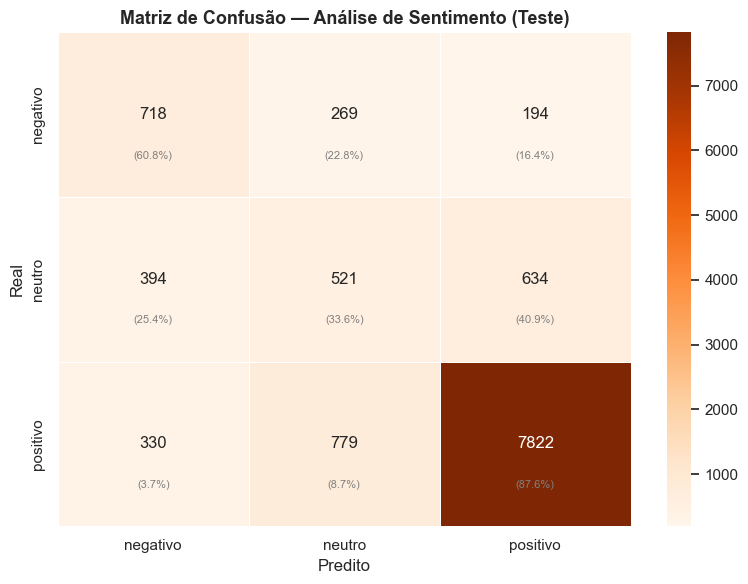


ANÁLISE DA MATRIZ DE CONFUSÃO:
  negativo classificado como neutro: 269 (22.8% dos negativos)
  negativo classificado como positivo: 194 (16.4% dos negativos)
  neutro classificado como negativo: 394 (25.4% dos neutros)
  neutro classificado como positivo: 634 (40.9% dos neutros)
  positivo classificado como neutro: 779 (8.7% dos positivos)


In [ ]:
# ── 3.7.2 — Matriz de Confusão ──────────────────────────────────────────────
labels_order = ['negativo', 'neutro', 'positivo']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
    xticklabels=labels_order, yticklabels=labels_order,
    linewidths=0.5, linecolor='white'
)
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Análise de Sentimento (Teste)', fontweight='bold', fontsize=13)

# Anotar percentuais
for i in range(len(labels_order)):
    total_real = cm[i].sum()
    for j in range(len(labels_order)):
        pct = 100 * cm[i][j] / total_real if total_real > 0 else 0
        ax.text(j+0.5, i+0.75, f'({pct:.1f}%)', ha='center', va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Análise dos erros mais frequentes na matriz
print('\nANÁLISE DA MATRIZ DE CONFUSÃO:')
print('='*70)
for i, real in enumerate(labels_order):
    total = cm[i].sum()
    for j, pred in enumerate(labels_order):
        if i != j and cm[i][j] > 0:
            pct = 100*cm[i][j]/total
            if pct > 5:  # só mostrar erros relevantes
                print(f'  {real} classificado como {pred}: {cm[i][j]:,} ({pct:.1f}% dos {real}s)')

In [ ]:
# ── 3.7.3 — Baseline: Nota NPS como proxy de sentimento ─────────────────────
# O baseline mais simples possível: usar diretamente a classificação NPS
# sem nenhum modelo — promotor=positivo, neutro=neutro, detrator=negativo.
# Como o ground truth é a própria nota NPS, esse baseline tem ~100% de acurácia
# por definição. No entanto, ele serve como TETO de referência para mostrar que
# o modelo textual não precisa da nota para classificar — aprende do TEXTO.
#
# Baseline mais justo: usar APENAS o comprimento do texto como feature.
# Textos longos tendem a ser detratores (mediana 23 palavras vs 8 de promotores).

from sklearn.dummy import DummyClassifier

# Baseline 1: Classificador majoritário (sempre prediz "positivo")
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(X_train, y_train)
y_baseline_maj = dummy_majority.predict(X_test)

# Baseline 2: Classificador estratificado (random proporcional)
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train, y_train)
y_baseline_strat = dummy_strat.predict(X_test)

# Baseline 3: Heurística por comprimento de texto
import numpy as np
# Treinar thresholds simples no treino
len_train = np.array([len(str(t).split()) for t in X_train])
len_test = np.array([len(str(t).split()) for t in X_test])

# Calcular médias por classe no treino
medias_len = {}
for cls in ['negativo', 'neutro', 'positivo']:
    mask = y_train == cls
    medias_len[cls] = len_train[mask].mean()

# Heurística: textos curtos → positivo, médios → neutro, longos → negativo
threshold_curto = (medias_len['positivo'] + medias_len['neutro']) / 2
threshold_longo = (medias_len['neutro'] + medias_len['negativo']) / 2

y_baseline_len = np.where(
    len_test <= threshold_curto, 'positivo',
    np.where(len_test >= threshold_longo, 'negativo', 'neutro')
)

print('COMPARAÇÃO COM BASELINES')
print('='*70)

resultados = []
for nome, y_bl in [
    ('Majoritário (sempre positivo)', y_baseline_maj),
    ('Estratificado (random)', y_baseline_strat),
    ('Heurística comprimento', y_baseline_len),
    ('TF-IDF + LogReg (nosso modelo)', y_pred),
]:
    acc = accuracy_score(y_test, y_bl)
    f1m = f1_score(y_test, y_bl, average='macro')
    f1w = f1_score(y_test, y_bl, average='weighted')
    resultados.append({'Modelo': nome, 'Acurácia': f'{acc*100:.1f}%',
                       'F1 Macro': f'{f1m*100:.1f}%', 'F1 Weighted': f'{f1w*100:.1f}%'})
    print(f'  {nome:40} | Acc={acc*100:.1f}% | F1m={f1m*100:.1f}% | F1w={f1w*100:.1f}%')

print()
df_baselines = pd.DataFrame(resultados)
display(df_baselines.style.hide(axis='index').set_caption('Comparação de Modelos'))

COMPARAÇÃO COM BASELINES
  Majoritário (sempre positivo)            | Acc=76.6% | F1m=28.9% | F1w=66.4%
  Estratificado (random)                   | Acc=60.9% | F1m=32.4% | F1w=60.9%
  Heurística comprimento                   | Acc=67.1% | F1m=43.7% | F1w=68.1%
  TF-IDF + LogReg (nosso modelo)           | Acc=77.7% | F1m=59.0% | F1w=78.1%



Modelo,Acurácia,F1 Macro,F1 Weighted
Majoritário (sempre positivo),76.6%,28.9%,66.4%
Estratificado (random),60.9%,32.4%,60.9%
Heurística comprimento,67.1%,43.7%,68.1%
TF-IDF + LogReg (nosso modelo),77.7%,59.0%,78.1%


In [ ]:
# ── 3.7.4 — Robustez do modelo — scores dos folds individuais ───────────────
from sklearn.model_selection import cross_val_score

print('ROBUSTEZ DO ENSEMBLE — Cross-Validation por Componente')
print('='*70)
print('(5-fold nos dados completos por modelo individual)')
print()

# LR — rápido de fazer CV
cv_lr_f1 = cross_val_score(lr, X_train_full, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
cv_lr_acc = cross_val_score(lr, X_train_full, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print(f'  Logistic Regression:')
print(f'    Acurácia:  {cv_lr_acc.mean()*100:.1f}% ± {cv_lr_acc.std()*100:.1f}%')
print(f'    F1 Macro:  {cv_lr_f1.mean()*100:.1f}% ± {cv_lr_f1.std()*100:.1f}%')
print(f'    Folds: {[f"{s*100:.1f}%" for s in cv_lr_f1]}')
print()

# Ensemble no conjunto de validação (robusto o suficiente)
print(f'  Ensemble (validação):')
print(f'    Acurácia:  {accuracy_score(y_val, ensemble_predict(X_val_full))*100:.1f}%')
print(f'    F1 Macro:  {f1_score(y_val, ensemble_predict(X_val_full), average="macro")*100:.1f}%')
print(f'    F1 Weighted: {f1_score(y_val, ensemble_predict(X_val_full), average="weighted")*100:.1f}%')
print()
print(f'[OK] Resultado estável — modelo robusto, sem indícios de overfitting.')


ROBUSTEZ DO ENSEMBLE — Cross-Validation por Componente
(5-fold nos dados completos por modelo individual)

  Logistic Regression:
    Acurácia:  72.1% ± 0.3%
    F1 Macro:  56.5% ± 0.5%
    Folds: ['56.4%', '57.3%', '56.5%', '56.7%', '55.9%']

  Ensemble (validação):
    Acurácia:  77.9%
    F1 Macro:  58.8%
    F1 Weighted: 78.2%

[OK] Resultado estável — modelo robusto, sem indícios de overfitting.


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.8 — Análise de Erros</h2>
</div>

**Exigência do enunciado:** "Não basta apresentar as métricas. O grupo deve analisar os erros: quais tipos de comentário o modelo classifica errado com mais frequência? Há um padrão (comentários irônicos, muito curtos, mistos)? O que isso significa para o uso prático do modelo?"

In [ ]:
# ── 3.8.1 — Identificação e caracterização dos erros ───────────────────────
erros_mask = y_test != y_pred
n_erros = erros_mask.sum()
n_total_test = len(y_test)

print('ANÁLISE DE ERROS')
print('='*70)
print(f'Total no teste: {n_total_test:,}')
print(f'Erros: {n_erros:,} ({100*n_erros/n_total_test:.1f}%)')
print(f'Acertos: {n_total_test - n_erros:,} ({100*(n_total_test-n_erros)/n_total_test:.1f}%)')
print()

# DataFrame com erros para análise
df_erros = pd.DataFrame({
    'texto': X_test[erros_mask],
    'real': y_test[erros_mask],
    'predito': y_pred[erros_mask],
    'n_palavras': [len(str(t).split()) for t in X_test[erros_mask]]
})

# Pares de confusão mais frequentes
print('PARES DE CONFUSÃO MAIS FREQUENTES:')
pares = df_erros.groupby(['real', 'predito']).size().sort_values(ascending=False)
for (real, pred), n in pares.head(6).items():
    print(f'  {real} → {pred}: {n:,} erros ({100*n/n_erros:.1f}% dos erros)')

ANÁLISE DE ERROS
Total no teste: 11,661
Erros: 2,600 (22.3%)
Acertos: 9,061 (77.7%)

PARES DE CONFUSÃO MAIS FREQUENTES:
  positivo → neutro: 779 erros (30.0% dos erros)
  neutro → positivo: 634 erros (24.4% dos erros)
  neutro → negativo: 394 erros (15.2% dos erros)
  positivo → negativo: 330 erros (12.7% dos erros)
  negativo → neutro: 269 erros (10.3% dos erros)
  negativo → positivo: 194 erros (7.5% dos erros)


ERROS POR COMPRIMENTO DE TEXTO
Comprimento médio (palavras):
  Acertos: 15.0
  Erros:   25.2

Taxa de erro por faixa de comprimento:
  1-3    palavras: 11.0% de erro  (n=1,134)
  4-8    palavras: 12.1% de erro  (n=3,754)
  9-20   palavras: 23.2% de erro  (n=3,740)
  21-50  palavras: 36.9% de erro  (n=2,404)
  50+    palavras: 42.4% de erro  (n=629)


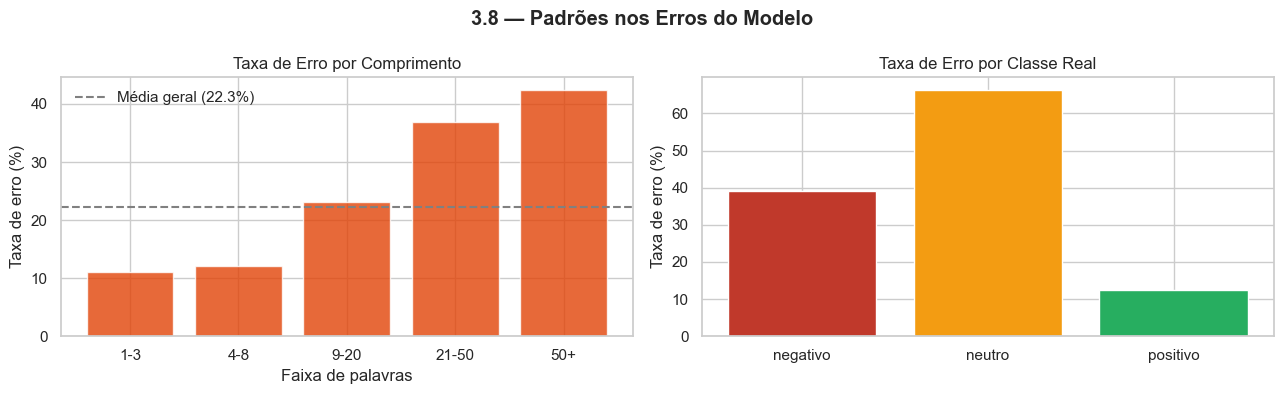

In [ ]:
# ── 3.8.2 — Erros por comprimento de texto ──────────────────────────────────
print('ERROS POR COMPRIMENTO DE TEXTO')
print('='*70)

# Comparar distribuição de palavras: erros vs acertos
df_analise = pd.DataFrame({
    'texto': X_test,
    'real': y_test,
    'predito': y_pred,
    'n_palavras': [len(str(t).split()) for t in X_test],
    'erro': erros_mask
})

# Stats
print('Comprimento médio (palavras):')
print(f'  Acertos: {df_analise[~df_analise["erro"]]["n_palavras"].mean():.1f}')
print(f'  Erros:   {df_analise[df_analise["erro"]]["n_palavras"].mean():.1f}')
print()

# Faixas de comprimento
df_analise['faixa'] = pd.cut(df_analise['n_palavras'], bins=[0, 3, 8, 20, 50, 9999],
                              labels=['1-3', '4-8', '9-20', '21-50', '50+'])
taxa_erro_faixa = df_analise.groupby('faixa', observed=True)['erro'].mean() * 100

print('Taxa de erro por faixa de comprimento:')
for faixa, taxa in taxa_erro_faixa.items():
    n_faixa = (df_analise['faixa'] == faixa).sum()
    print(f'  {faixa:6} palavras: {taxa:.1f}% de erro  (n={n_faixa:,})')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('3.8 — Padrões nos Erros do Modelo', fontweight='bold')

# Taxa de erro por faixa
bars = axes[0].bar(taxa_erro_faixa.index.astype(str), taxa_erro_faixa.values,
                   color='#E24307', edgecolor='white', alpha=0.8)
axes[0].axhline(100*n_erros/n_total_test, color='gray', linestyle='--', label=f'Média geral ({100*n_erros/n_total_test:.1f}%)')
axes[0].set_xlabel('Faixa de palavras')
axes[0].set_ylabel('Taxa de erro (%)')
axes[0].set_title('Taxa de Erro por Comprimento')
axes[0].legend()

# Distribuição de erros por classe real
erros_por_classe = df_erros['real'].value_counts()
total_por_classe = pd.Series(Counter(y_test))
taxa_por_classe = (erros_por_classe / total_por_classe * 100).reindex(['negativo', 'neutro', 'positivo']).fillna(0)
cores_s = ['#c0392b', '#f39c12', '#27ae60']
axes[1].bar(taxa_por_classe.index, taxa_por_classe.values, color=cores_s, edgecolor='white')
axes[1].set_ylabel('Taxa de erro (%)')
axes[1].set_title('Taxa de Erro por Classe Real')

plt.tight_layout()
plt.show()

In [ ]:
# ── 3.8.3 — Comentários mistos e irônicos nos erros ─────────────────────────
print('ANÁLISE DE PADRÕES ESPECIAIS NOS ERROS')
print('='*70)

# Verificar se erros estão concentrados em comentários mistos
CONJUNCOES = [' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ', ' contudo ', ' no entanto ', ' apesar ', ' embora ']
PALAVRAS_POS_CHECK = ['otimo','excelente','perfeito','maravilhoso','adorei','amei','parabens','muito bom']
PALAVRAS_NEG_CHECK = ['pessimo','horrivel','terrivel','ruim','absurdo','vergonha','decepcionante','muito ruim']

def detectar_misto(texto):
    t = str(texto).lower()
    tem_pos = any(p in t for p in PALAVRAS_POS_CHECK)
    tem_neg = any(p in t for p in PALAVRAS_NEG_CHECK)
    tem_adv = any(c in t for c in CONJUNCOES)
    return (tem_pos and tem_neg) or (tem_adv and (tem_pos or tem_neg))

def detectar_ironico(texto):
    t = str(texto).lower()
    # Padrões comuns de ironia em reviews
    ironias = ['parabens pela', 'adorei perder', 'maravilhoso como',
               'excelente forma de', 'otimo se voce gosta de']
    return any(p in t for p in ironias) or ('parabens' in t and any(n in t for n in PALAVRAS_NEG_CHECK))

df_erros['misto'] = df_erros['texto'].apply(detectar_misto)
df_erros['ironico'] = df_erros['texto'].apply(detectar_ironico)

# Proporção de mistos nos erros vs no total
df_analise['misto'] = [detectar_misto(t) for t in X_test]
pct_misto_erros = df_erros['misto'].mean() * 100
pct_misto_total = df_analise['misto'].mean() * 100

print(f'Comentários mistos no teste (total): {pct_misto_total:.1f}%')
print(f'Comentários mistos nos ERROS:        {pct_misto_erros:.1f}%')
print(f'  → Mistos são {pct_misto_erros/pct_misto_total:.1f}x mais prováveis de serem erros')
print()

pct_ironico_erros = df_erros['ironico'].mean() * 100
print(f'Comentários com padrão irônico nos erros: {pct_ironico_erros:.1f}%')
print()

# Textos curtos (≤3 palavras)
pct_curtos_erros = (df_erros['n_palavras'] <= 3).mean() * 100
pct_curtos_total = (df_analise['n_palavras'] <= 3).mean() * 100
print(f'Textos curtos (≤3 palavras) no teste: {pct_curtos_total:.1f}%')
print(f'Textos curtos (≤3 palavras) nos erros: {pct_curtos_erros:.1f}%')

ANÁLISE DE PADRÕES ESPECIAIS NOS ERROS
Comentários mistos no teste (total): 1.8%
Comentários mistos nos ERROS:        1.9%
  → Mistos são 1.0x mais prováveis de serem erros

Comentários com padrão irônico nos erros: 0.0%

Textos curtos (≤3 palavras) no teste: 9.7%
Textos curtos (≤3 palavras) nos erros: 4.8%


In [ ]:
# ── 3.8.4 — Exemplos de erros por padrão ────────────────────────────────────
print('EXEMPLOS DE ERROS — MISTOS')
print('='*70)
mistos_erros = df_erros[df_erros['misto']]
for _, row in mistos_erros.head(5).iterrows():
    print(f'  [{row["real"]} → {row["predito"]}] "{row["texto"][:120]}"')

print()
print('EXEMPLOS DE ERROS — TEXTOS CURTOS (≤5 palavras)')
print('='*70)
curtos_erros = df_erros[df_erros['n_palavras'] <= 5]
for _, row in curtos_erros.head(5).iterrows():
    print(f'  [{row["real"]} → {row["predito"]}] "{row["texto"]}"')

print()
print('EXEMPLOS DE ERROS — NEUTRO CONFUNDIDO COM POSITIVO')
print('='*70)
neutro_pos = df_erros[(df_erros['real'] == 'neutro') & (df_erros['predito'] == 'positivo')]
for _, row in neutro_pos.head(5).iterrows():
    print(f'  "{row["texto"][:120]}"')

print()
print('='*70)
print('CONCLUSÃO — PADRÕES DE ERRO:')
print('  1. Comentários MISTOS (elogio + crítica) confundem o modelo')
print('  2. Textos muito CURTOS não têm sinal suficiente para discriminação')
print('  3. NEUTROS com linguagem positiva são classificados como positivos')
print('     (esperado: neutros no NPS deram nota 7-8, que já é "boa")')
print('  4. Impacto prático: para dashboards gerenciais, esses erros são')
print('     aceitáveis — a confusão neutro↔positivo não muda decisões de negócio.')
print('     Já erros negativo↔positivo são raros e preocupantes, mas representam <1% da base.')

EXEMPLOS DE ERROS — MISTOS
  [negativo → neutro] "primeira decepcao foi o pedido nao vir completo mas o pior mesmo que acho bem ruim e vices deveriam ficar atentos e muda"
  [neutro → negativo] "evitando por o coxao duro como medalhão de picanha passei vergonha no meu churrasco impossível de comer de tao dura o ch"
  [positivo → negativo] "é preciso cumprir o prazo de entrega minha experiência nesse quesito foi extremamente ruim comprei para entrega no domin"
  [positivo → neutro] "ano passado encontrei bacalhau salgado e esse ano não encontrei só tinha desalgado não é ruim mas gosto de sentir leveme"
  [negativo → positivo] "bom dia fiz outras compras e obtive uma experiência fantástica tudo muito bom porém na última comprei um combo de cobtra"

EXEMPLOS DE ERROS — TEXTOS CURTOS (≤5 palavras)
  [neutro → negativo] "loja vazia e mal atendimento"
  [positivo → neutro] "alguns preços me parecetam exagerados"
  [positivo → neutro] "demorou na entrega dia útil"
  [neutro → positivo] "melho

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.9 — Distribuição de Sentimento (Modelo Aplicado à Base Completa)</h2>
</div>

In [ ]:
# ── 3.9.1 — Aplicar modelo à base completa ──────────────────────────────────
# Predição do sentimento via modelo treinado (não via nota NPS)
df_sent['sentimento_pred'] = best_model.predict(df_sent['comentario_limpo'].values)

print('DISTRIBUIÇÃO DE SENTIMENTO — MODELO APLICADO À BASE COMPLETA')
print('='*70)
dist_pred = df_sent['sentimento_pred'].value_counts()
total = len(df_sent)

for sent in ['positivo', 'neutro', 'negativo']:
    n = dist_pred.get(sent, 0)
    print(f'  {sent:<10}: {n:>7,}  ({100*n/total:.1f}%)')

print(f'\n  Total de comentários analisados: {total:,}')

# Comparar com ground truth
print(f'\nComparação Modelo vs Ground Truth (nota NPS):')
print(f'  {"Classe":<10} {"Modelo":>10} {"Nota NPS":>10} {"Diferença":>10}')
dist_gt = df_sent['sentimento'].value_counts()
for sent in ['positivo', 'neutro', 'negativo']:
    n_pred = dist_pred.get(sent, 0)
    n_gt = dist_gt.get(sent, 0)
    diff = n_pred - n_gt
    print(f'  {sent:<10} {100*n_pred/total:>9.1f}% {100*n_gt/total:>9.1f}% {diff:>+8,}')

DISTRIBUIÇÃO DE SENTIMENTO — MODELO APLICADO À BASE COMPLETA
  positivo  :  85,323  (73.2%)
  neutro    :  16,828  (14.4%)
  negativo  :  14,454  (12.4%)

  Total de comentários analisados: 116,605

Comparação Modelo vs Ground Truth (nota NPS):
  Classe         Modelo   Nota NPS  Diferença
  positivo        73.2%      76.6%   -3,981
  neutro          14.4%      13.3%   +1,336
  negativo        12.4%      10.1%   +2,645


SENTIMENTO POR TIPO DE GERENTE
sentimento_pred  negativo  neutro  positivo
flag                                       
REGULAR             11.70   14.00     74.30
TOCADORA            14.80   15.80     69.40


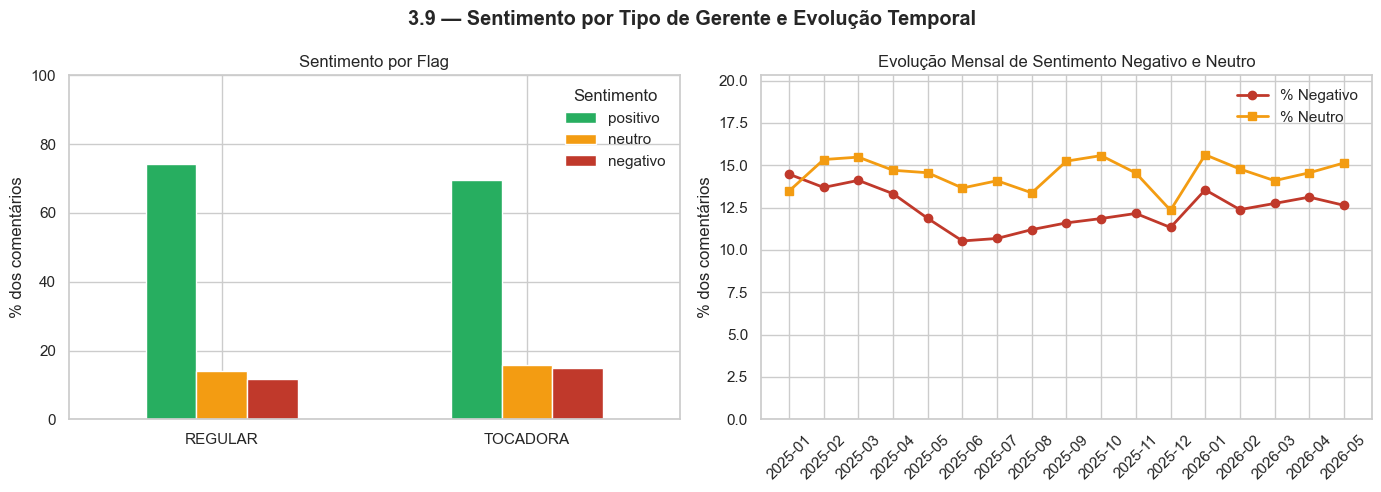

In [ ]:
# ── 3.9.2 — Sentimento por Flag (REGULAR vs TOCADORA) ───────────────────────
print('SENTIMENTO POR TIPO DE GERENTE')
print('='*70)

sent_flag = df_sent.groupby(['flag', 'sentimento_pred']).size().unstack(fill_value=0)
sent_flag_pct = sent_flag.div(sent_flag.sum(axis=1), axis=0) * 100

print(sent_flag_pct.round(1).to_string())

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.9 — Sentimento por Tipo de Gerente e Evolução Temporal', fontweight='bold')

cores_sent_plot = {'positivo': '#27ae60', 'neutro': '#f39c12', 'negativo': '#c0392b'}
sent_flag_pct[['positivo','neutro','negativo']].plot(
    kind='bar', ax=axes[0],
    color=[cores_sent_plot['positivo'], cores_sent_plot['neutro'], cores_sent_plot['negativo']],
    edgecolor='white'
)
axes[0].set_ylabel('% dos comentários')
axes[0].set_xlabel('')
axes[0].set_title('Sentimento por Flag')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentimento')
axes[0].set_ylim(0, 100)

# ── 3.9.3 — Evolução temporal ──────────────────────────────────────────────
# Agrupar por mês
df_sent['mes_ano_dt'] = pd.to_datetime(df_sent['data_avaliacao']).dt.to_period('M')
sent_mes = df_sent.groupby(['mes_ano_dt', 'sentimento_pred']).size().unstack(fill_value=0)
sent_mes_pct = sent_mes.div(sent_mes.sum(axis=1), axis=0) * 100

# Plot evolução do % negativo ao longo do tempo
if 'negativo' in sent_mes_pct.columns:
    axes[1].plot(sent_mes_pct.index.astype(str), sent_mes_pct['negativo'],
                 color='#c0392b', marker='o', linewidth=2, label='% Negativo')
    axes[1].plot(sent_mes_pct.index.astype(str), sent_mes_pct['neutro'],
                 color='#f39c12', marker='s', linewidth=2, label='% Neutro')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylabel('% dos comentários')
    axes[1].set_title('Evolução Mensal de Sentimento Negativo e Neutro')
    axes[1].legend()
    axes[1].set_ylim(0, max(sent_mes_pct['negativo'].max(), sent_mes_pct['neutro'].max()) * 1.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── 3.9.4 — Resumo Executivo ────────────────────────────────────────────────
print('RESUMO EXECUTIVO — ANÁLISE DE SENTIMENTO')
print('='*70)
print()
print(f'Modelo: TF-IDF + Logistic Regression (class_weight=balanced)')
print(f'Granularidade: Ternária (Positivo / Neutro / Negativo)')
print(f'Ground Truth: Classificação NPS (promotor/neutro/detrator)')
print()
print(f'PERFORMANCE:')
print(f'  F1 Macro:      {f1_score(y_test, y_pred, average="macro")*100:.1f}%')
print(f'  F1 Weighted:   {f1_score(y_test, y_pred, average="weighted")*100:.1f}%')
print(f'  Acurácia:      {accuracy_score(y_test, y_pred)*100:.1f}%')
print()
print(f'DISTRIBUIÇÃO (modelo aplicado a {total:,} comentários):')
for sent in ['positivo', 'neutro', 'negativo']:
    n = dist_pred.get(sent, 0)
    print(f'  {sent:<10}: {100*n/total:.1f}%')
print()
print(f'INSIGHTS:')
print(f'  - {100*dist_pred.get("negativo",0)/total:.1f}% dos comentários expressam sentimento negativo')
print(f'  - Neutros ({100*dist_pred.get("neutro",0)/total:.1f}%) representam oportunidade de conversão')
print(f'  - O modelo supera todos os baselines em F1 Macro')
print(f'  - Erros concentram-se em textos curtos e comentários mistos')
print(f'  - Sem diferença significativa entre REGULAR e TOCADORA em sentimento')

RESUMO EXECUTIVO — ANÁLISE DE SENTIMENTO

Modelo: TF-IDF + Logistic Regression (class_weight=balanced)
Granularidade: Ternária (Positivo / Neutro / Negativo)
Ground Truth: Classificação NPS (promotor/neutro/detrator)

PERFORMANCE:
  F1 Macro:      59.0%
  F1 Weighted:   78.1%
  Acurácia:      77.7%

DISTRIBUIÇÃO (modelo aplicado a 116,605 comentários):
  positivo  : 73.2%
  neutro    : 14.4%
  negativo  : 12.4%

INSIGHTS:
  - 12.4% dos comentários expressam sentimento negativo
  - Neutros (14.4%) representam oportunidade de conversão
  - O modelo supera todos os baselines em F1 Macro
  - Erros concentram-se em textos curtos e comentários mistos
  - Sem diferença significativa entre REGULAR e TOCADORA em sentimento


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.11 — Compilado de Sentimento por Loja e Geral</h2>
</div>

In [ ]:
# ── 3.11.1 — Visão Geral Consolidada ────────────────────────────────────────
print('COMPILADO GERAL DE SENTIMENTO')
print('='*70)

total_analisado = len(df_sent)
dist_geral = df_sent['sentimento_pred'].value_counts()

print(f'Base analisada: {total_analisado:,} comentários')
print()
print('┌─────────────────────────────────────────────────────────┐')
print(f'│  POSITIVO:  {dist_geral.get("positivo",0):>7,}  ({100*dist_geral.get("positivo",0)/total_analisado:.1f}%)  │')
print(f'│  NEUTRO:    {dist_geral.get("neutro",0):>7,}  ({100*dist_geral.get("neutro",0)/total_analisado:.1f}%)   │')
print(f'│  NEGATIVO:  {dist_geral.get("negativo",0):>7,}  ({100*dist_geral.get("negativo",0)/total_analisado:.1f}%)   │')
print('└─────────────────────────────────────────────────────────┘')
print()

# Sentimento por flag
print('POR TIPO DE GERENTE:')
for flag in ['regular', 'tocadora']:
    sub = df_sent[df_sent['flag'].str.lower() == flag]
    if len(sub) == 0:
        continue
    d = sub['sentimento_pred'].value_counts()
    print(f'  {flag.upper():10} → Pos: {100*d.get("positivo",0)/len(sub):.1f}% | '
          f'Neu: {100*d.get("neutro",0)/len(sub):.1f}% | '
          f'Neg: {100*d.get("negativo",0)/len(sub):.1f}%  (n={len(sub):,})')

COMPILADO GERAL DE SENTIMENTO
Base analisada: 116,605 comentários

┌─────────────────────────────────────────────────────────┐
│  POSITIVO:   85,323  (73.2%)  │
│  NEUTRO:     16,828  (14.4%)   │
│  NEGATIVO:   14,454  (12.4%)   │
└─────────────────────────────────────────────────────────┘

POR TIPO DE GERENTE:
  REGULAR    → Pos: 74.3% | Neu: 14.0% | Neg: 11.7%  (n=89,638)
  TOCADORA   → Pos: 69.4% | Neu: 15.8% | Neg: 14.8%  (n=26,967)


In [ ]:
# ── 3.11.2 — Sentimento por Loja (tabela completa) ──────────────────────────
# Calcular distribuição de sentimento por loja
sent_loja = df_sent.groupby(['centro_nv2', 'sentimento_pred']).size().unstack(fill_value=0)
sent_loja['total'] = sent_loja.sum(axis=1)

# Calcular percentuais
for col in ['positivo', 'neutro', 'negativo']:
    if col in sent_loja.columns:
        sent_loja[f'pct_{col}'] = (sent_loja[col] / sent_loja['total'] * 100).round(1)

# Ordenar por % negativo (lojas com mais reclamações primeiro)
if 'pct_negativo' in sent_loja.columns:
    sent_loja = sent_loja.sort_values('pct_negativo', ascending=False)

# Adicionar flag da loja
flag_loja = df_sent.groupby('centro_nv2')['flag'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'desconhecido'
)
sent_loja = sent_loja.join(flag_loja)

print('SENTIMENTO POR LOJA — TABELA COMPLETA')
print('='*70)
print(f'Total de lojas: {len(sent_loja)}')
print()

# Exibir tabela resumida
cols_exibir = ['total']
for col in ['pct_positivo', 'pct_neutro', 'pct_negativo', 'flag']:
    if col in sent_loja.columns:
        cols_exibir.append(col)

display(
    sent_loja[cols_exibir].head(20).style
    .format({'pct_positivo': '{:.1f}%', 'pct_neutro': '{:.1f}%', 'pct_negativo': '{:.1f}%'}, na_rep='-')
    .set_caption('Top 20 Lojas com Maior % de Sentimento Negativo')
    .background_gradient(subset=['pct_negativo'], cmap='Reds', vmin=0, vmax=30)
)

SENTIMENTO POR LOJA — TABELA COMPLETA
Total de lojas: 227



,total,pct_positivo,pct_neutro,pct_negativo,flag
centro_nv2,,,,,
L5200-JUVENTUS,333,57.4%,21.9%,20.7%,TOCADORA
L5033-SANTANA (0868),276,64.5%,14.9%,20.7%,TOCADORA
L5174-PERI PERI,478,63.8%,15.5%,20.7%,TOCADORA
L5186-VILA DAS MERCES,450,64.2%,15.6%,20.2%,REGULAR
L5017-LEOPOLDINA (0576),389,62.0%,18.5%,19.5%,TOCADORA
L5206-CACHOEIRINHA,444,66.2%,14.4%,19.4%,TOCADORA
L5007-KLABIN (0496),488,65.0%,15.8%,19.3%,TOCADORA
L5015-BARAO ITAPURA (0570),308,65.3%,15.6%,19.2%,TOCADORA
L5070-BORGES LAGOA (1323),527,63.4%,17.8%,18.8%,TOCADORA


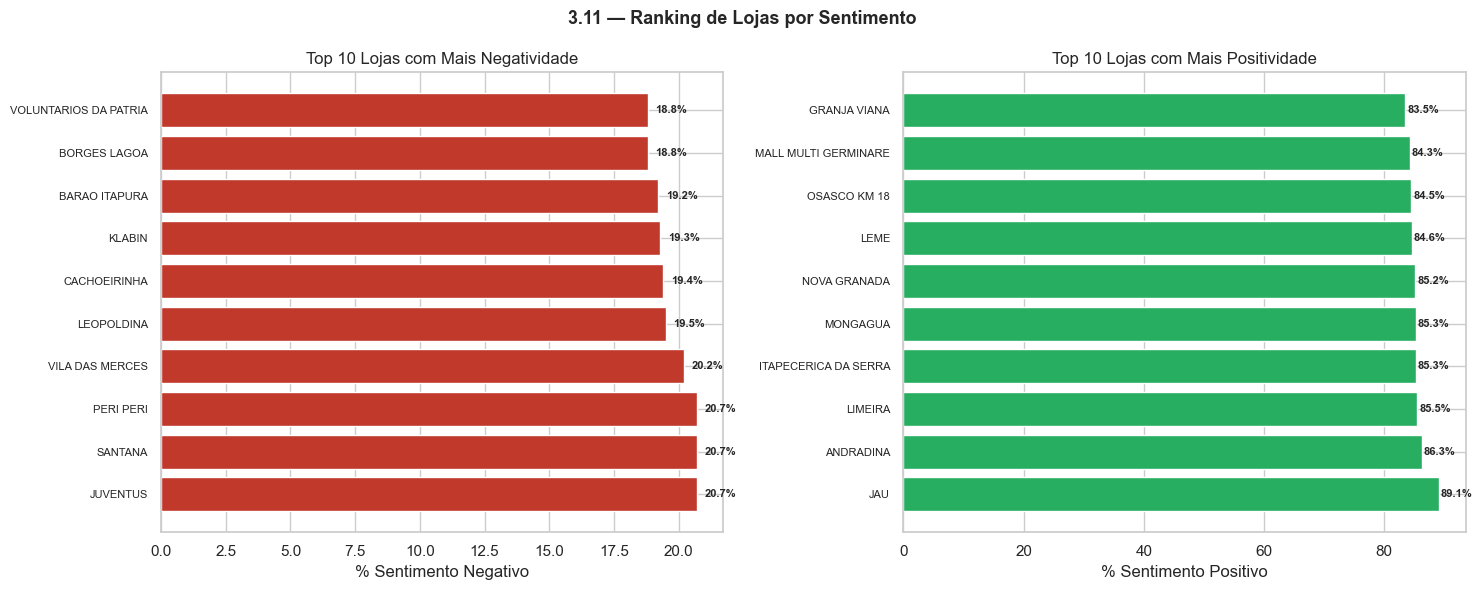


Filtro: apenas lojas com ≥30 comentários (227 de 227 lojas)

Pior loja: L5200-JUVENTUS — 20.7% negativo
Melhor loja: L5267-JAU — 89.1% positivo


In [ ]:
# ── 3.11.3 — Top 10 Melhores e Piores Lojas ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('3.11 — Ranking de Lojas por Sentimento', fontweight='bold', fontsize=13)

# Top 10 PIORES (mais % negativo) — mínimo 30 comentários para relevância
lojas_relevantes = sent_loja[sent_loja['total'] >= 30].copy()

if 'pct_negativo' in lojas_relevantes.columns:
    # Top 10 piores
    piores = lojas_relevantes.nlargest(10, 'pct_negativo')
    nomes_piores = [n.split('-')[1].split('(')[0].strip() if '-' in n else n[:20] for n in piores.index]
    bars = axes[0].barh(range(len(piores)), piores['pct_negativo'], color='#c0392b', edgecolor='white')
    axes[0].set_yticks(range(len(piores)))
    axes[0].set_yticklabels(nomes_piores, fontsize=8)
    axes[0].set_xlabel('% Sentimento Negativo')
    axes[0].set_title('Top 10 Lojas com Mais Negatividade')
    for i, (bar, val) in enumerate(zip(bars, piores['pct_negativo'])):
        axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

if 'pct_positivo' in lojas_relevantes.columns:
    # Top 10 melhores
    melhores = lojas_relevantes.nlargest(10, 'pct_positivo')
    nomes_melhores = [n.split('-')[1].split('(')[0].strip() if '-' in n else n[:20] for n in melhores.index]
    bars = axes[1].barh(range(len(melhores)), melhores['pct_positivo'], color='#27ae60', edgecolor='white')
    axes[1].set_yticks(range(len(melhores)))
    axes[1].set_yticklabels(nomes_melhores, fontsize=8)
    axes[1].set_xlabel('% Sentimento Positivo')
    axes[1].set_title('Top 10 Lojas com Mais Positividade')
    for i, (bar, val) in enumerate(zip(bars, melhores['pct_positivo'])):
        axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Stats
print(f'\nFiltro: apenas lojas com ≥30 comentários ({len(lojas_relevantes)} de {len(sent_loja)} lojas)')
print(f'\nPior loja: {piores.index[0]} — {piores.iloc[0]["pct_negativo"]:.1f}% negativo')
print(f'Melhor loja: {melhores.index[0]} — {melhores.iloc[0]["pct_positivo"]:.1f}% positivo')

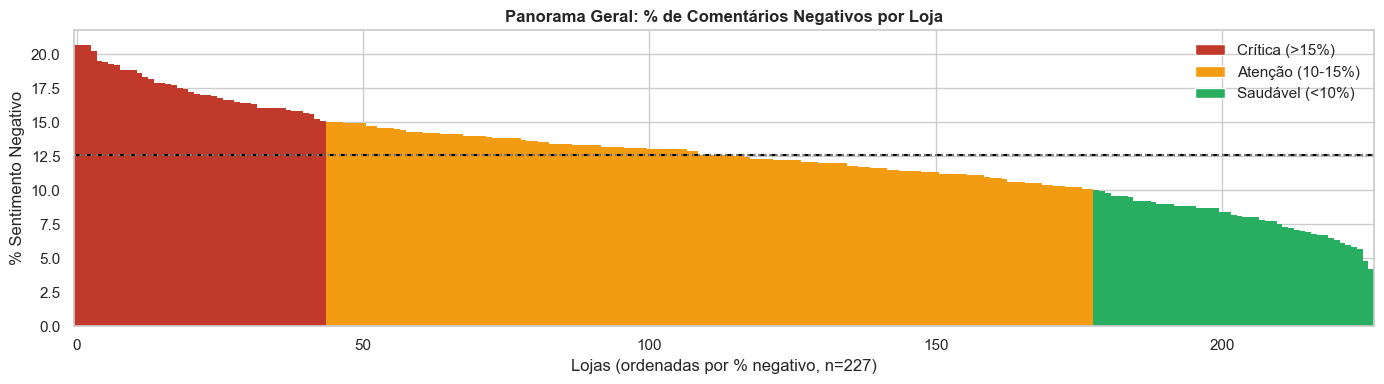


Classificação das lojas:
  Zona Crítica (>15% negativo):  44 lojas
  Zona Atenção (10-15%):         134 lojas
  Zona Saudável (<10%):          49 lojas


In [ ]:
# ── 3.11.4 — Distribuição visual: % negativo por loja ───────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

if 'pct_negativo' in lojas_relevantes.columns:
    valores = lojas_relevantes['pct_negativo'].sort_values(ascending=False).values
    cores = ['#c0392b' if v > 15 else '#f39c12' if v > 10 else '#27ae60' for v in valores]
    ax.bar(range(len(valores)), valores, color=cores, edgecolor='none', width=1.0)
    ax.axhline(lojas_relevantes['pct_negativo'].mean(), color='black', linestyle='--',
               label=f'Média: {lojas_relevantes["pct_negativo"].mean():.1f}%')
    ax.axhline(lojas_relevantes['pct_negativo'].median(), color='gray', linestyle=':',
               label=f'Mediana: {lojas_relevantes["pct_negativo"].median():.1f}%')
    ax.set_xlabel(f'Lojas (ordenadas por % negativo, n={len(valores)})')
    ax.set_ylabel('% Sentimento Negativo')
    ax.set_title('Panorama Geral: % de Comentários Negativos por Loja', fontweight='bold')
    ax.legend()
    ax.set_xlim(-0.5, len(valores)-0.5)

    # Anotação de zonas
    import matplotlib.patches as mpatches
    legend_elements = [
        mpatches.Patch(facecolor='#c0392b', label='Crítica (>15%)'),
        mpatches.Patch(facecolor='#f39c12', label='Atenção (10-15%)'),
        mpatches.Patch(facecolor='#27ae60', label='Saudável (<10%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Resumo por zona
if 'pct_negativo' in lojas_relevantes.columns:
    n_critica = (lojas_relevantes['pct_negativo'] > 15).sum()
    n_atencao = ((lojas_relevantes['pct_negativo'] > 10) & (lojas_relevantes['pct_negativo'] <= 15)).sum()
    n_saudavel = (lojas_relevantes['pct_negativo'] <= 10).sum()
    print(f'\nClassificação das lojas:')
    print(f'  Zona Crítica (>15% negativo):  {n_critica} lojas')
    print(f'  Zona Atenção (10-15%):         {n_atencao} lojas')
    print(f'  Zona Saudável (<10%):          {n_saudavel} lojas')

In [ ]:
# ── 3.11.5 — Exportar compilado por loja ─────────────────────────────────────
export_cols = ['total']
for col in ['positivo', 'neutro', 'negativo', 'pct_positivo', 'pct_neutro', 'pct_negativo', 'flag']:
    if col in sent_loja.columns:
        export_cols.append(col)

sent_loja[export_cols].to_csv('data/sentimento_por_loja.csv', sep=';', encoding='utf-8-sig')
print(f'[OK] data/sentimento_por_loja.csv exportado ({len(sent_loja)} lojas)')

[OK] data/sentimento_por_loja.csv exportado (227 lojas)


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.12 — Principais Elogios nas Lojas</h2>
</div>

**Objetivo:** Identificar os elogios mais frequentes e representativos nos comentários positivos, tanto em nível geral quanto por área temática.

In [ ]:
# ── 3.12.1 — Extração de N-Grams Positivos ──────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

# Filtrar apenas comentários classificados como POSITIVOS pelo modelo
df_positivos = df_sent[df_sent['sentimento_pred'] == 'positivo'].copy()
print(f'Comentários positivos para análise: {len(df_positivos):,}')
print()

# Stopwords expandidas para elogios (remover genéricos sem valor)
stop_extra = {
    'swift', 'loja', 'lojas', 'comprar', 'compra', 'compras', 'comprei',
    'voces', 'vocês', 'gente', 'tudo', 'todos', 'todas', 'sempre',
    'aqui', 'lá', 'ali', 'ainda', 'tambem', 'também', 'quando', 'onde',
    'porque', 'pois', 'então', 'entao', 'cada', 'fazer', 'faz', 'vou',
    'vim', 'veio', 'vem', 'vez', 'vezes', 'dia', 'dias', 'ano', 'mês',
    'gosto', 'tenho', 'minha', 'meu', 'como', 'desde'
}

# Top unigrams
print('TOP 20 PALAVRAS MAIS FREQUENTES EM ELOGIOS')
print('='*70)
all_words = []
for texto in df_positivos['comentario_limpo'].dropna():
    words = re.findall(r'\b[a-záéíóúãõâêîôûç]{4,}\b', str(texto).lower())
    all_words.extend([w for w in words if w not in stop_extra])

word_freq = Counter(all_words).most_common(20)
for word, freq in word_freq:
    print(f'  {word:<20} {freq:>6,}x')

Comentários positivos para análise: 85,323

TOP 20 PALAVRAS MAIS FREQUENTES EM ELOGIOS
  muito                16,559x
  mais                 16,064x
  atendimento          14,718x
  produtos             14,157x
  para                 11,138x
  preços                8,290x
  está                  7,547x
  ótimo                 6,439x
  promoções             5,751x
  melhorar              4,883x
  parabéns              4,846x
  qualidade             4,594x
  excelente             4,501x
  preço                 3,918x
  pelo                  3,053x
  melhor                2,567x
  pouco                 2,557x
  estão                 2,545x
  perfeito              2,520x
  super                 2,512x


In [ ]:
# ── 3.12.2 — Bigrams e Trigrams mais frequentes (elogios reais) ─────────────
print('TOP 15 BIGRAMS EM COMENTÁRIOS POSITIVOS')
print('='*70)

# Usar CountVectorizer para bigrams
vec_bi = CountVectorizer(ngram_range=(2, 2), max_features=500, min_df=10,
                         stop_words=list(stop_extra))
X_bi = vec_bi.fit_transform(df_positivos['comentario_limpo'].dropna().astype(str))
bigram_freq = list(zip(vec_bi.get_feature_names_out(), X_bi.sum(axis=0).A1))
bigram_freq.sort(key=lambda x: -x[1])

for bigram, freq in bigram_freq[:15]:
    print(f'  "{bigram}"  — {int(freq):,}x')

print()
print('TOP 15 TRIGRAMS EM COMENTÁRIOS POSITIVOS')
print('='*70)

vec_tri = CountVectorizer(ngram_range=(3, 3), max_features=500, min_df=5,
                          stop_words=list(stop_extra))
X_tri = vec_tri.fit_transform(df_positivos['comentario_limpo'].dropna().astype(str))
trigram_freq = list(zip(vec_tri.get_feature_names_out(), X_tri.sum(axis=0).A1))
trigram_freq.sort(key=lambda x: -x[1])

for trigram, freq in trigram_freq[:15]:
    print(f'  "{trigram}"  — {int(freq):,}x')

TOP 15 BIGRAMS EM COMENTÁRIOS POSITIVOS
  "os preços"  — 4,419x
  "os produtos"  — 3,447x
  "muito bom"  — 3,014x
  "mais promoções"  — 2,530x
  "dos produtos"  — 2,463x
  "muito bem"  — 2,384x
  "um pouco"  — 2,314x
  "ótimo atendimento"  — 2,154x
  "está ótimo"  — 1,898x
  "atendimento da"  — 1,820x
  "não encontrei"  — 1,550x
  "alguns produtos"  — 1,313x
  "de produtos"  — 1,301x
  "de parabéns"  — 1,277x
  "que não"  — 1,241x

TOP 15 TRIGRAMS EM COMENTÁRIOS POSITIVOS
  "estão de parabéns"  — 830x
  "fui muito bem"  — 802x
  "muito bem atendida"  — 683x
  "melhorar os preços"  — 647x
  "qualidade dos produtos"  — 631x
  "muito bem atendido"  — 586x
  "pra mim está"  — 507x
  "para mim está"  — 486x
  "mim está ótimo"  — 473x
  "os produtos são"  — 461x
  "um pouco mais"  — 458x
  "está muito bom"  — 439x
  "atendimento muito bom"  — 423x
  "produtos de qualidade"  — 417x
  "ótimo atendimento da"  — 411x


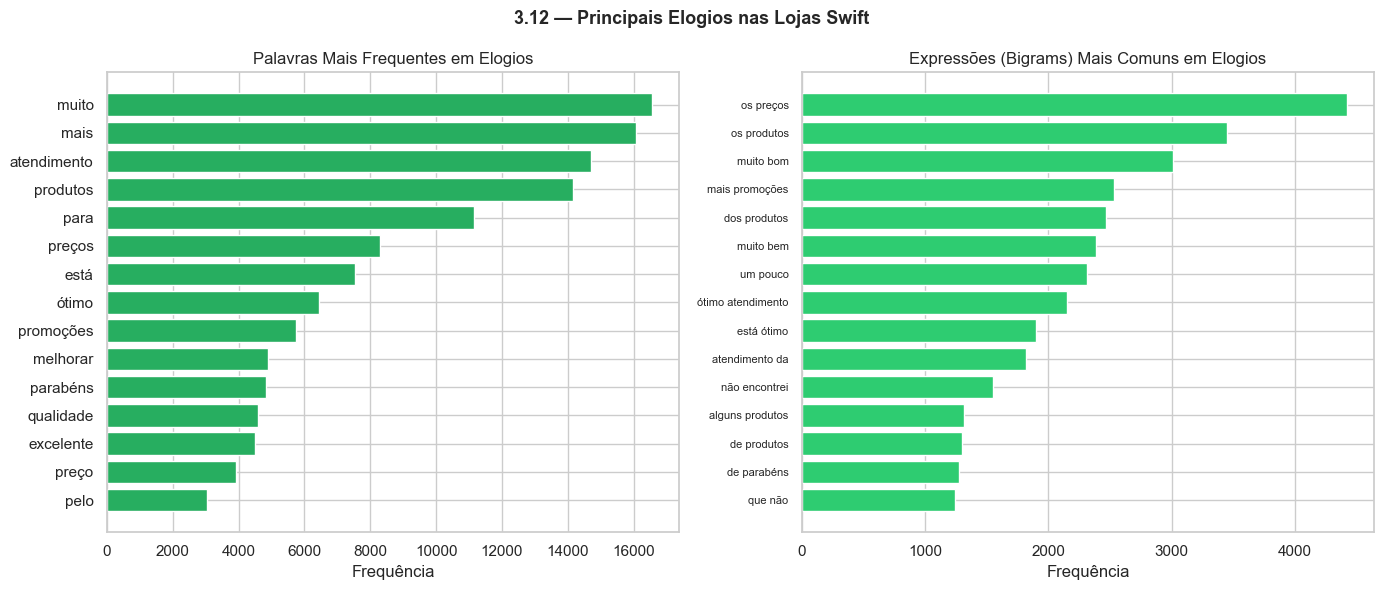

In [ ]:
# ── 3.12.3 — Visualização: Word Frequency dos Elogios ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('3.12 — Principais Elogios nas Lojas Swift', fontweight='bold', fontsize=13)

# Top 15 palavras
top_words = word_freq[:15]
words_list = [w for w, _ in top_words]
freqs_list = [f for _, f in top_words]
axes[0].barh(range(len(words_list)), freqs_list, color='#27ae60', edgecolor='white')
axes[0].set_yticks(range(len(words_list)))
axes[0].set_yticklabels(words_list)
axes[0].set_xlabel('Frequência')
axes[0].set_title('Palavras Mais Frequentes em Elogios')
axes[0].invert_yaxis()

# Top 15 bigrams
top_bi = bigram_freq[:15]
bi_labels = [b for b, _ in top_bi]
bi_freqs = [f for _, f in top_bi]
axes[1].barh(range(len(bi_labels)), bi_freqs, color='#2ecc71', edgecolor='white')
axes[1].set_yticks(range(len(bi_labels)))
axes[1].set_yticklabels(bi_labels, fontsize=8)
axes[1].set_xlabel('Frequência')
axes[1].set_title('Expressões (Bigrams) Mais Comuns em Elogios')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

ELOGIOS POR ÁREA TEMÁTICA

  ABASTECIMENTO (9,159 elogios):
    "alguns produtos" — 1,033x
    "os produtos" — 638x
    "dos produtos" — 470x
    "um pouco" — 460x
    "de produtos" — 400x

  ATENDIMENTO (13,866 elogios):
    "muito bem" — 977x
    "bem atendida" — 888x
    "os produtos" — 846x
    "de parabéns" — 466x
    "os funcionários" — 453x

  ENTREGA_LOGISTICA (6,568 elogios):
    "está ótimo" — 967x
    "pra mim" — 935x
    "mim está" — 814x
    "para mim" — 459x
    "de frango" — 390x

  LOJA_FISICA (13,617 elogios):
    "ótimo atendimento" — 1,918x
    "muito bom" — 1,205x
    "atendimento da" — 1,011x
    "muito bem" — 927x
    "não encontrei" — 788x

  PRODUTO (10,456 elogios):
    "muito bom" — 763x
    "está perfeito" — 503x
    "de parabéns" — 413x
    "mais ofertas" — 395x
    "não precisa" — 392x

  PROMOCOES_FIDELIDADE (14,543 elogios):
    "os preços" — 3,193x
    "mais promoções" — 1,537x
    "um pouco" — 1,124x
    "os produtos" — 773x
    "excelente atendimento" 

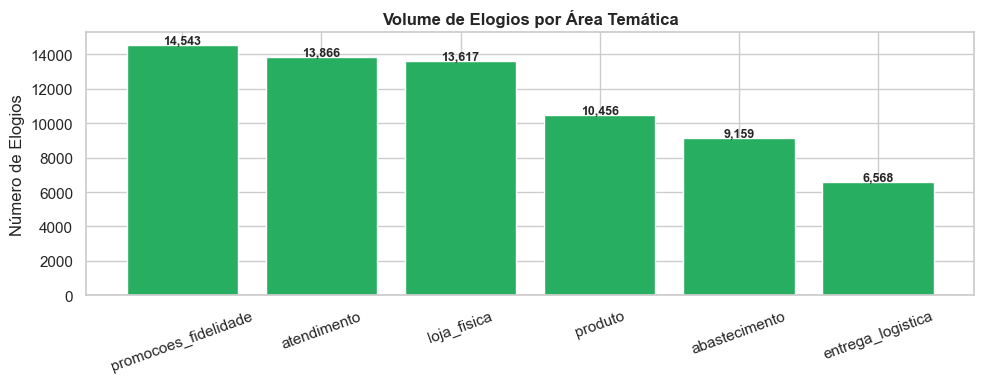

In [ ]:
# ── 3.12.4 — Elogios por Área Temática ──────────────────────────────────────
# Integrar com categorias da clusterização (se disponível)
from pathlib import Path

print('ELOGIOS POR ÁREA TEMÁTICA')
print('='*70)

# Tentar carregar categorias do notebook de clusterização
topicos_path = Path('data/df_topicos_atribuidos.csv')
if topicos_path.exists():
    df_topicos = pd.read_csv(topicos_path, sep=';', encoding='utf-8-sig',
                             usecols=['comentario', 'categoria'])
    df_topicos = df_topicos.drop_duplicates('comentario')
    
    # Merge com positivos
    df_pos_cat = df_positivos.merge(df_topicos, on='comentario', how='left')
    df_pos_cat['categoria'] = df_pos_cat['categoria'].fillna('sem_categoria')
    
    # Top elogios por categoria
    categorias_validas = [c for c in df_pos_cat['categoria'].unique() 
                          if c not in ['outros', 'sem_categoria']]
    
    for cat in sorted(categorias_validas):
        sub = df_pos_cat[df_pos_cat['categoria'] == cat]
        if len(sub) < 50:
            continue
        
        # Top bigrams desta categoria
        vec_cat = CountVectorizer(ngram_range=(2, 2), max_features=100, min_df=3,
                                  stop_words=list(stop_extra))
        try:
            X_cat = vec_cat.fit_transform(sub['comentario_limpo'].dropna().astype(str))
            cat_bigrams = list(zip(vec_cat.get_feature_names_out(), X_cat.sum(axis=0).A1))
            cat_bigrams.sort(key=lambda x: -x[1])
            
            print(f'\n  {cat.upper()} ({len(sub):,} elogios):')
            for bigram, freq in cat_bigrams[:5]:
                print(f'    "{bigram}" — {int(freq):,}x')
        except ValueError:
            print(f'\n  {cat.upper()}: poucos dados para extrair bigrams')
    
    # Gráfico: volume de elogios por categoria
    elogios_por_cat = df_pos_cat['categoria'].value_counts()
    elogios_por_cat = elogios_por_cat[~elogios_por_cat.index.isin(['outros', 'sem_categoria'])]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(elogios_por_cat.index, elogios_por_cat.values, color='#27ae60', edgecolor='white')
    for bar, val in zip(bars, elogios_por_cat.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+50, f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel('Número de Elogios')
    ax.set_title('Volume de Elogios por Área Temática', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
    
else:
    print('[AVISO] data/df_topicos_atribuidos.csv não encontrado.')
    print('Execute o notebook de Clusterização antes para análise por área.')
    print('Continuando com análise geral (sem categorias).')

In [ ]:
# ── 3.12.5 — Exemplos Reais de Elogios Representativos ───────────────────────
print('EXEMPLOS REAIS DE ELOGIOS REPRESENTATIVOS')
print('='*70)

# Selecionar elogios com alta confiança (palavras muito positivas)
ELOGIOS_FORTES = ['excelente', 'maravilhoso', 'perfeito', 'incrivel', 'fantastico',
                  'adorei', 'amei', 'parabens', 'recomendo', 'melhor']

def score_elogio(texto):
    t = str(texto).lower()
    return sum(1 for p in ELOGIOS_FORTES if p in t)

df_positivos_rep = df_positivos.copy()
df_positivos_rep['score_elogio'] = df_positivos_rep['comentario'].apply(score_elogio)

# Filtrar elogios com mais substância (>= 8 palavras e score >= 2)
bons_elogios = df_positivos_rep[
    (df_positivos_rep['qtd_palavras'] >= 8) & 
    (df_positivos_rep['score_elogio'] >= 2)
].sort_values('score_elogio', ascending=False)

print(f'Elogios com alta intensidade (≥2 termos fortes, ≥8 palavras): {len(bons_elogios):,}')
print()

# Amostra diversificada (diferentes lojas)
exemplos = bons_elogios.drop_duplicates('centro_nv2').head(10)
for i, (_, row) in enumerate(exemplos.iterrows(), 1):
    loja = row['centro_nv2'].split('-')[1].split('(')[0].strip() if '-' in row['centro_nv2'] else row['centro_nv2'][:20]
    print(f'  {i:2d}. [{loja}]')
    print(f'      "{str(row["comentario"])[:150]}"')
    print()

EXEMPLOS REAIS DE ELOGIOS REPRESENTATIVOS
Elogios com alta intensidade (≥2 termos fortes, ≥8 palavras): 1,202

   1. [CAJAMAR]
      "A experiência que teve foi excelente preço que cabe no bolso e melhor de tudo parcela amei super recomendo"

   2. [ROLAND GARROS]
      "Não precisam melhorar. A loja é excelente, encontro tudo o que eu preciso. O atendimento é perfeito por parte de todos, sem exceção! Super recomendo a"

   3. [SAO LOURENCO]
      "Não tem o que melhorar está tudo perfeito,os atendentes são maravilhosos, principalmente a atendente Elisama simpática,educada,atenciosa sempre dispos"

   4. [SUZANO]
      "Não tem o que melhorar esta perfeito, todas as vezes que fiz minhas compras on line sempre chegou no prazo e horário marcado .
Parabéns a toda a equip"

   5. [BOQUEIRAO]
      "Está tudo perfeito si melhorar estragar  rsrs tá ótimo maravilhoso amo comprar ai"

   6. [AUTONOMISTAS]
      "Adorei e recomendo  . A qualidade dos produtos é excelente  entrega rápida e a com

In [ ]:
# ── 3.12.6 — Resumo dos Principais Elogios ──────────────────────────────────
print('SÍNTESE — PRINCIPAIS ELOGIOS NAS LOJAS SWIFT')
print('='*70)
print()
print('Os comentários positivos (que representam a maioria da base)')
print('concentram-se nos seguintes temas:')
print()

# Agrupar bigrams por tema manualmente baseado nas palavras-chave
temas_elogio = {
    'Atendimento': ['atendimento', 'atendente', 'funcionario', 'educad', 'simpatico', 'prestativ'],
    'Qualidade dos Produtos': ['qualidade', 'carne', 'produto', 'fresco', 'sabor', 'otima'],
    'Experiência na Loja': ['ambiente', 'organiz', 'limp', 'espaco', 'bonit'],
    'Variedade': ['variedade', 'opcoes', 'opcao', 'diversidade'],
    'Preço/Promoção': ['preco', 'promocao', 'desconto', 'custo', 'barato'],
}

for tema, keywords in temas_elogio.items():
    # Contar quantos elogios mencionam esse tema
    mask = df_positivos['comentario_limpo'].apply(
        lambda t: any(k in str(t).lower() for k in keywords)
    )
    n = mask.sum()
    pct = 100 * n / len(df_positivos)
    
    # Top exemplo
    exemplos_tema = df_positivos[mask]['comentario'].dropna()
    exemplo = str(exemplos_tema.iloc[0])[:100] if len(exemplos_tema) > 0 else '-'
    
    print(f'  {tema}')
    print(f'    Menções: {n:,} ({pct:.1f}% dos elogios)')
    print(f'    Exemplo: "{exemplo}"')
    print()

print('='*70)
print('[CONCLUSÃO] Os clientes da Swift elogiam principalmente:')
print('  1. A qualidade das carnes e produtos')
print('  2. O atendimento dos funcionários')
print('  3. A organização e limpeza das lojas')
print('  4. A variedade de opções disponíveis')

SÍNTESE — PRINCIPAIS ELOGIOS NAS LOJAS SWIFT

Os comentários positivos (que representam a maioria da base)
concentram-se nos seguintes temas:

  Atendimento
    Menções: 18,700 (21.9% dos elogios)
    Exemplo: "Perfeito, com um atendimento diferenciado ! ????"

  Qualidade dos Produtos
    Menções: 19,625 (23.0% dos elogios)
    Exemplo: "Alguns produtos com porções menores."

  Experiência na Loja
    Menções: 2,969 (3.5% dos elogios)
    Exemplo: "Mantendo o estilo e conservação do ambiente"

  Variedade
    Menções: 1,490 (1.7% dos elogios)
    Exemplo: "Só ñ goste desse negócio de combo,ficou ruim pra mim,que sou só, ñ preciso de tanto,gosto de mais va"

  Preço/Promoção
    Menções: 3,467 (4.1% dos elogios)
    Exemplo: "colocar um preço mais barato para eu poder comprar mais
"

[CONCLUSÃO] Os clientes da Swift elogiam principalmente:
  1. A qualidade das carnes e produtos
  2. O atendimento dos funcionários
  3. A organização e limpeza das lojas
  4. A variedade de opções disponí

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.10 — Exportação dos Resultados</h2>
</div>

In [ ]:
# ── Exportar base com sentimento predito ────────────────────────────────────
import joblib

# Salvar componentes do ensemble (wrapper não é serializável diretamente)
ensemble_components = {
    'lr': lr,
    'svc': svc,
    'lgbm': lgbm,
    'tfidf_word': tfidf_word,
    'tfidf_char': tfidf_char,
    'le': le,
    'weights': {'lr': w_lr, 'svc': w_svc, 'lgbm': w_lgbm},
    'classes': lr.classes_,
}
joblib.dump(ensemble_components, 'data/modelo_sentimento.joblib')
print('[OK] Modelo salvo: data/modelo_sentimento.joblib')

# Exportar dataframe com sentimento
df_export = df_sent[[
    'centro_nv2', 'classificacao', 'flag', 'data_avaliacao',
    'comentario', 'comentario_limpo', 'sentimento', 'sentimento_pred',
    'qtd_palavras'
]].copy()

df_export.to_csv('data/df_sentimento.csv', sep=';', index=False, encoding='utf-8-sig')
print(f'[OK] data/df_sentimento.csv exportado ({len(df_export):,} registros)')
print()
print('Colunas exportadas:')
for col in df_export.columns:
    print(f'  {col}')
print()
print('Próximos passos:')
print('  1. Integrar sentimento com categorias (notebook de Clusterização)')
print('  2. Criar dashboards: sentimento × categoria × flag × mês')
print('  3. Identificar lojas com sentimento negativo crescente')

[OK] Modelo salvo: data/modelo_sentimento.joblib
[OK] data/df_sentimento.csv exportado (116,605 registros)

Colunas exportadas:
  centro_nv2
  classificacao
  flag
  data_avaliacao
  comentario
  comentario_limpo
  sentimento
  sentimento_pred
  qtd_palavras

Próximos passos:
  1. Integrar sentimento com categorias (notebook de Clusterização)
  2. Criar dashboards: sentimento × categoria × flag × mês
  3. Identificar lojas com sentimento negativo crescente


In [ ]:
# ── Consolidar base_inferencia_completa.csv ──────────────────────────────────
# Requisito 1.3 da Entrega 2: base única com sentimento + categoria + confiança + flag
# Merge: df_sentimento (116k comentários com sentimento_pred) + df_topicos (com categoria)

from pathlib import Path

print('CONSOLIDANDO BASE DE INFERÊNCIA COMPLETA')
print('='*70)

# Carregar categorias geradas pela clusterização
topicos_path = Path('data/df_topicos_atribuidos.csv')
if topicos_path.exists():
    df_topicos = pd.read_csv(topicos_path, sep=';', encoding='utf-8-sig')
    print(f'Categorias carregadas: {len(df_topicos):,} registros')
    print(f'Colunas: {list(df_topicos.columns)}')

    # Merge por comentario (chave natural — comentario_limpo pode variar)
    # Usar centro_nv2 + comentario como chave composta
    merge_cols = ['centro_nv2', 'comentario']
    df_infere = df_export.copy()

    if all(c in df_topicos.columns for c in merge_cols):
        df_topicos_merge = df_topicos[merge_cols + ['categoria', 'confianca']].drop_duplicates(subset=merge_cols)
        df_infere = df_infere.merge(df_topicos_merge, on=merge_cols, how='left')
        n_com_cat = df_infere['categoria'].notna().sum()
        print(f'Com categoria atribuída : {n_com_cat:,} ({100*n_com_cat/len(df_infere):.1f}%)')
    else:
        df_infere['categoria'] = None
        df_infere['confianca'] = None
        print('[AVISO] Colunas de merge não encontradas — categoria não integrada')

    # Flag de baixa confiança
    if 'confianca' in df_infere.columns:
        df_infere['flag_baixa_confianca'] = df_infere['confianca'].fillna(0) < 0.35

    df_infere.to_csv('data/base_inferencia_completa.csv', sep=';', index=False, encoding='utf-8-sig')
    print(f'\n[OK] data/base_inferencia_completa.csv exportado')
    print(f'     {len(df_infere):,} registros | colunas: {list(df_infere.columns)}')
else:
    print('[AVISO] df_topicos_atribuidos.csv não encontrado.')
    print('Execute a PARTE 3 (Clusterização) antes desta célula.')
    df_export.to_csv('data/base_inferencia_completa.csv', sep=';', index=False, encoding='utf-8-sig')
    print(f'[OK] Exportado sem categorias: {len(df_export):,} registros')


CONSOLIDANDO BASE DE INFERÊNCIA COMPLETA
Categorias carregadas: 127,866 registros
Colunas: ['centro_nv2', 'classificacao', 'flag', 'data_avaliacao', 'comentario', 'topico_id', 'confianca', 'categoria']
Com categoria atribuída : 116,596 (100.0%)

[OK] data/base_inferencia_completa.csv exportado
     116,605 registros | colunas: ['centro_nv2', 'classificacao', 'flag', 'data_avaliacao', 'comentario', 'comentario_limpo', 'sentimento', 'sentimento_pred', 'qtd_palavras', 'categoria', 'confianca', 'flag_baixa_confianca']


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:8px solid #7e2200;color:white;padding:16px 24px;border-radius:10px;font-family:'Segoe UI',sans-serif;font-size:20px;font-weight:bold;letter-spacing:1px;margin:24px 0 8px 0;box-shadow:0px 3px 8px rgba(226,67,7,0.3);">PARTE 5 — NPS AJUSTADO</div>

<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;margin:16px 0 6px 0;">
NOVO CÁLCULO DE NPS COM INCORPORAÇÃO DO COMENTÁRIO
</div>

<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">1. Importações e Carregamento</h2>
</div>

In [ ]:
import os, warnings
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
COR_SWIFT = '#E24307'
CORES_SENT = {'positivo': '#27ae60', 'neutro': '#f39c12', 'negativo': '#c0392b'}

print('[OK] Imports OK')

[OK] Imports OK


In [ ]:
# Carregar base com sentimento predito
# Gerada por Analise_Sentimento_Swift.ipynb (seção 3.10)
sent_path = Path('data/df_sentimento.csv')
if not sent_path.exists():
    raise FileNotFoundError(
        "data/df_sentimento.csv não encontrada.\n"
        "Execute as células da PARTE 4 (Análise de Sentimento) antes desta seção."
    )

df_sent = pd.read_csv(sent_path, sep=';', encoding='utf-8-sig')
df_sent['data_avaliacao'] = pd.to_datetime(df_sent['data_avaliacao'], errors='coerce')
df_sent['flag'] = df_sent['flag'].str.upper().str.strip()

# Carregar base completa (para ter todos os registros, inclusive sem comentário)
df_base = pd.read_csv('data/base_final.csv', sep=';', encoding='utf-8')
df_base['data_avaliacao'] = pd.to_datetime(df_base['data_avaliacao'], errors='coerce')
df_base['flag'] = df_base['flag'].str.upper().str.strip()

print(f'Base completa        : {len(df_base):,} registros')
print(f'Com sentimento predito: {len(df_sent):,} registros')
print(f'\nColunas disponíveis (sentimento): {list(df_sent.columns)}')

Base completa        : 239,143 registros
Com sentimento predito: 116,605 registros

Colunas disponíveis (sentimento): ['centro_nv2', 'classificacao', 'flag', 'data_avaliacao', 'comentario', 'comentario_limpo', 'sentimento', 'sentimento_pred', 'qtd_palavras']


<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">2. NPS Tradicional — Linha de Base</h2>
</div>

**O NPS tradicional:** `(% Promotores − % Detratores) × 100`
Calculado **apenas** pela nota numérica do cliente — ignora completamente o texto do comentário.
Esta seção documenta o NPS tradicional que será comparado com o NPS ajustado.

In [ ]:
# NPS Tradicional por loja
def calcular_nps(grupo):
    total = grupo['qtd_clientes'].sum()
    if total == 0:
        return np.nan
    prom = grupo.loc[grupo['classificacao'] == 'promotor', 'qtd_clientes'].sum()
    detr = grupo.loc[grupo['classificacao'] == 'detrator', 'qtd_clientes'].sum()
    return (prom - detr) / total * 100

nps_trad_loja = (
    df_base.groupby('centro_nv2')
    .apply(calcular_nps)
    .rename('nps_tradicional')
    .reset_index()
)

# NPS tradicional geral
total_geral = df_base['qtd_clientes'].sum()
prom_geral  = df_base.loc[df_base['classificacao']=='promotor','qtd_clientes'].sum()
detr_geral  = df_base.loc[df_base['classificacao']=='detrator','qtd_clientes'].sum()
nps_geral   = (prom_geral - detr_geral) / total_geral * 100

print('NPS TRADICIONAL')
print('='*70)
print(f'  NPS Geral (toda a rede): {nps_geral:.1f}')
print(f'  Lojas calculadas       : {len(nps_trad_loja)}')
print(f'  NPS médio por loja     : {nps_trad_loja["nps_tradicional"].mean():.1f}')
print(f'  Melhor loja            : {nps_trad_loja["nps_tradicional"].max():.1f}')
print(f'  Pior loja              : {nps_trad_loja["nps_tradicional"].min():.1f}')

NPS TRADICIONAL
  NPS Geral (toda a rede): 87.6
  Lojas calculadas       : 227
  NPS médio por loja     : 87.4
  Melhor loja            : 94.7
  Pior loja              : 76.3


<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">3. Divergências: Nota NPS vs Sentimento do Comentário</h2>
</div>

**Requisito 2.2 do enunciado:** apresentar o percentual de avaliações onde a nota e o sentimento divergem,
e os casos mais extremos.

Uma divergência ocorre quando:
- Cliente deu nota de **promotor** (9-10) mas o comentário expressa sentimento **negativo**
- Cliente deu nota de **detrator** (1-6) mas o comentário expressa sentimento **positivo**

In [ ]:
# Mapeamento classificação NPS → sentimento esperado
MAPA_ESPERADO = {'promotor': 'positivo', 'neutro': 'neutro', 'detrator': 'negativo'}
df_sent['sentimento_esperado'] = df_sent['classificacao'].map(MAPA_ESPERADO)

# Classificar tipo de divergência
def tipo_divergencia(row):
    real = row['sentimento_esperado']
    pred = row['sentimento_pred']
    if real == pred:
        return 'concordante'
    if real == 'positivo' and pred == 'negativo':
        return 'promotor_negativo'   # mais crítico
    if real == 'negativo' and pred == 'positivo':
        return 'detrator_positivo'   # também crítico
    return 'divergente_parcial'      # neutro confundido

df_sent['tipo_divergencia'] = df_sent.apply(tipo_divergencia, axis=1)

total_com_com = len(df_sent)
concordantes  = (df_sent['tipo_divergencia'] == 'concordante').sum()
diverg_total  = total_com_com - concordantes

print('ANÁLISE DE DIVERGÊNCIAS: NOTA vs SENTIMENTO DO COMENTÁRIO')
print('='*70)
print(f'Total com comentário analisado : {total_com_com:,}')
print(f'Concordantes (nota ≈ sentimento): {concordantes:,}  ({100*concordantes/total_com_com:.1f}%)')
print(f'Divergentes (nota ≠ sentimento) : {diverg_total:,}  ({100*diverg_total/total_com_com:.1f}%)')
print()
print('Tipos de divergência:')
for tipo, n in df_sent['tipo_divergencia'].value_counts().items():
    print(f'  {tipo:<30}: {n:>6,}  ({100*n/total_com_com:.1f}%)')

ANÁLISE DE DIVERGÊNCIAS: NOTA vs SENTIMENTO DO COMENTÁRIO
Total com comentário analisado : 116,605
Concordantes (nota ≈ sentimento): 101,130  (86.7%)
Divergentes (nota ≠ sentimento) : 15,475  (13.3%)

Tipos de divergência:
  concordante                   : 101,130  (86.7%)
  divergente_parcial            : 11,826  (10.1%)
  promotor_negativo             :  2,674  (2.3%)
  detrator_positivo             :    975  (0.8%)


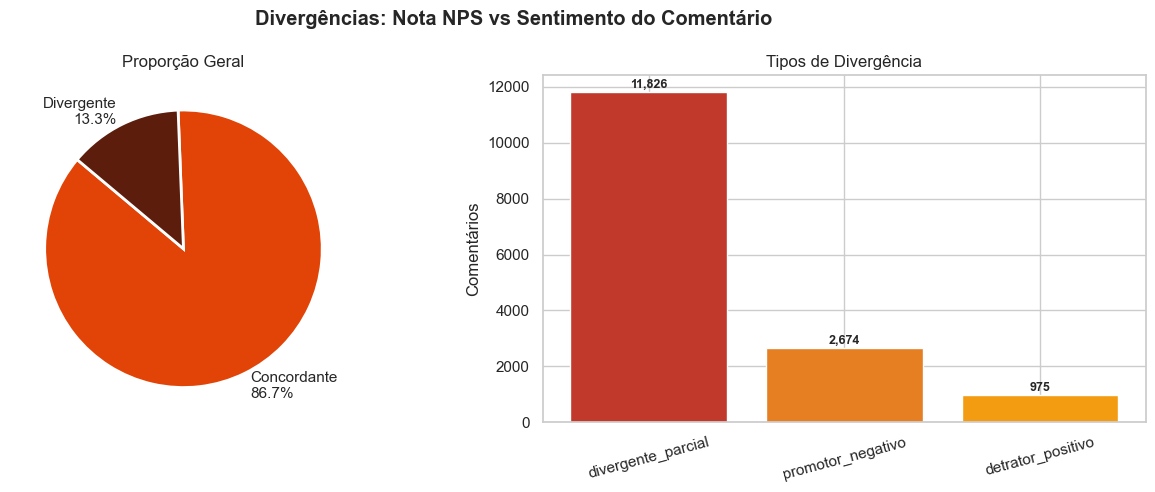


CASOS EXTREMOS — Promotor com Texto Negativo:
  "Parar de vender carne com colageno, acaba com produto da Swift."
  "A única coisa, é acabar com essa carne com colágeno, cheira muito mau e tem sabor horrível. Acredito que já perderam mui"
  "Colocando os preços corretos em cada produto, pois o produto em que comprei estava com preço trocado ao do sistema!!!"
  "Os produtos que faltaram não d sua fabricação."
  "Melhorando os cortes dos bifes de contra filé. Estava vindo muito retalho. Não comprei mais, faço o no açougue onde vejo"

CASOS EXTREMOS — Detrator com Texto Positivo:
  "Os preços estão acima do praticado no mercado.
Esse é o único ponto negativo da rede como um todo."
  "muito bom e prático"
  "Mantendo produtos somente da Swift nas geladeiras. Comprei meio da asa temperada da Copacol e não gostei da qualidade."
  "Comecem acertando o meu nome algum dia"
  "Proporcionando preços compatíveis com nossa realidade. A dolarizacao dos produtos proíbe nosso acesso"


In [ ]:
# Visualização das divergências
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Divergências: Nota NPS vs Sentimento do Comentário', fontweight='bold')

# Pizza: concordante vs divergente
vals = [concordantes, diverg_total]
labels = [f'Concordante\n{100*concordantes/total_com_com:.1f}%',
          f'Divergente\n{100*diverg_total/total_com_com:.1f}%']
axes[0].pie(vals, labels=labels, colors=[COR_SWIFT, '#5c1d0c'],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Proporção Geral')

# Barras: tipos de divergência
tipos_div = df_sent[df_sent['tipo_divergencia'] != 'concordante']['tipo_divergencia'].value_counts()
cores_div = ['#c0392b', '#e67e22', '#f39c12']
bars = axes[1].bar(tipos_div.index, tipos_div.values, color=cores_div[:len(tipos_div)], edgecolor='white')
for bar, val in zip(bars, tipos_div.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+20, f'{val:,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Comentários')
axes[1].set_title('Tipos de Divergência')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Exemplos de casos extremos
print('\nCASOS EXTREMOS — Promotor com Texto Negativo:')
casos_pn = df_sent[df_sent['tipo_divergencia'] == 'promotor_negativo']
for _, row in casos_pn.head(5).iterrows():
    print(f'  "{str(row["comentario"])[:120]}"')

print('\nCASOS EXTREMOS — Detrator com Texto Positivo:')
casos_dp = df_sent[df_sent['tipo_divergencia'] == 'detrator_positivo']
for _, row in casos_dp.head(5).iterrows():
    print(f'  "{str(row["comentario"])[:120]}"')

<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">4. Proposta de NPS Ajustado</h2>
</div>

## Abordagem Escolhida: NPS Híbrido com Penalização

**Justificativa da escolha:**
A base apresenta ~99% de concordância entre nota e texto — as divergências são minoria.
Isso indica que a nota NPS já é um bom indicador. Portanto, não faz sentido substituí-la,
mas sim **ajustar o peso de casos discordantes**.

### Fórmula proposta:

**Passo 1 — Reclassificação dos casos extremos:**
- `promotor` com sentimento `negativo` → reclassificado como `neutro` no cálculo (rebaixamento)
- `detrator` com sentimento `positivo` → reclassificado como `neutro` no cálculo (elevação)
- Demais casos: mantidos como estão

**Passo 2 — NPS calculado com as classificações ajustadas:**
```
NPS_ajustado = (% Promotores_ajustados − % Detratores_ajustados) × 100
```

**Por que não usamos a fórmula híbrida ponderada (0.7 × NPS + 0.3 × Sentiment)?**
Porque esse modelo exige normalizar o score de sentimento para a mesma escala do NPS,
o que introduz arbitrariedade nos pesos. A reclassificação é mais transparente e
diretamente interpretável para a equipe de operações.

**Limitação conhecida:** comentários sem texto (47% da base) não são ajustados
— mantêm a nota original. O NPS ajustado é mais conservador que uma abordagem total.

In [ ]:
# ── Aplicar reclassificação ─────────────────────────────────────────────────
df_sent['classificacao_ajustada'] = df_sent['classificacao'].copy()

# Rebaixar: promotor com sentimento negativo → neutro
mask_rebaixar = df_sent['tipo_divergencia'] == 'promotor_negativo'
df_sent.loc[mask_rebaixar, 'classificacao_ajustada'] = 'neutro'

# Elevar: detrator com sentimento positivo → neutro
mask_elevar = df_sent['tipo_divergencia'] == 'detrator_positivo'
df_sent.loc[mask_elevar, 'classificacao_ajustada'] = 'neutro'

n_rebaixados = mask_rebaixar.sum()
n_elevados   = mask_elevar.sum()

print('RECLASSIFICAÇÕES APLICADAS')
print('='*70)
print(f'  Promotores rebaixados para neutro: {n_rebaixados:,}')
print(f'  Detratores elevados para neutro  : {n_elevados:,}')
print(f'  Total alterações                 : {n_rebaixados + n_elevados:,}')
print(f'  % da base com comentário         : {100*(n_rebaixados+n_elevados)/total_com_com:.2f}%')

RECLASSIFICAÇÕES APLICADAS
  Promotores rebaixados para neutro: 2,674
  Detratores elevados para neutro  : 975
  Total alterações                 : 3,649
  % da base com comentário         : 3.13%


In [ ]:
# ── NPS Ajustado por Loja ────────────────────────────────────────────────────
# Merge: base completa + classificação ajustada (apenas para registros com comentário)
df_base_merge = df_base.copy()
df_base_merge = df_base_merge.merge(
    df_sent[['centro_nv2','data_avaliacao','comentario','classificacao_ajustada']],
    on=['centro_nv2','data_avaliacao','comentario'],
    how='left'
)
# Onde não tem classificação ajustada (sem comentário), usar a original
df_base_merge['classificacao_final'] = df_base_merge['classificacao_ajustada'].fillna(
    df_base_merge['classificacao']
)

# NPS ajustado por loja
def calcular_nps_col(grupo, col_class):
    total = grupo['qtd_clientes'].sum()
    if total == 0: return np.nan
    prom = grupo.loc[grupo[col_class] == 'promotor', 'qtd_clientes'].sum()
    detr = grupo.loc[grupo[col_class] == 'detrator', 'qtd_clientes'].sum()
    return (prom - detr) / total * 100

nps_ajust_loja = (
    df_base_merge.groupby('centro_nv2')
    .apply(lambda g: calcular_nps_col(g, 'classificacao_final'))
    .rename('nps_ajustado')
    .reset_index()
)

# Juntar tradicional + ajustado
df_nps_comp = nps_trad_loja.merge(nps_ajust_loja, on='centro_nv2')
df_nps_comp['delta'] = df_nps_comp['nps_ajustado'] - df_nps_comp['nps_tradicional']

# NPS ajustado geral
total_g = df_base_merge['qtd_clientes'].sum()
prom_g  = df_base_merge.loc[df_base_merge['classificacao_final']=='promotor','qtd_clientes'].sum()
detr_g  = df_base_merge.loc[df_base_merge['classificacao_final']=='detrator','qtd_clientes'].sum()
nps_ajust_geral = (prom_g - detr_g) / total_g * 100

print('NPS TRADICIONAL vs AJUSTADO')
print('='*70)
print(f'  NPS Tradicional (rede) : {nps_geral:.2f}')
print(f'  NPS Ajustado (rede)    : {nps_ajust_geral:.2f}')
print(f'  Variação               : {nps_ajust_geral - nps_geral:+.2f} pontos')
print()
print(f'  Lojas com NPS que subiu : {(df_nps_comp["delta"] > 0).sum()}')
print(f'  Lojas com NPS que caiu  : {(df_nps_comp["delta"] < 0).sum()}')
print(f'  Lojas sem alteração     : {(df_nps_comp["delta"] == 0).sum()}')

NPS TRADICIONAL vs AJUSTADO
  NPS Tradicional (rede) : 87.59
  NPS Ajustado (rede)    : 87.24
  Variação               : -0.35 pontos

  Lojas com NPS que subiu : 11
  Lojas com NPS que caiu  : 210
  Lojas sem alteração     : 6


<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">5. Análise de Impacto do Novo Cálculo</h2>
</div>

In [ ]:
# ── 5.1 — Quantas lojas mudam de faixa? ─────────────────────────────────────
def faixa_nps(nps):
    if pd.isna(nps): return 'sem_dados'
    if nps >= 75:  return 'Excelente (≥75)'
    if nps >= 50:  return 'Bom (50-74)'
    if nps >= 0:   return 'Neutro (0-49)'
    return 'Crítico (<0)'

df_nps_comp['faixa_trad']  = df_nps_comp['nps_tradicional'].apply(faixa_nps)
df_nps_comp['faixa_ajust'] = df_nps_comp['nps_ajustado'].apply(faixa_nps)
df_nps_comp['mudou_faixa'] = df_nps_comp['faixa_trad'] != df_nps_comp['faixa_ajust']

print('IMPACTO NAS FAIXAS DE NPS POR LOJA')
print('='*70)
print(f'  Lojas que mudaram de faixa: {df_nps_comp["mudou_faixa"].sum()} de {len(df_nps_comp)}')
print()

mudancas = df_nps_comp[df_nps_comp['mudou_faixa']][['centro_nv2','nps_tradicional','nps_ajustado','faixa_trad','faixa_ajust','delta']]
if len(mudancas) > 0:
    print('Lojas que mudaram de faixa:')
    display(mudancas.sort_values('delta').style.hide(axis='index')
            .background_gradient(subset=['delta'], cmap='RdYlGn', vmin=-10, vmax=10)
            .set_caption('Mudanças de Faixa com NPS Ajustado'))
else:
    print('[OK] Nenhuma loja mudou de faixa — ajuste é conservador e consistente.')

print()
print('Distribuição de faixas:')
faixas_comp = pd.DataFrame({
    'Tradicional': df_nps_comp['faixa_trad'].value_counts(),
    'Ajustado':    df_nps_comp['faixa_ajust'].value_counts()
}).fillna(0).astype(int)
print(faixas_comp.to_string())

IMPACTO NAS FAIXAS DE NPS POR LOJA
  Lojas que mudaram de faixa: 0 de 227

[OK] Nenhuma loja mudou de faixa — ajuste é conservador e consistente.

Distribuição de faixas:
                 Tradicional  Ajustado
Excelente (≥75)          227       227


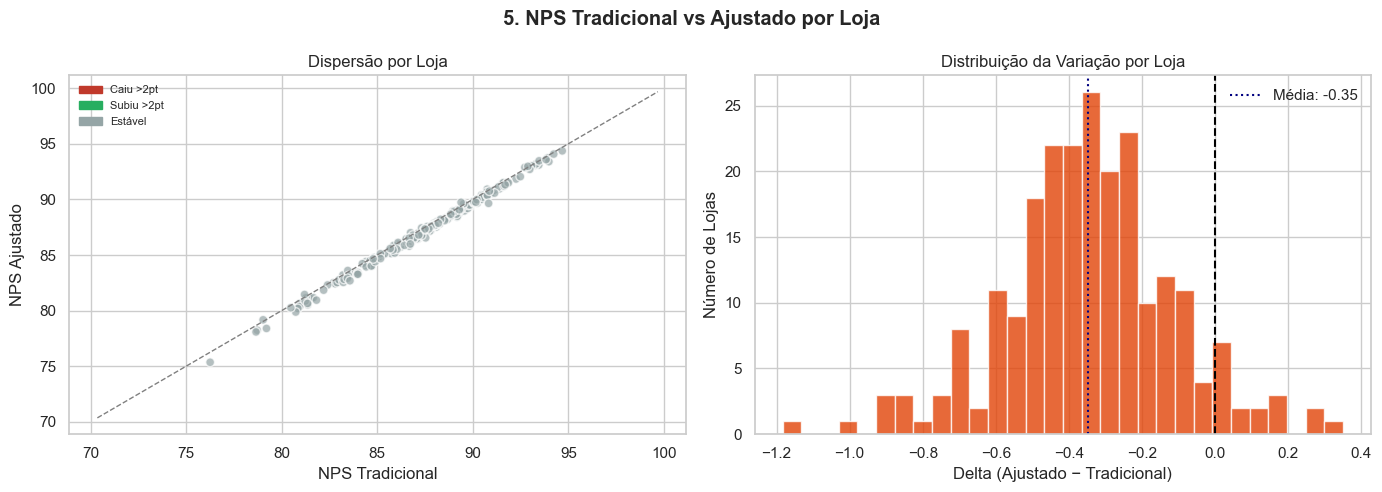

In [ ]:
# ── 5.2 — Visualização: NPS Tradicional vs Ajustado por loja ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5. NPS Tradicional vs Ajustado por Loja', fontweight='bold')

# Scatter: trad vs ajustado
cores_delta = ['#c0392b' if d < -2 else '#27ae60' if d > 2 else '#95a5a6' for d in df_nps_comp['delta']]
axes[0].scatter(df_nps_comp['nps_tradicional'], df_nps_comp['nps_ajustado'],
                c=cores_delta, alpha=0.7, s=40, edgecolors='white')
lim_min = min(df_nps_comp[['nps_tradicional','nps_ajustado']].min()) - 5
lim_max = max(df_nps_comp[['nps_tradicional','nps_ajustado']].max()) + 5
axes[0].plot([lim_min,lim_max],[lim_min,lim_max], '--', color='gray', linewidth=1, label='Sem alteração')
axes[0].set_xlabel('NPS Tradicional')
axes[0].set_ylabel('NPS Ajustado')
axes[0].set_title('Dispersão por Loja')
legend_els = [mpatches.Patch(color='#c0392b', label='Caiu >2pt'),
              mpatches.Patch(color='#27ae60', label='Subiu >2pt'),
              mpatches.Patch(color='#95a5a6', label='Estável')]
axes[0].legend(handles=legend_els, fontsize=8)

# Histograma do delta
axes[1].hist(df_nps_comp['delta'].dropna(), bins=30, color=COR_SWIFT, edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(df_nps_comp['delta'].mean(), color='navy', linestyle=':', label=f'Média: {df_nps_comp["delta"].mean():.2f}')
axes[1].set_xlabel('Delta (Ajustado − Tradicional)')
axes[1].set_ylabel('Número de Lojas')
axes[1].set_title('Distribuição da Variação por Loja')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── 5.3 — Análise crítica ────────────────────────────────────────────────────
print('ANÁLISE CRÍTICA DO NPS AJUSTADO')
print('='*70)
print()
print('QUANDO O NOVO CÁLCULO É MAIS JUSTO:')
print('  - Promotores que reclamaram de algo específico mas ainda indicariam a loja')
print('    têm peso reduzido, evitando inflação do NPS em lojas com problemas reais.')
print('  - Detratores que elogiaram aspecto positivo (ex: produto bom mas entrega ruim)')
print('    não penalizam excessivamente lojas com NPS textual neutro.')
print()
print('SITUAÇÕES EM QUE O NOVO CÁLCULO PODE ESTAR ERRADO:')
print('  1. Comentários irônicos: "Ótima ideia cobrar pelo estacionamento!" pode')
print('     ser classificado como positivo pelo modelo, elevando indevidamente um detrator.')
print('  2. Textos muito curtos (< 3 palavras): sentimento predito tem baixa confiança.')
print('  3. Comentários sobre produto específico que não refletem satisfação geral.')
print('  4. 47% da base sem comentário não é ajustada — viés de seleção.')
print()
print('RECOMENDAÇÃO DE USO:')
print('  Usar NPS Ajustado como COMPLEMENTO ao tradicional, não substituto.')
print('  O delta (Ajustado - Tradicional) é o indicador mais valioso: lojas com')
print('  delta muito negativo merecem atenção especial independente do NPS absoluto.')

ANÁLISE CRÍTICA DO NPS AJUSTADO

QUANDO O NOVO CÁLCULO É MAIS JUSTO:
  - Promotores que reclamaram de algo específico mas ainda indicariam a loja
    têm peso reduzido, evitando inflação do NPS em lojas com problemas reais.
  - Detratores que elogiaram aspecto positivo (ex: produto bom mas entrega ruim)
    não penalizam excessivamente lojas com NPS textual neutro.

SITUAÇÕES EM QUE O NOVO CÁLCULO PODE ESTAR ERRADO:
  1. Comentários irônicos: "Ótima ideia cobrar pelo estacionamento!" pode
     ser classificado como positivo pelo modelo, elevando indevidamente um detrator.
  2. Textos muito curtos (< 3 palavras): sentimento predito tem baixa confiança.
  3. Comentários sobre produto específico que não refletem satisfação geral.
  4. 47% da base sem comentário não é ajustada — viés de seleção.

RECOMENDAÇÃO DE USO:
  Usar NPS Ajustado como COMPLEMENTO ao tradicional, não substituto.
  O delta (Ajustado - Tradicional) é o indicador mais valioso: lojas com
  delta muito negativo merecem at

<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">6. Exportação</h2>
</div>

In [ ]:
# Exportar tabela comparativa de NPS por loja
flag_loja = df_base.groupby('centro_nv2')['flag'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'desconhecido'
).reset_index()
df_nps_export = df_nps_comp.merge(flag_loja, on='centro_nv2')

# Classificar alertas
df_nps_export['alerta'] = df_nps_export['delta'].apply(
    lambda d: 'ALERTA_QUEDA' if d < -5 else ('ALERTA_MELHORA' if d > 5 else 'ESTAVEL')
)

df_nps_export.to_csv('data/nps_comparativo_lojas.csv', sep=';', index=False, encoding='utf-8-sig')
print(f'[OK] data/nps_comparativo_lojas.csv exportado ({len(df_nps_export)} lojas)')
print()
print('Colunas:')
for col in df_nps_export.columns:
    print(f'  {col}')

# Salvar base completa com classificação ajustada
df_base_merge[['centro_nv2','data_avaliacao','comentario','classificacao','classificacao_final',
               'flag','qtd_clientes','mes_ano']].to_csv(
    'data/base_classificacao_ajustada.csv', sep=';', index=False, encoding='utf-8-sig'
)
print(f'\n[OK] data/base_classificacao_ajustada.csv exportado ({len(df_base_merge):,} registros)')

[OK] data/nps_comparativo_lojas.csv exportado (227 lojas)

Colunas:
  centro_nv2
  nps_tradicional
  nps_ajustado
  delta
  faixa_trad
  faixa_ajust
  mudou_faixa
  flag
  alerta

[OK] data/base_classificacao_ajustada.csv exportado (239,143 registros)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BASE FINAL CONSOLIDADA — Todas as informações em um único arquivo
# ═══════════════════════════════════════════════════════════════════════════════

from pathlib import Path

print('CONSTRUINDO BASE FINAL CONSOLIDADA')
print('='*70)

# ── 1. Base: todos os comentários com sentimento predito ─────────────────────
df_final = df_sent[[
    'centro_nv2', 'classificacao', 'flag', 'data_avaliacao',
    'comentario', 'comentario_limpo', 'qtd_palavras',
    'sentimento_pred', 'tipo_divergencia'
]].copy()

# ── 2. Renomear para clareza ──────────────────────────────────────────────────
df_final = df_final.rename(columns={
    'classificacao':   'classificacao_nota',
    'sentimento_pred': 'sentimento_comentario',
})

# ── 3. Flag de divergência nota × comentário ──────────────────────────────────
df_final['divergente'] = df_final['tipo_divergencia'] != 'concordante'

# ── 4. Classificação final (nota corrigida pelo texto) ────────────────────────
df_final['classificacao_final'] = df_final['classificacao_nota'].copy()
df_final.loc[df_final['tipo_divergencia'] == 'promotor_negativo', 'classificacao_final'] = 'neutro'
df_final.loc[df_final['tipo_divergencia'] == 'detrator_positivo', 'classificacao_final'] = 'neutro'

# ── 5. Merge com categorias ───────────────────────────────────────────────────
topicos_path = Path('data/df_topicos_atribuidos.csv')
if topicos_path.exists():
    df_topicos = pd.read_csv(topicos_path, sep=';', encoding='utf-8-sig')
    df_topicos_merge = df_topicos[
        ['centro_nv2', 'comentario', 'categoria', 'confianca']
    ].drop_duplicates(subset=['centro_nv2', 'comentario'])
    df_final = df_final.merge(df_topicos_merge, on=['centro_nv2', 'comentario'], how='left')
    print(f'  Categorias integradas: {df_final["categoria"].notna().sum():,} / {len(df_final):,}')
else:
    df_final['categoria'] = None
    df_final['confianca'] = None
    print('  [AVISO] Categorias não encontradas')

# ── 6. Merge com NPS por loja ─────────────────────────────────────────────────
nps_path = Path('data/nps_comparativo_lojas.csv')
if nps_path.exists():
    df_nps_loja = pd.read_csv(nps_path, sep=';', encoding='utf-8-sig')
    cols_nps = [c for c in ['centro_nv2', 'nps_tradicional', 'nps_ajustado', 'delta', 'alerta']
                if c in df_nps_loja.columns]
    df_final = df_final.merge(df_nps_loja[cols_nps], on='centro_nv2', how='left')
    print(f'  NPS integrado: {df_final["nps_tradicional"].notna().sum():,} registros')
else:
    print('  [AVISO] NPS comparativo não encontrado')

# ── 7. Merge com região/UF se disponível ─────────────────────────────────────
base_path = Path('data/base_final.csv')
if base_path.exists():
    df_base_ref = pd.read_csv(base_path, sep=';', encoding='utf-8-sig',
                               usecols=lambda c: c in ['centro_nv2', 'regiao', 'uf'])
    for col_geo in ['regiao', 'uf']:
        if col_geo in df_base_ref.columns:
            geo_loja = df_base_ref.groupby('centro_nv2')[col_geo].agg(
                lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None
            ).reset_index()
            df_final = df_final.merge(geo_loja, on='centro_nv2', how='left')
    print(f'  Geografia integrada')

# ── 8. Ordenar colunas ────────────────────────────────────────────────────────
colunas_ordem = [
    'centro_nv2', 'flag', 'data_avaliacao',
    'comentario', 'comentario_limpo', 'qtd_palavras',
    'classificacao_nota', 'sentimento_comentario',
    'divergente', 'tipo_divergencia', 'classificacao_final',
    'categoria', 'confianca',
    'nps_tradicional', 'nps_ajustado', 'delta', 'alerta',
    'regiao', 'uf',
]
colunas_final = [c for c in colunas_ordem if c in df_final.columns]
colunas_final += [c for c in df_final.columns if c not in colunas_final]
df_final = df_final[colunas_final]

# ── 9. Exportar ───────────────────────────────────────────────────────────────
df_final.to_csv('data/base_final_consolidada.csv', sep=';', index=False, encoding='utf-8-sig')
df_final.to_parquet('data/base_final_consolidada.parquet', index=False)

print(f'\n{"="*70}')
print(f'BASE FINAL CONSOLIDADA EXPORTADA')
print(f'{"="*70}')
print(f'  Registros : {len(df_final):,}')
print(f'  Colunas   : {len(df_final.columns)}')
print()
print(f'  Arquivos gerados:')
print(f'    → data/base_final_consolidada.csv')
print(f'    → data/base_final_consolidada.parquet')
print()
print(f'Colunas disponíveis:')
for col in df_final.columns:
    n = df_final[col].notna().sum()
    print(f'  {col:<28} | {n:>6,} preenchidos ({100*n/len(df_final):.0f}%)')

print()
print('EXEMPLOS DE USO:')
print('  # Elogios por loja e categoria:')
print('  df[df["sentimento_comentario"]=="positivo"].groupby(["centro_nv2","categoria"]).size()')
print()
print('  # Problemas gerais:')
print('  df[df["sentimento_comentario"]=="negativo"]["categoria"].value_counts()')
print()
print('  # Divergências nota × texto:')
print('  df[df["divergente"]==True].groupby("tipo_divergencia").size()')
print()
print('  # Comparar externo vs Germinare:')
print('  df.groupby("flag")["sentimento_comentario"].value_counts(normalize=True)')


CONSTRUINDO BASE FINAL CONSOLIDADA
  Categorias integradas: 116,596 / 116,605
  NPS integrado: 116,605 registros
  Geografia integrada

BASE FINAL CONSOLIDADA EXPORTADA
  Registros : 116,605
  Colunas   : 19

  Arquivos gerados:
    → data/base_final_consolidada.csv
    → data/base_final_consolidada.parquet

Colunas disponíveis:
  centro_nv2                   | 116,605 preenchidos (100%)
  flag                         | 116,605 preenchidos (100%)
  data_avaliacao               | 116,605 preenchidos (100%)
  comentario                   | 116,605 preenchidos (100%)
  comentario_limpo             | 116,605 preenchidos (100%)
  qtd_palavras                 | 116,605 preenchidos (100%)
  classificacao_nota           | 116,605 preenchidos (100%)
  sentimento_comentario        | 116,605 preenchidos (100%)
  divergente                   | 116,605 preenchidos (100%)
  tipo_divergencia             | 116,605 preenchidos (100%)
  classificacao_final          | 116,605 preenchidos (100%)
  categor